# Day 10–11 Notebook：Roll-vs-Swing Motion Selection

這本 notebook 記錄 Day 10–11 的實作。目前完成 **Step 0（scene / approach 幣別對齊）**、
**Step 1（concession 契約）**、**Step 2（上升側 swing sweep）**、
**Step 2b（SWING_UP 落進 LEFT_RIM_READY —— negative result）**、
**Step 3（下降側 swing sweep）**、
**Step 4（rolling map 換幣別 —— 質心 story 的關鍵實驗）** 與
**Step 5（疊圖與 decision rule —— Figure D）** 與
**Step 6（segment 級 sequence schema）** 與
**Step 7（sequence composer 與交接連續性）** 與
**Step 8（五個 terrain case 的 regression —— 2×2 在對角線之外被推翻）** 與
**Step 9（body-requirement timeline —— Day 12 的交接物）**。

**Day 10–11 的 Step 0–9 全部完成。**

- 規格與研究論證：[`day10-11/day10_11_roll_swing_selection_zh_TW.md`](day10-11/day10_11_roll_swing_selection_zh_TW.md)
- 逐次工作紀錄與交接：[`day10-11/day10_11_implementation_log_zh_TW.md`](day10-11/day10_11_implementation_log_zh_TW.md)

---

## Day 10–11 在做什麼

原規劃的規則是 `if rolling feasible: ROLL else SWING`。它被 Day 6–7 / 8–9 自己的數據推翻了：
在上升側，160 mm 的障礙 **rolling 與 swing 都做得到**，二值可行性是平手。有鑑別力的是代價——
swing 上 160 mm 要跟 body planner 要 60 mm 的 hip lift，rolling 不用。

所以 Day 10–11 的判準改成：

> **對同一塊 terrain，roll 與 swing 各自向 body trajectory 索取多少讓步？選索取較少的那一個。**

這讓 planner 不再需要 body trajectory 當輸入，而是**輸出對它的需求**——也解掉了
「要在不知道 body 怎麼走時決定 roll/swing，但可行性由 body 怎麼走決定」的循環。

```text
Step 0   兩個世界的 scene / approach 幣別對齊        <- 本 notebook
Step 1   concession 契約                              <- 本 notebook
Step 2   上升側 swing sweep (height x approach clearance)  <- 本 notebook
Step 2b  SWING_UP 能不能落在 LEFT_RIM_READY               <- 本 notebook
Step 3   下降側 swing sweep (height x takeoff distance)   <- 本 notebook
Step 4   rolling map 換成同一種幣別                       <- 本 notebook
Step 5   疊圖與 decision rule (Figure D)                 <- 本 notebook
Step 6   segment 級 motion sequence schema               <- 本 notebook
Step 7   sequence composer 與交接連續性                  <- 本 notebook
Step 8   五個 terrain case 的 regression（含負向）        <- 本 notebook
Step 9   body-requirement timeline（Day 12 交接物）      <- 本 notebook
```

> ## ⚠️ 讀這本 notebook 的前提：結論用語（2026-08-30 定案）
>
> 下面大量出現「**被推翻 / 不可行**」。**那些全部是關於【目前這個單腿 2D planner】
> 的敘述，不是關於機器人的。** 引用任何 negative result 之前，先用這四個標籤定位：
>
> ```text
> COMPOSED                      目前單腿 planner 已能生成完整、collision-free 的 sequence
> DIRECT_HANDOFF_INFEASIBLE     目前的兩個接觸 primitive 無法【直接連續交接】
>                               —— 這是關於現有 primitive 集合的敘述
> REQUIRES_MULTILEG_REPOSITION  可能需要其他腿支撐、本腿再次離地重新就位，【尚未驗證】
> OUT_OF_ENVELOPE               策略本身沒問題，是【這塊地形】超出它的範圍或超出已掃範圍
>                               （#1 頂面太短、#5 stride 太長都是這一類）
> NOT_MEASURED                  沒人量過這一格。「沒人看過」不是一種「不行」
> PHYSICALLY_INFEASIBLE         只有在具備 reach / joint limit / collision / 接觸與支撐
>                               的證據時才能用。本 notebook【沒有任何一格】夠格用它。
> ```
>
> 後兩個是實作時補的。第一版把前四個套到整張地圖，19 個拒絕**全部**變成
> `DIRECT_HANDOFF_INFEASIBLE`——但 `#1` 頂面太短**不是交接失敗**，是跑完了地形。
> **那是同一種過度推廣，只是方向相反。**
>
> **策略 `#2` 與 `#3` 是 `DIRECT_HANDOFF_INFEASIBLE`（可能加
> `REQUIRES_MULTILEG_REPOSITION`），不是 `PHYSICALLY_INFEASIBLE`。**
>
> 要保留的科學結論是這一句：
>
> > `#2` / `#3` 無法由**目前的單腿連續接觸 primitives** 直接組成；
> > 若允許四腳支撐下的 `TOP_REPOSITION`，仍可能成立，**但目前尚未驗證**。
>
> 完整定義見規格 [`§5.5`](day10-11/day10_11_roll_swing_selection_zh_TW.md)；
> 這次討論找到的新缺口 `TOP_REPOSITION` 見 `§5.6`。
>
> ### 這本 notebook 的成果 scope
>
> ```text
> 是    offline / single-leg / 2D sagittal / 已知矩形障礙
>       幾何 + 運動學 + 取樣式碰撞檢查
>
> 不是  四腳 timing 與支撐配置、body trajectory 的正式生成、
>       ABAD 與 3D lateral、載重/動力/摩擦/能量最佳化、
>       真實 joint command 與硬體驗證、
>       對任意隨機障礙都保證有解
> ```
>
> `decide_2d(h, L_top)` 是**目前已掃範圍內**的單腿 2D 決策函式，
> **不是對任意地形的成功保證**。已知的 capability hole 是「較高障礙 + 較短頂面」。
> 在定義實使用環境的 obstacle distribution 之前，
> **不要**用本 notebook 的格數宣稱「多數 obstacle 都可以通過」。
>
> ### theta / beta 的實際狀態
>
> ```text
> rolling theta_climb   是 decision rule 的實際選擇變數（Step 5）
>                       但只有部分 theta 有實測的最短頂面線，其餘是未驗證推估
> swing theta           有 sweep 與可行性資料，但 Step 2 的主 map 仍固定 60 deg
>                       => #4 的 body 代價是【偏保守的上界】
> beta                  主要是 Cartesian path + 接觸目標 + IK 的【輸出】，
>                       只被檢查（joint limit / 連續性 / collision / rim 合法性）
> => 【尚未】進行 theta / beta 的全軌跡聯合最佳化。
> ```

In [1]:
%matplotlib inline
from pathlib import Path
import inspect
import sys

import matplotlib
# nbclient does not always honour the magic -- without this the figures come
# back as an "Agg is non-interactive" warning and no image at all.
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

search_root = Path.cwd().resolve()
project_root = next(
    (p for p in (search_root, *search_root.parents) if (p / 'legwheel').is_dir()), None
)
if project_root is None:
    raise RuntimeError('找不到 LegWheel project root；請從專案內啟動此 notebook。')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from legwheel.planners.hybrid import plot_terrain_profile_2d

from hybrid_note.scripts.experiments.day10_11_shared_scene_2d import (
    SharedTerrainSpec2D,
    approach_hip_x_for_clearance_2d,
    check_standing_alignment_2d,
    standing_scene_2d,
)
from hybrid_note.scripts.experiments.day10_11_concession_2d import (
    BindingCeiling,
    ConcessionSource,
    RollCellConcession2D,
    SwingConcession2D,
    adjustment_strings_from_concession,
    compare_concessions,
    roll_concession_from_cells,
    swing_concession_from_showcase,
)
from hybrid_note.scripts.experiments.cartesian_swing_planner_2d import swing_onto_step_2d
from hybrid_note.scripts.experiments.right_up_left_down_sweep_2d import (
    SweepSettings2D,
    seam_bridge_for_sampling_m,
)
from hybrid_note.scripts.experiments.right_up_left_down_full_traversal_2d import (
    _front_face_clearance_m,
)

notes_dir = project_root / 'hybrid_note' / 'notes'
day10_11_dir = notes_dir / 'day10-11'
day6_7_dir = notes_dir / 'day6-7'
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('project root:', project_root)

project root: /home/chang/corgi_ws/icra hybrid/LegWheel


# Step 0 — Scene / approach 幣別對齊

## 0.1 Step 0 要證明什麼

Day 6–7 的 rolling feasibility map 與 Day 8–9 的 swing planner 各自把 approach 凍結在
**不同的幣別**上。在兩張圖疊起來之前，必須先證明：

```text
(1) 同一個 (h, theta, clearance)，兩邊建出來的站姿是同一個站姿
(2) rolling 某一段的出口，可以在任意 (h, theta) 下被表示成 swing 的起始 ContactState
(3) 這個交接帶來多少誤差 —— 包含那 1.2 mm 的 rim 幾何差
```

**Step 0 不產生任何 feasibility 結果。** 它只讓後面的 Step 2–5 有資格互相比較。

## 0.2 出發點：兩套幣別，而且對不起來

不是推測，直接把兩邊的預設值讀出來。

In [2]:
rolling_defaults = SweepSettings2D()
swing_defaults = inspect.signature(swing_onto_step_2d).parameters

comparison = pd.DataFrame([
    {'quantity': 'obstacle x_start [m]',
     'Day 6-7 rolling sweep': rolling_defaults.obstacle_x_start_m,
     'Day 8-9 swing showcase': swing_defaults['obstacle_x_start_m'].default},
    {'quantity': 'obstacle width / top length [m]',
     'Day 6-7 rolling sweep': rolling_defaults.obstacle_width_m,
     'Day 8-9 swing showcase': swing_defaults['obstacle_width_m'].default},
    {'quantity': 'approach fixed as',
     'Day 6-7 rolling sweep': f'front-face clearance = {rolling_defaults.approach_start_clearance_m} m',
     'Day 8-9 swing showcase': f"hip x distance = {swing_defaults['approach_distance_m'].default} m"},
    {'quantity': 'rim arc_samples',
     'Day 6-7 rolling sweep': rolling_defaults.arc_samples,
     'Day 8-9 swing showcase': f"{swing_defaults['leg_arc_samples'].default} (leg_arc_samples)"},
]).set_index('quantity')
display(comparison)

,Day 6-7 rolling sweep,Day 8-9 swing showcase
quantity,,
obstacle x_start [m],0.1,0.2
obstacle width / top length [m],0.35,0.45
approach fixed as,front-face clearance = 0.04 m,hip x distance = 0.2 m
rim arc_samples,121,241 (leg_arc_samples)


### 讀表

三行都不一樣，第三行是關鍵：一邊固定的是**幾何餘裕**，一邊固定的是**座標距離**。

rolling 那邊選擇固定餘裕的理由寫在 `SweepSettings2D` 的註解裡，而且是對的：

> the leg radius grows with `theta_climb`, so one hip x would leave every theta a different
> distance to roll

同樣的理由對 swing 也成立。而且 Day 8–9 §26.5(6) 發現的機制**本身就是一個餘裕問題**——
輪半徑 0.145 m 大於「接觸點到障礙的距離」時，接觸點還沒動輪胎就進去了。
用餘裕描述會把機制講出來，用 hip 座標描述會把它藏起來。

**所以 Step 0 選餘裕，並把障礙幾何統一到 rolling 那組**（`0.10 / 0.35`）——
rolling 側的 map 已經跑完，重新表達 swing 側比重跑 rolling 側便宜。

最後一行不是矛盾：rolling 的 `arc_samples` 是 rim 的接觸取樣，swing 的 `leg_arc_samples`
是碰撞檢查的腿部取樣。`SharedTerrainSpec2D.arc_samples` 對齊前者。

## 0.3 固定 hip x 會發生什麼事

In [3]:
spec = SharedTerrainSpec2D(height_m=0.10)
thetas_deg = np.array([40.0, 50.0, 60.0, 70.0, 85.0])
fixed_hip_x = spec.x_start_m - 0.20     # Day 8-9 幣別
fixed_clearance = 0.04                   # Day 6-7 幣別

rows = []
for theta_deg in thetas_deg:
    theta = np.deg2rad(theta_deg)
    scene_fixed_x = standing_scene_2d(spec, theta, hip_x_m=fixed_hip_x)
    rows.append({
        'theta_deg': theta_deg,
        'fixed hip x -> clearance [mm]': _front_face_clearance_m(scene_fixed_x) * 1e3,
        'fixed clearance -> hip x [m]': approach_hip_x_for_clearance_2d(
            spec, theta, fixed_clearance),
    })
currency_table = pd.DataFrame(rows).set_index('theta_deg')
display(currency_table.round(3))
print('固定 hip x 之下，實際餘裕的變動範圍：'
      f"{currency_table['fixed hip x -> clearance [mm]'].max() - currency_table['fixed hip x -> clearance [mm]'].min():.1f} mm")

,fixed hip x -> clearance [mm],fixed clearance -> hip x [m]
theta_deg,,
40.0,59.105,-0.079
50.0,59.915,-0.078
60.0,61.406,-0.075
70.0,63.431,-0.072
85.0,67.531,-0.067


固定 hip x 之下，實際餘裕的變動範圍：8.4 mm


### 讀表

兩件事，第二件比第一件重要。

**(a) hip 固定不動時，實際餘裕仍隨 `theta` 漂移 8.4 mm**（59.1 → 67.5 mm，約 14%）。
在固定 hip x 的幣別下，`theta` 掃描的每一格其實站在離障礙不同遠的地方——不是受控實驗。
反過來說，要把餘裕固定住，hip x 得跟著 `theta` 移動 12.8 mm。

**(b) 更重要的是絕對值對不上。** Day 8–9 的「approach 0.20 m」實際對應的是
**59–68 mm 的前緣餘裕**，而 rolling 側固定的是 **40 mm**。也就是說兩張圖的 cell 不只是
參數化方式不同，**起始位置本來就差了 20 mm 以上**——約半個輪半徑。在 Day 8–9 §26.5(6)
證明「起點差 0.10 m 就從撞三個變成全過」的脈絡下，這個差距不能忽略。

漂移量（a）說明幣別要換；絕對差（b）說明換完之後兩邊的數字才真的在講同一件事。

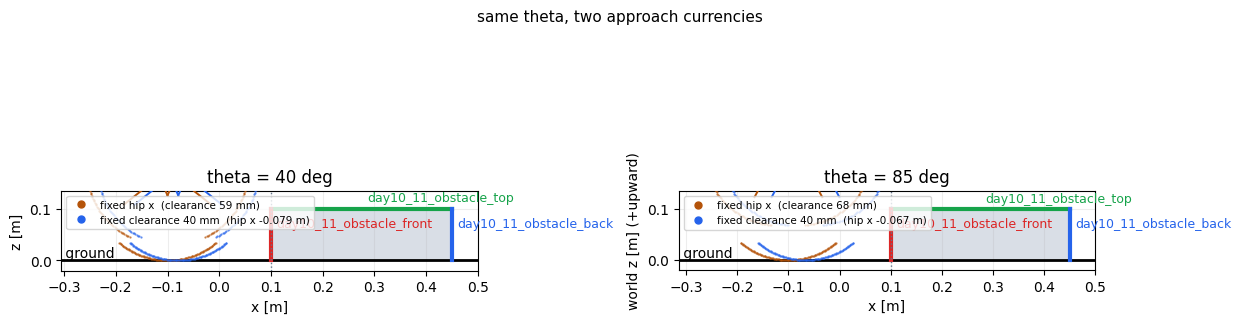

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for ax, theta_deg in zip(axes, (40.0, 85.0)):
    theta = np.deg2rad(theta_deg)
    hip_x_c = approach_hip_x_for_clearance_2d(spec, theta, fixed_clearance)
    scene_c = standing_scene_2d(spec, theta, hip_x_m=hip_x_c)
    scene_x = standing_scene_2d(spec, theta, hip_x_m=fixed_hip_x)
    xs = np.concatenate([scene_c.geometry.points_world_xz_m[:, 0],
                         scene_x.geometry.points_world_xz_m[:, 0]])
    plot_terrain_profile_2d(scene_c.terrain, ax=ax,
                            x_limits_m=(xs.min() - 0.05, spec.x_max_m + 0.05))
    for scene, color, label in (
        (scene_x, '#b45309',
         f'fixed hip x  (clearance {_front_face_clearance_m(scene_x)*1e3:.0f} mm)'),
        (scene_c, '#2563eb', f'fixed clearance 40 mm  (hip x {hip_x_c:.3f} m)'),
    ):
        for segment in scene.geometry.link_segments_world_xz_m:
            ax.plot(segment[:, 0], segment[:, 1], color=color, lw=1.4, zorder=4)
        pts = scene.geometry.points_world_xz_m
        ax.plot(pts[:, 0], pts[:, 1], '.', ms=1.2, color=color, alpha=0.7, zorder=3)
        hip = scene.hip_pose.position_world_xz_m
        ax.plot(hip[0], hip[1], 'o', ms=5, color=color, label=label, zorder=6)
    ax.axvline(spec.x_start_m, color='#64748b', ls=':', lw=1.0)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.22)
    ax.legend(fontsize=7.5, loc='upper left')
    ax.set_title(f'theta = {theta_deg:.0f} deg')
    ax.set_xlabel('x [m]')
axes[0].set_ylabel('z [m]')
fig.suptitle('same theta, two approach currencies', fontsize=11)
plt.tight_layout()
display(fig)
plt.close(fig)

### 讀圖

左圖（`theta = 40°`，腿伸展）兩種幣別差得少；右圖（`theta = 85°`，腿收縮）差很多。
差距本身就是「腿的等效半徑隨 `theta` 變」的直接後果——這就是為什麼固定 hip x 的
`theta` 掃描不是一個受控實驗。

## 0.4 對齊之後：同一個 cell，兩邊建出同一個站姿

```text
rolling 路徑   SweepSettings2D 的 bisection template（hip_z = 地面 - 最低取樣點）
swing   路徑   build_leg_on_surface_scene_2d（解 hip_z 讓最低取樣點落在支撐面上）
```

唯一該有的差別是 `build_leg_on_surface_scene_2d` 刻意加的 `surface_offset_m = 1 nm`——
那個抬升是為了不讓「剛好落在面上」的取樣點由 1e-17 的捨入誤差決定算接觸還是穿透。

In [5]:
demo = check_standing_alignment_2d(spec, np.deg2rad(60.0), 0.04)
display(pd.DataFrame([demo.as_dict()]).T.rename(columns={0: 'h=100 mm, theta=60 deg, c=40 mm'}))

,"h=100 mm, theta=60 deg, c=40 mm"
height_mm,100.0
top_length_m,0.35
theta_deg,60.0
clearance_mm,40.0
hip_x_m,-0.075365
rolling_hip_z_m,0.219449
swing_hip_z_m,0.219449
hip_z_difference_nm,1.0
explained_by_surface_offset,True
measured_clearance_mm,40.000001


In [6]:
alignment = pd.read_csv(day10_11_dir / 'day10_11_step0_scene_alignment.csv')
summary = pd.DataFrame([{
    'cells': len(alignment),
    'agree to the 1 nm offset': int(alignment.explained_by_surface_offset.sum()),
    'max |hip_z diff| [nm]': alignment.hip_z_difference_nm.abs().max(),
    'max clearance error [nm]': (
        (alignment.measured_clearance_mm - alignment.clearance_mm).abs().max() * 1e6),
    'distinct contact rims': ', '.join(sorted(alignment.contact_rim.dropna().unique())),
    'max rim geometry gap [mm]': alignment.rim_geometry_gap_mm.max(),
}]).T.rename(columns={0: 'Step 0 standing alignment'})
display(summary)

,Step 0 standing alignment
cells,80
agree to the 1 nm offset,80
max |hip_z diff| [nm],1.0
max clearance error [nm],0.797875
distinct contact rims,foot_rim
max rim geometry gap [mm],0.0


### 讀表

**`hip_z` 的差恰好是 1 nm，一格不多。** 兩條路徑不是「接近」，是**同一個定義**，
差別只有那個刻意的抬升。實現的餘裕誤差是奈米級，代表 bisection 收斂到底，`c` 這個軸可信。

**站姿的接觸永遠落在 foot rim、`alpha = 0`**，所以 `rim_geometry_gap` 是 0——
foot rim 在兩套幾何裡都是 0.145 m，1.2 mm 的差只存在於兩個 upper tyre。
這一格會在 §0.5 變成非零，而那才是它真正會咬人的地方。

## 0.5 一般化的 roll-exit → swing-start 交接

Day 8–9 有一個 `day6_7_roll_end_swing_start_2d(path)`，但它**讀的是一個 cache 檔**，
只涵蓋一組 `(h = 0.10, theta = 60°, width = 0.6)`。

Day 10–11 需要任意 `(h, L_top, theta)`、任意 stage 邊界的版本，因為策略空間是 2×2：
下降可以從 rolling 的出口開始，也可以從 swing 的落點開始，兩者必須用同一種方式建出來才能比較。

`roll_exit_swing_start_2d` 跑一次完整 traversal，再從指定 stage 的最後一個 accepted frame
重建 swing 起始狀態。接觸是**重新做一次 terrain query 得到的**，不是相信 frame 存下來的點。
差別在於這一版**不會因為分歧而丟例外**——Day 10–11 需要那個分歧當量測值。

In [7]:
handoff = pd.read_csv(day10_11_dir / 'day10_11_step0_roll_exit_handoff.csv')
reached = handoff[handoff.reached_stage]
traversals = handoff[['height_mm', 'theta_climb_deg']].drop_duplicates().shape[0]

handoff_summary = pd.DataFrame([{
    'traversals run': traversals,
    'stage exits attempted': len(handoff),
    'stage exits reached': len(reached),
    'rim label matches rebuilt rim': f'{int(reached.rim_matches_frame.sum())} / {len(reached)}',
    'max contact drift [mm]': reached.contact_drift_mm.max(),
    'max |alpha difference| [deg]': reached.alpha_difference_deg.abs().max(),
    'rim geometry gap [mm], distinct': ', '.join(
        f'{v:.4f}' for v in sorted(reached.rim_geometry_gap_mm.round(4).unique())),
    'traversal runtime [s], median': handoff.groupby(
        ['height_mm', 'theta_climb_deg']).seconds.first().median(),
}]).T.rename(columns={0: 'Step 0 roll-exit handoff'})
display(handoff_summary)

print('\nrim geometry gap，依重建出來的 rim 分組：')
display(reached.groupby('rebuilt_rim').rim_geometry_gap_mm.agg(['count', 'min', 'max']).round(4))

,Step 0 roll-exit handoff
traversals run,20
stage exits attempted,60
stage exits reached,52
rim label matches rebuilt rim,52 / 52
max contact drift [mm],0.0
max |alpha difference| [deg],0.0
"rim geometry gap [mm], distinct","0.0000, 1.2000"
"traversal runtime [s], median",264.345



rim geometry gap，依重建出來的 rim 分組：


,count,min,max
rebuilt_rim,,,
foot_rim,1,0.0,0.0
left_rim,23,1.2,1.2
right_rim,28,1.2,1.2


### 讀表：交接本身是精確的，不精確的是別的東西

兩件事要分開講，混在一起會得到錯的結論。

**(a) 在接觸管線自己的幾何裡，交接是精確的。** `contact_drift` 與 `alpha_difference` 都是 0，
rim 標籤 52/52 對得起來。「rolling 停在哪、swing 從哪開始」這件事沒有誤差。

**(b) 對物理腿模型的偏差是 1.2 mm，而且幾乎每個交接點都非零。**
roll-up 的出口在 `right_rim`、wheel transition 的出口在 `left_rim`——**都是 upper tyre**，
正好是 `LegModel.rim_point`（0.145 m）與接觸管線繪圖弧（0.1438 m）差 1.2 mm 的地方。
唯一為 0 的那一格是 `foot_rim`（一條走完、落回地面的 roll-down），而 foot rim 在兩套幾何裡
半徑相同。§0.4 的站姿全部落在 foot rim，所以那裡是 0；交接點才是它現形的地方。

**這修正了規格 §4.3(b) 原本的說法。** 1.2 mm **不會**污染 roll→swing 的交接（那是自洽的），
它污染的是**往物理模型的映射**。所以它不是 Day 10–11 的阻礙，而是 Day 12 產生真實
joint command 時必須處理的事——那時才會有人同時使用兩套幾何。

## 0.6 一個沒有規劃、但比對齊檢查更有力的證據

Step 0 的交接量測必須跑完整 traversal，所以它順帶對每個 cell 產生了一個可行性判定。
那些判定可以直接拿去跟 Day 6–7 已經跑完的 map 對照——**如果幣別真的對齊了，兩者必須逐格相同。**

In [8]:
day6_7_sweep = pd.read_csv(day6_7_dir / 'day6_7_step11r_feasibility_sweep.csv')
day6_7_sweep['theta_r'] = day6_7_sweep.theta_climb_deg.round(0)
day6_7_sweep['height_mm'] = (day6_7_sweep.obstacle_height_m * 1e3).round(0)

step0_grid = (handoff.groupby(['height_mm', 'theta_climb_deg'])
              .feasible_traversal.first().reset_index())
step0_grid['theta_r'] = step0_grid.theta_climb_deg.round(0)

merged = step0_grid.merge(
    day6_7_sweep[['height_mm', 'theta_r', 'feasible']],
    on=['height_mm', 'theta_r'], how='left', suffixes=('_step0', '_day6_7'))
merged['day6_7'] = merged.feasible.map({True: True, False: False, 'True': True, 'False': False})
merged['agrees'] = merged.feasible_traversal == merged.day6_7

print(f'逐格一致：{int(merged.agrees.sum())} / {len(merged)}')
display(pd.crosstab(merged.height_mm, merged.theta_r,
                    values=merged.feasible_traversal, aggfunc='first'))

逐格一致：20 / 20


theta_r,40.0,50.0,60.0,70.0,85.0
height_mm,,,,,
60.0,True,True,True,True,True
100.0,True,True,True,True,True
120.0,False,False,False,False,False
140.0,True,False,False,True,False


### 讀表：20/20 逐格相同

這張表和 Day 6–7 `day6_7_step11r_feasibility_sweep.csv` 的對應格子完全一致，包含兩個
**非單調**的地方：

```text
h = 120 mm   在 40 / 50 / 60 / 70 / 85 deg 全部不可行
             （Day 6-7 的完整掃描顯示它只在 45 與 55 deg 可行，50 deg 是洞）
h = 140 mm   40 與 70 deg 可行，50 / 60 / 85 deg 不可行
```

**這比 §0.4 的 1 nm 對齊更有說服力。** 對齊檢查證明兩邊「建出同一個姿態」；
這張表證明兩邊「跑出同一個結論」，而且連地圖上的洞都對得起來。

h = 120 那一列同時是一個對 Step 5 的警告：rolling 的可行 theta 窗口是**梳狀的**，
不是區間。用 `max - min` 描述窗口寬度會把它報成 10°，實際上區間中間是空的。
§1.5 會處理這件事。

In [9]:
wheel = handoff[(handoff.stage == 'WHEEL_TRANSITION') & handoff.reached_stage]
display(pd.crosstab(wheel.rebuilt_rim, wheel.feasible_traversal,
                    rownames=['wheel-transition 出口 rim'], colnames=['traversal 可行']))

traversal 可行,False,True
wheel-transition 出口 rim,,
left_rim,0,12
right_rim,8,0


### 讀表：判別因子只有一個

`WHEEL_TRANSITION` 的出口停在哪個 rim 上，和整條 traversal 可不可行是**完全相關**的
（12/12 與 8/8）。這正是 Day 6–7 Step 8R 的設計：`LEFT_RIM_READY` 是抵達後緣時檢查的
前提條件，左 rim 沒接手就沒有下降可言。

對 Day 10–11 的意義：這一格就是策略 #3（`SWING_UP + ROLL_DOWN`）要繞過的東西。
如果 swing 可以直接落在已經滿足 `LEFT_RIM_READY` 的狀態，rim handover 這一整段
（以及它花掉的 `L_transition`）就不需要付。**Step 2b 要回答的就是這件事。**

## 0.7 Step 0 完成標準對照

In [10]:
criteria = pd.DataFrame([
    {'規格要求': '同一 (h, theta, c) 兩邊 hip pose 差 < 1e-9 m',
     '狀態': '完成',
     '證據': f"{int(alignment.explained_by_surface_offset.sum())}/{len(alignment)} cells，差恰為 1 nm 的 surface offset"},
    {'規格要求': 'approach 一律以前緣餘裕表示，重用既有 bisection 不複製',
     '狀態': '完成',
     '證據': 'approach_hip_x_for_clearance_2d 包裝 _hip_x_for_start_clearance；實現餘裕誤差 < 1 nm'},
    {'規格要求': '障礙幾何統一到 (x_start=0.10, width=L_top)',
     '狀態': '完成',
     '證據': 'SharedTerrainSpec2D 預設即 rolling sweep 的幾何與 arc_samples=121'},
    {'規格要求': 'roll-end -> swing-start 一般化到任意 (h, theta)',
     '狀態': '完成',
     '證據': f'{traversals} 組 (h, theta) x {handoff.stage.nunique()} 個 stage，{len(reached)} 個 stage 出口全部重建成功'},
    {'規格要求': '交接誤差被量化並寫進 CSV（不要求為零）',
     '狀態': '完成',
     '證據': 'contact_drift_mm / alpha_difference_deg / rim_geometry_gap_mm 三欄'},
    {'規格要求': '（額外）與 Day 6-7 已完成的 map 逐格一致',
     '狀態': '完成',
     '證據': f'{int(merged.agrees.sum())}/{len(merged)} 格相同，含兩處非單調'},
]).set_index('規格要求')
display(criteria)

,狀態,證據
規格要求,,
"同一 (h, theta, c) 兩邊 hip pose 差 < 1e-9 m",完成,80/80 cells，差恰為 1 nm 的 surface offset
approach 一律以前緣餘裕表示，重用既有 bisection 不複製,完成,approach_hip_x_for_clearance_2d 包裝 _hip_x_for_...
"障礙幾何統一到 (x_start=0.10, width=L_top)",完成,SharedTerrainSpec2D 預設即 rolling sweep 的幾何與 arc...
"roll-end -> swing-start 一般化到任意 (h, theta)",完成,"20 組 (h, theta) x 3 個 stage，52 個 stage 出口全部重建成功"
交接誤差被量化並寫進 CSV（不要求為零）,完成,contact_drift_mm / alpha_difference_deg / rim_...
（額外）與 Day 6-7 已完成的 map 逐格一致,完成,20/20 格相同，含兩處非單調


---

# Step 1 — Concession 契約

## 1.1 為什麼需要這一步

Day 8–9 把一條 swing 的代價報成散文：

```python
adjustments = ("hip raised 60 mm", "lift-off raised 30 mm")
```

那是 showcase 該做的事，但不是可以拿來排序的東西。Step 1 把它變成欄位。

契約要守住兩件事，兩件都不是形式主義：

**(a) 貪婪搜尋的結果不是最小值。** `swing_onto_step_2d` 沿 hip ladder 升階，直到一個便宜的
reach 探針通過就停止升階，接著 repair 修軌跡——而 repair 可以把 ladder 停下來的那個 reach
打壞，且**不會回頭**。所以每個 concession 都帶一個 `ConcessionSource`，說明數字是怎麼來的。

**(b) roll 與 swing 要的不是同一種東西。** swing 要的是「hip 在某一刻至少要多高」——一個不等式；
roll 沒有這個自由度，它的 hip 高度是 `theta_climb` 與接觸幾何的**輸出**，所以它要的是
「hip 全程跟著這條高度曲線」——一條軌跡。把兩者壓成一個純量再比大小，等於預設了
Step 4 要問的那個問題的答案。

In [11]:
concessions = pd.read_csv(day10_11_dir / 'day10_11_step1_swing_concessions.csv')
view = concessions[[
    'direction', 'height_mm', 'feasible', 'binding_ceiling',
    'min_hip_lift_mm', 'min_hip_hold_fraction', 'body_deviation_mm',
    'min_liftoff_rise_mm', 'min_clearance_mm', 'theta_min_deg',
    'failure', 'lossless',
]]
display(view.set_index(['direction', 'height_mm']))

feasible binding_ceiling  min_hip_lift_mm  min_hip_hold_fraction  body_deviation_mm  min_liftoff_rise_mm  min_clearance_mm  theta_min_deg                      failure  lossless
direction height_mm                                                                                                                                                                                  
onto      20             True            none              0.0                    NaN                0.0                  0.0          1.439795      37.915880                         NONE      True
          60             True            none              0.0                    NaN                0.0                  0.0          1.076729      27.907229                         NONE      True
          100            True            none              0.0                    NaN                0.0                  0.0          1.556712      17.824151                         NONE      True
          120            True            none             20.0                    NaN               20.0                  0.0          1.793822      19.193990                         NONE      True
          140            True            none             40.0                    NaN               40.0                  0.0          1.048133      20.593629                         NONE      True
          150           False             fit             40.0                    NaN               40.0                 20.0          1.751881      17.000000             IK_NOT_CONVERGED      True
          160            True            none             60.0                    NaN               60.0                 30.0          1.369107      19.914548                         NONE      True
          200           False             fit             80.0                    NaN               80.0                120.0        -13.079820      18.750949            TERRAIN_COLLISION      True
off       20             True            none              NaN                   0.00                0.0                  0.0          1.439799      37.915880                         NONE      True
          60             True            none              NaN                   0.00                0.0                  0.0          1.076723      27.907234                         NONE      True
          100            True            none              NaN                   0.00                0.0                  0.0          1.556694      17.824121                         NONE      True
          120            True            none              NaN                   0.25               30.0                  0.0          1.831479      21.639381                         NONE      True
          140            True            none              NaN                   0.25               35.0                  0.0          1.674478      18.100939                         NONE      True
          150            True            none              NaN                   0.50               75.0                  0.0          2.143401      26.467812                         NONE      True
          160            True            none              NaN                   0.50               80.0                  0.0          1.053517      25.219041                         NONE      True
          200           False             fit              NaN                   0.50              100.0                  0.0          1.023892      19.392822  TOUCHDOWN_VELOCITY_TOO_HIGH      True

### 讀表：climb 與 descent 第一次並排

上升側重現了 Day 8–9 §28.1，下降側是**新資料**（§28.1 只做了 climb）：

```text
onto   20 /  60 / 100 mm   免費
onto  120 / 140 / 160 mm   hip +20 / +40 / +60 mm
onto  150 mm               失敗   <- 見 §1.3
onto  200 mm               失敗

off    20 /  60 / 100 mm   免費
off   120 / 140 mm         hold 0.25（30 / 35 mm）
off   150 / 160 mm         hold 0.50（75 / 80 mm）
off   200 mm               失敗
```

`off 160 mm` 要 hold 0.5，正好對上 `swing_off_step_2d` docstring 記的那句量測：
「at 160 mm a hip that drops with the foot runs theta out and collides, while one that
keeps half the drop clears with about 1.8 mm to spare」——獨立重現。

下降側**單調且沒有洞**；上升側有一個。

## 1.2 無損：用重建而不是解析來證明

「無損」的檢查方式很重要。寫一個 parser 只能證明字串**讀得出來**；
從欄位**重建**字串才能證明欄位本身就足夠產生它們——也就是沒有資訊只活在散文裡。

In [12]:
lossless = int(concessions.lossless.sum())
print(f'lossless: {lossless} / {len(concessions)}')
display(concessions[['direction', 'height_mm', 'showcase_adjustments',
                     'rebuilt_adjustments', 'lossless']]
        .set_index(['direction', 'height_mm']))

lossless: 16 / 16


showcase_adjustments                                rebuilt_adjustments  lossless
direction height_mm                                                                                                                
onto      20                                                      none                                               none      True
          60                                                      none                                               none      True
          100                                                     none                                               none      True
          120                                         hip raised 20 mm                                   hip raised 20 mm      True
          140                                         hip raised 40 mm                                   hip raised 40 mm      True
          150                  hip raised 40 mm; lift-off raised 20 mm            hip raised 40 mm; lift-off raised 20 mm      True
          160                  hip raised 60 mm; lift-off raised 30 mm            hip raised 60 mm; lift-off raised 30 mm      True
          200                 hip raised 80 mm; lift-off raised 120 mm           hip raised 80 mm; lift-off raised 120 mm      True
off       20                                                      none                                               none      True
          60                                                      none                                               none      True
          100                                                     none                                               none      True
          120                 hip held above the landing pose by 30 mm           hip held above the landing pose by 30 mm      True
          140                 hip held above the landing pose by 35 mm           hip held above the landing pose by 35 mm      True
          150        hip held above the landing pose by 75 mm; touc...  hip held above the landing pose by 75 mm; touc...      True
          160        hip held above the landing pose by 80 mm; touc...  hip held above the landing pose by 80 mm; touc...      True
          200        hip held above the landing pose by 100 mm; tou...  hip held above the landing pose by 100 mm; tou...      True

## 1.3 150 mm：契約自己認得出貪婪搜尋的假洞

`swing_onto_step_2d` 在 140 mm 用 `hip +40` 通過、160 mm 用 `hip +60` 通過，
**150 mm 卻失敗**。高度不單調，這不可能是幾何造成的。

機制在 `_run_step_swing_showcase`：ceiling 1 沿 hip ladder 升階，用便宜的 `_reachable`
探針判定，一旦探針說「搆得到」就停止升階；ceiling 2 的 repair 為了閃過障礙把 liftoff 抬高，
反而把 reach 打壞——而流程不會回頭再升 hip。

契約把這個病理變成一個**可偵測的簽名**：抵達 fit 階段代表 reach 探針通過了，
而在那裡以 reach 類的原因失敗，就代表 repair 把 reach 弄壞了。

In [13]:
holes = concessions[concessions.greedy_backtrack_suspected]
display(concessions[['direction', 'height_mm', 'feasible', 'binding_ceiling',
                     'failure', 'greedy_backtrack_suspected', 'reason']]
        [~concessions.feasible].set_index(['direction', 'height_mm']))
print(f'\n被標記為貪婪假洞的 cell：{len(holes)}')
for _, row in holes.iterrows():
    print(f"  {row.direction} {row.height_mm:.0f} mm  "
          f"ceiling={row.binding_ceiling} failure={row.failure}")

feasible binding_ceiling                      failure  greedy_backtrack_suspected                                             reason
direction height_mm                                                                                                                                      
onto      150           False             fit             IK_NOT_CONVERGED                        True  IK stopped at residual 0.082 mm after 5 iterat...
          200           False             fit            TERRAIN_COLLISION                       False  still colliding at the largest endpoint offset...
off       200           False             fit  TOUCHDOWN_VELOCITY_TOO_HIGH                       False  would need 8.00 s, beyond the 4.00 s allowed f...


被標記為貪婪假洞的 cell：1
  onto 150 mm  ceiling=fit failure=IK_NOT_CONVERGED


### 讀表：三個失敗，兩種

兩個 200 mm 的失敗都是真的，而且原因不同：`onto` 是 `TERRAIN_COLLISION`（塞不下），
`off` 是 `TOUCHDOWN_VELOCITY_TOO_HIGH`（落地太快）。兩者都是幾何/動力學造成的，不是搜尋造成的。

`onto 150 mm` 的失敗原因是 reach 類的，卻發生在 fit 階段——這就是簽名。
`BindingCeiling.FIT` 命名的是**到達了哪個階段**，不是原因；原因在 `failure` 欄。
兩者的組合才是診斷。

**對 Step 2 的意義**：sweep 不可以沿用這個貪婪 ladder，必須在
`(hip_lift × liftoff_rise)` 的完整格點上求最小可行組合。而 `GRID_MINIMUM` 在構造上
不可能產生這個簽名，所以 Step 2 可以直接把「沒有任何 cell 帶這個旗標」當成驗收條件。

## 1.4 型別拒絕做的事

`compare_concessions` 用 lexicographic，不調權重：

```text
feasible  >  body deviation  >  clearance margin
```

但它**拒絕**跨 kind 比較——把一個 hip 下界和一條 hip 軌跡按大小排序，等於預設了
規格 §5.3 那個開放問題的答案。Step 4 必須先量出哪一種比較苛刻，這個比較才有意義。

In [14]:
cheap_but_broken = SwingConcession2D(
    feasible=False, direction='onto', obstacle_height_m=0.20,
    source=ConcessionSource.GRID_MINIMUM, binding_ceiling=BindingCeiling.FIT,
    min_hip_lift_m=0.0, min_clearance_m=-0.013)
expensive_but_works = SwingConcession2D(
    feasible=True, direction='onto', obstacle_height_m=0.16,
    source=ConcessionSource.GRID_MINIMUM, binding_ceiling=BindingCeiling.NONE,
    min_hip_lift_m=0.06, min_clearance_m=0.0014)
print('可行勝過便宜：',
      compare_concessions(expensive_but_works, cheap_but_broken) == -1)

roll_side = roll_concession_from_cells([
    RollCellConcession2D(feasible=True, obstacle_height_m=0.16, top_length_m=0.35,
                         theta_climb_deg=60.0, approach_clearance_m=0.04,
                         hip_z_min_m=0.24, hip_z_max_m=0.30, hip_z_start_m=0.24)])
try:
    compare_concessions(expensive_but_works, roll_side)
except ValueError as error:
    print('\n跨 kind 比較被拒絕：')
    print(' ', error)

可行勝過便宜： True

跨 kind 比較被拒絕：
  refusing to rank body demands of different shapes (['lower_bound', 'track']); see spec §5.3 -- Step 4 has to measure which is harder first. Pass allow_cross_kind=True once that rule exists.


## 1.5 梳狀窗口：§0.6 逼出來的一個修正

§0.6 顯示 rolling 在 `h = 120 mm` 只在 45 與 55 deg 可行，**50 deg 是洞**。
所以 `feasible_theta_span_deg = max - min` 會把它報成 10°，聽起來像一個窗口，
實際上是一支梳子。而 Step 5 若用「窗口較寬」當 tie-break，就會偏好梳子——與 robust 相反。

契約因此同時報 `theta_window_is_contiguous` 與 `contiguous_span_around_best_deg`。

In [15]:
def _cell(theta_deg, feasible, hip_max):
    return RollCellConcession2D(
        feasible=feasible, obstacle_height_m=0.12, top_length_m=0.35,
        theta_climb_deg=theta_deg, approach_clearance_m=0.04,
        hip_z_min_m=0.24, hip_z_max_m=hip_max, hip_z_start_m=0.24)

comb = roll_concession_from_cells([          # Day 6-7 的 h = 120 mm 那一列
    _cell(40.0, False, 0.30), _cell(45.0, True, 0.28), _cell(50.0, False, 0.30),
    _cell(55.0, True, 0.29), _cell(60.0, False, 0.30)])
window = roll_concession_from_cells([        # 對照：真的連續
    _cell(40.0, False, 0.30), _cell(45.0, True, 0.29), _cell(50.0, True, 0.28),
    _cell(55.0, True, 0.295), _cell(60.0, False, 0.30)])

display(pd.DataFrame([
    {'case': 'comb (Day 6-7 h=120 mm)', **comb.as_dict()},
    {'case': 'genuine window', **window.as_dict()},
]).set_index('case')[[
    'feasible_cells', 'best_theta_climb_deg', 'feasible_theta_span_deg',
    'theta_window_is_contiguous', 'contiguous_span_around_best_deg',
    'feasible_theta_degs']])

,feasible_cells,best_theta_climb_deg,feasible_theta_span_deg,theta_window_is_contiguous,contiguous_span_around_best_deg,feasible_theta_degs
case,,,,,,
comb (Day 6-7 h=120 mm),2 / 5,45.0,10.0,False,0.0,"45, 55"
genuine window,3 / 5,50.0,10.0,True,10.0,"45, 50, 55"


### 讀表

兩列的 `feasible_theta_span_deg` 都是 10°，但 `contiguous_span_around_best_deg`
一個是 0°、一個是 10°。**後者才是機器人打不準 `theta_climb` 時還活得下來的那個數字。**

## 1.6 Step 1 完成標準對照

In [16]:
step1_criteria = pd.DataFrame([
    {'規格要求': '定義 SwingConcession2D 與 RollConcession2D',
     '狀態': '完成', '證據': 'day10_11_concession_2d.py'},
    {'規格要求': 'from_showcase 無損：adjustments 不能有資訊只存在字串裡',
     '狀態': '完成',
     '證據': f'{lossless}/{len(concessions)}，用重建而非解析證明'},
    {'規格要求': 'binding_ceiling 由 showcase 的失敗路徑推出',
     '狀態': '完成',
     '證據': 'STANCE / REACH / FIT 三分支，外加 Day 8-9 兩天花板故事沒涵蓋的 STANCE'},
    {'規格要求': '沒算過的欄位是 None，不是 0',
     '狀態': '完成', '證據': 'tests/test_day10_11_concession_2d.py'},
    {'規格要求': '（額外）貪婪搜尋結果與網格最小值在型別上可區分',
     '狀態': '完成',
     '證據': f'ConcessionSource + greedy_backtrack_suspected；標記到 {len(holes)} 個 cell'},
    {'規格要求': '（額外）梳狀 theta 窗口不會被報成寬窗口',
     '狀態': '完成', '證據': 'contiguous_span_around_best_deg'},
]).set_index('規格要求')
display(step1_criteria)

,狀態,證據
規格要求,,
定義 SwingConcession2D 與 RollConcession2D,完成,day10_11_concession_2d.py
from_showcase 無損：adjustments 不能有資訊只存在字串裡,完成,16/16，用重建而非解析證明
binding_ceiling 由 showcase 的失敗路徑推出,完成,STANCE / REACH / FIT 三分支，外加 Day 8-9 兩天花板故事沒涵蓋的...
沒算過的欄位是 None，不是 0,完成,tests/test_day10_11_concession_2d.py
（額外）貪婪搜尋結果與網格最小值在型別上可區分,完成,ConcessionSource + greedy_backtrack_suspected；...
（額外）梳狀 theta 窗口不會被報成寬窗口,完成,contiguous_span_around_best_deg


### 目前**沒有**被證明的事

```text
沒有任何新的 feasibility 結果        Step 0 只做對齊，Step 1 只做契約
swing 的 concession 仍然是貪婪值      全部 source = GREEDY_LADDER，不可跨 cell 比較
approach clearance 這一維尚未掃過     Step 2
SWING_UP 能否落在 LEFT_RIM_READY      Step 2b —— 2x2 裡唯一沒有數據的那一格
rolling 的 body 要求尚未量測          Step 4；「rolling 是零讓步」目前仍是直覺
1.2 mm 的 rim 幾何差仍然只是被記錄    沿用 Day 8-9 的決定
```

## 1.7 順帶量到、會影響後續規劃的兩件事

**(a) 一次完整 traversal 要幾分鐘。** Day 6–7 sweep 自己的 `runtime_s` 中位數 120 s、
最長 302 s；本次 Step 0 的 20 個 traversal 中位數約 264 s，15 workers 平行約 7.4 分鐘跑完。
Step 4 要重做 rolling 側時規模更大，必須先估總時間。

**(b) seam bridge 必須跟著取樣密度配對。** `seam_bridge_for_sampling_m(121)` 給的是
17.5 mm，不是預設的 5 mm。用預設值會偽否決 right→left 的 rim handover——而 §0.6 顯示
那個 handover 就是可行性的唯一判別因子。這不是效能旋鈕。

In [17]:
print('seam bridge vs arc_samples:')
for n in (61, 121, 241):
    print(f'  arc_samples={n:>4} -> {seam_bridge_for_sampling_m(n) * 1e3:6.2f} mm '
          f'(預設 5.00 mm)')

seam bridge vs arc_samples:
  arc_samples=  61 ->  34.73 mm (預設 5.00 mm)
  arc_samples= 121 ->  17.51 mm (預設 5.00 mm)
  arc_samples= 241 ->   8.79 mm (預設 5.00 mm)


---

# Step 2 — 上升側 swing sweep：`height × approach clearance`

## 2.1 這一步補的是哪一維

Day 8–9 §26.5(6) 的發現是：swing 的可行性主要不由落點高度決定，而由**腿從哪裡出發**決定——
同一組 case 從 0.10 m 出發撞三個，從 0.20 m 出發全過。機制是一個餘裕問題：
輪半徑 0.145 m 大於「接觸點到障礙的距離」時，接觸點還沒開始動，輪胎就已經在障礙裡了。

但 `swing_onto_step_2d` 把 `approach_distance_m` **固定住而且從不搜尋它**，失敗時只印出
`start_knob_name` 叫呼叫端自己去改。Step 2 把它變成一根軸。

## 2.2 為什麼這不是 Day 8–9 的那個搜尋

這是 Step 2 最重要的一件事，寫錯就會得到一張假地圖。

```text
Day 8-9 的貪婪 ladder
    沿 hip ladder 升階，用【便宜的 _reachable 探針】判定是否停止升階
    停下來之後 repair 為了閃避障礙抬高 liftoff
    -> repair 可以把 ladder 停下來的那個 reach 打壞，而流程不回頭
    -> 140 mm 過、160 mm 過、150 mm 不過

Step 2 的完整格點
    在 (hip_lift x liftoff_rise) 上同時升階，判準是【plan.valid 本身】
    升序走、第一個【真的 valid】的組合就是 lexicographic 最小值
    -> 答案是地形的性質，不是搜尋順序的性質
```

所以 Step 2 的每一格都標 `ConcessionSource.GRID_MINIMUM`，`is_comparable` 為真，
而且在構造上不可能帶 `greedy_backtrack_suspected`。

兩個容易混淆、在程式裡全程分開的名字：

```text
approach_clearance_m   共用的 Day 10-11 軸：站姿的腿到前緣的餘裕（Step 0 定的幣別）
apex_clearance_m       swing 自己的頂點餘裕，也就是 Day 8-9 的 clearance_m
```

In [18]:
step2 = pd.read_csv(day10_11_dir / 'day10_11_step2_swing_onto_sweep.csv')
print(f'{len(step2)} cells，'
      f"{step2.evaluations.sum()} 次 generate_swing_2d，"
      f"總計 {step2.seconds.sum() / 60:.1f} 分鐘的 CPU 時間")

pivot_hip = step2.pivot_table(index='height_mm', columns='approach_clearance_mm',
                              values='min_hip_lift_mm', dropna=False)
print('\n最小 hip lift [mm]（NaN = 整個格點都不可行）:')
display(pivot_hip)

88 cells，872 次 generate_swing_2d，總計 156.7 分鐘的 CPU 時間

最小 hip lift [mm]（NaN = 整個格點都不可行）:


approach_clearance_mm,20.0,40.0,60.0,80.0,100.0,120.0,140.0,160.0
height_mm,,,,,,,,
20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
120.0,80.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0
140.0,100.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0
150.0,NaN,60.0,40.0,40.0,40.0,40.0,40.0,40.0
160.0,NaN,60.0,60.0,60.0,60.0,60.0,60.0,60.0


In [19]:
pivot_ceiling = step2.pivot_table(index='height_mm', columns='approach_clearance_mm',
                                  values='binding_ceiling', aggfunc='first')
print('哪一道天花板在管:')
display(pivot_ceiling)

哪一道天花板在管:


approach_clearance_mm,20.0,40.0,60.0,80.0,100.0,120.0,140.0,160.0
height_mm,,,,,,,,
20.0,none,none,none,none,none,none,none,none
40.0,none,none,none,none,none,none,none,none
60.0,none,none,none,none,none,none,none,none
80.0,none,none,none,none,none,none,none,none
100.0,none,none,none,none,none,none,none,none
120.0,none,none,none,none,none,none,none,none
140.0,none,none,none,none,none,none,none,none
150.0,fit,none,none,none,none,none,none,none
160.0,fit,none,none,none,none,none,none,none


## 2.3 Step 2 的三個驗收條件

規格 §7 Step 2 列的三件事，逐一用數據回答。

In [20]:
heights = sorted(step2.height_mm.unique())
clearances = sorted(step2.approach_clearance_mm.unique())
lookup = {(r.height_mm, r.approach_clearance_mm): r for r in step2.itertuples()}
WHEEL_RADIUS_MM = 145.0

print('=== 條件 1：加大 approach clearance 能不能救回失敗的 cell？ ===')
rescued = []
for h in heights:
    ok = [bool(lookup[(h, c)].feasible) for c in clearances]
    if any(ok) and not all(ok):
        first = clearances[ok.index(True)]
        failing = [c for c, good in zip(clearances, ok) if not good]
        rescued.append((h, failing, first))
        print(f'  h={h:>5.0f} mm: c={failing} mm 失敗，第一個成功的是 c={first:.0f} mm')
if not rescued:
    print('  沒有任何一列被 clearance 軸翻轉。')

=== 條件 1：加大 approach clearance 能不能救回失敗的 cell？ ===
  h=  150 mm: c=[np.float64(20.0)] mm 失敗，第一個成功的是 c=40 mm
  h=  160 mm: c=[np.float64(20.0)] mm 失敗，第一個成功的是 c=40 mm
  h=  180 mm: c=[np.float64(20.0)] mm 失敗，第一個成功的是 c=40 mm
  h=  200 mm: c=[np.float64(20.0), np.float64(40.0)] mm 失敗，第一個成功的是 c=60 mm


In [21]:
print('=== 條件 2：固定 clearance 之下，可行性對高度是否單調？ ===')
holes = []
for c in clearances:
    column = [bool(lookup[(h, c)].feasible) for h in heights]
    for i in range(1, len(column) - 1):
        if not column[i] and column[i + 1]:
            holes.append((heights[i], c))
print(f'  洞的數量：{len(holes)}  {holes if holes else "(無)"}')

ceilings = []
for c in clearances:
    column = [bool(lookup[(h, c)].feasible) for h in heights]
    tallest = max((h for h, ok in zip(heights, column) if ok), default=None)
    ceilings.append({'approach_clearance_mm': c, 'tallest feasible step [mm]': tallest})
display(pd.DataFrame(ceilings).set_index('approach_clearance_mm').T)

print('\n150 mm 那一列（Day 8-9 貪婪搜尋的假洞）：')
display(step2[step2.height_mm == 150][
    ['approach_clearance_mm', 'feasible', 'min_hip_lift_mm',
     'min_liftoff_rise_mm', 'binding_ceiling', 'evaluations']].set_index('approach_clearance_mm'))

=== 條件 2：固定 clearance 之下，可行性對高度是否單調？ ===
  洞的數量：0  (無)


approach_clearance_mm,20.0,40.0,60.0,80.0,100.0,120.0,140.0,160.0
tallest feasible step [mm],140.0,180.0,200.0,200.0,200.0,200.0,200.0,200.0



150 mm 那一列（Day 8-9 貪婪搜尋的假洞）：


,feasible,min_hip_lift_mm,min_liftoff_rise_mm,binding_ceiling,evaluations
approach_clearance_mm,,,,,
20.0,False,NaN,NaN,fit,35
40.0,True,60.0,20.0,none,18
60.0,True,40.0,0.0,none,11
80.0,True,40.0,0.0,none,11
100.0,True,40.0,0.0,none,11
120.0,True,40.0,0.0,none,11
140.0,True,40.0,0.0,none,11
160.0,True,40.0,0.0,none,11


In [22]:
print('=== 條件 3：200 mm 在所有 clearance 下的答案 ===')
display(step2[step2.height_mm == 200][
    ['approach_clearance_mm', 'feasible', 'binding_ceiling', 'failure',
     'min_clearance_mm', 'theta_min_deg', 'evaluations']].set_index('approach_clearance_mm'))

print('\n=== 契約：格點結果不可帶貪婪簽名 ===')
print(f"  greedy_backtrack_suspected: {int(step2.greedy_backtrack_suspected.sum())}  (必須是 0)")
print(f"  sources: {set(step2.source)}  (必須是 {{'grid_minimum'}})")

=== 條件 3：200 mm 在所有 clearance 下的答案 ===


,feasible,binding_ceiling,failure,min_clearance_mm,theta_min_deg,evaluations
approach_clearance_mm,,,,,,
20.0,False,fit,TERRAIN_COLLISION,-13.873318,25.896090,35
40.0,False,fit,TERRAIN_COLLISION,-5.635062,25.931964,35
60.0,True,none,NONE,1.757749,20.674322,30
80.0,True,none,NONE,2.573302,18.750982,21
100.0,True,none,NONE,2.523249,18.751001,21
120.0,True,none,NONE,2.469698,18.751024,21
140.0,True,none,NONE,2.416193,18.751050,21
160.0,True,none,NONE,2.362738,18.751080,21



=== 契約：格點結果不可帶貪婪簽名 ===
  greedy_backtrack_suspected: 0  (必須是 0)
  sources: {'grid_minimum'}  (必須是 {'grid_minimum'})


## 2.4 兩張地圖

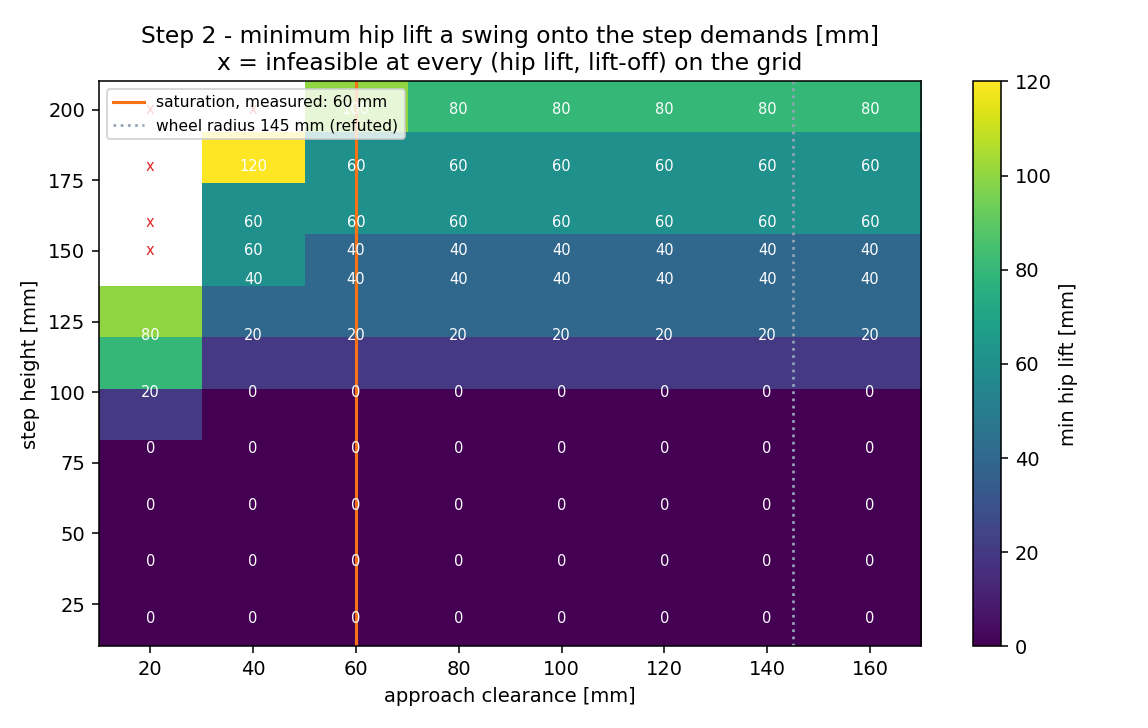

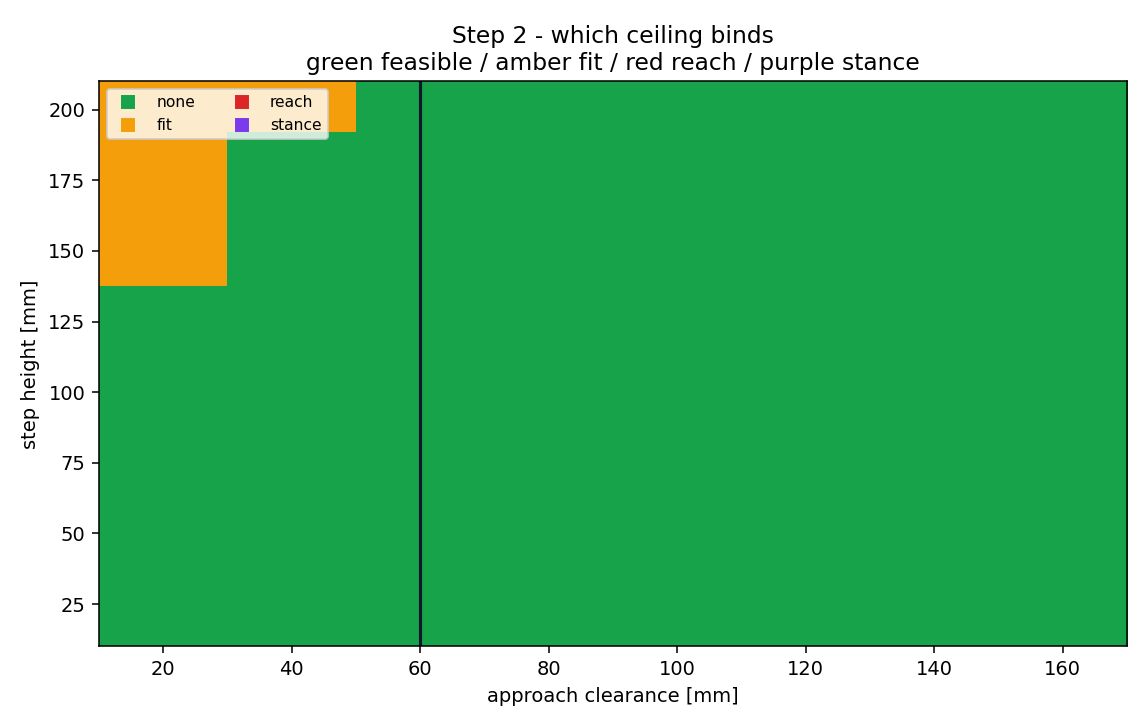

In [23]:
from IPython.display import Image, display as _display
_display(Image(filename=str(day10_11_dir / 'day10_11_step2_min_hip_lift_map.png')))
_display(Image(filename=str(day10_11_dir / 'day10_11_step2_binding_ceiling_map.png')))

### 讀圖：兩個結構

**(a) clearance 軸在 `c ≈ 60 mm` 飽和。** `c = 60 … 160 mm` 每一列的 min hip lift 完全相同——
超過 60 mm 之後，再多的接近空間買不到任何東西。這對 Step 5 有直接影響：
approach clearance **不是一個連續的代價軸，而是一個有門檻的二元條件**（夠不夠 60 mm）。
門檻之上，body 讓步就只由高度決定。

**(b) 高度天花板由 clearance 決定，不由 hip lift 決定。**

```text
c = 20 mm  -> 最高只能上 140 mm
c = 40 mm  -> 180 mm
c >= 60 mm -> 200 mm（掃描範圍上限，還沒碰到真正的天花板）
```

從 c=20 到 c=60，可上的最高台階從 140 mm 變成 200 mm（+43%），而這**完全不是**靠多給 hip lift——
c=20 的那一列在整個 hip ladder（最高 120 mm）跑完之後仍然失敗。

## 2.5 一個被數據推翻的預期：轉折點不在輪半徑

規格的 Step 2 完成標準寫著「轉折點附近 `c` 與輪半徑 0.145 m 的關係被明確寫出來」，
出處是 Day 8–9 §26.5(6) 提出的機制：

> 輪半徑 145 mm 比「接觸點到障礙物的距離」還大時，接觸點還沒動輪胎就進去了。

**這個機制在本次掃描的幾何下從未成立。**

In [24]:
from hybrid_note.scripts.experiments.cartesian_swing_contract_2d import (
    swing_start_state_from_scene_2d)

probe_spec = SharedTerrainSpec2D(height_m=0.15)
probe_theta = np.deg2rad(60.0)
probe_rows = []
for c in (0.02, 0.04, 0.06, 0.08, 0.10, 0.16):
    hx = approach_hip_x_for_clearance_2d(probe_spec, probe_theta, c)
    sc = standing_scene_2d(probe_spec, probe_theta, hip_x_m=hx)
    st = swing_start_state_from_scene_2d(sc)
    probe_rows.append({
        'approach_clearance_mm': c * 1e3,
        'face clearance [mm]': _front_face_clearance_m(sc) * 1e3,
        'contact -> face [mm]': (probe_spec.x_start_m
                                 - float(st.contact_point_world_xz_m[0])) * 1e3,
        'below wheel radius 145 mm?': (probe_spec.x_start_m
                                       - float(st.contact_point_world_xz_m[0])) < 0.145,
    })
display(pd.DataFrame(probe_rows).set_index('approach_clearance_mm').round(1))

,face clearance [mm],contact -> face [mm],below wheel radius 145 mm?
approach_clearance_mm,,,
20.0,20.0,175.9,False
40.0,40.0,196.6,False
60.0,60.0,217.2,False
80.0,80.0,237.7,False
100.0,100.0,258.1,False
160.0,160.0,318.9,False


### 讀表：機制不對，但效應是真的

在 `h = 150 mm` 上，接觸點到前緣的距離從 176 mm（`c = 20 mm`）到 319 mm（`c = 160 mm`），
**整條軸上都沒有低於 145 mm**——然而 `c = 20 mm` 那一格確實失敗了。
所以失敗的原因不是 §26.5(6) 描述的那個靜態接觸點幾何。

**真正的機制由「哪個旋鈕修得好它」指出來。**

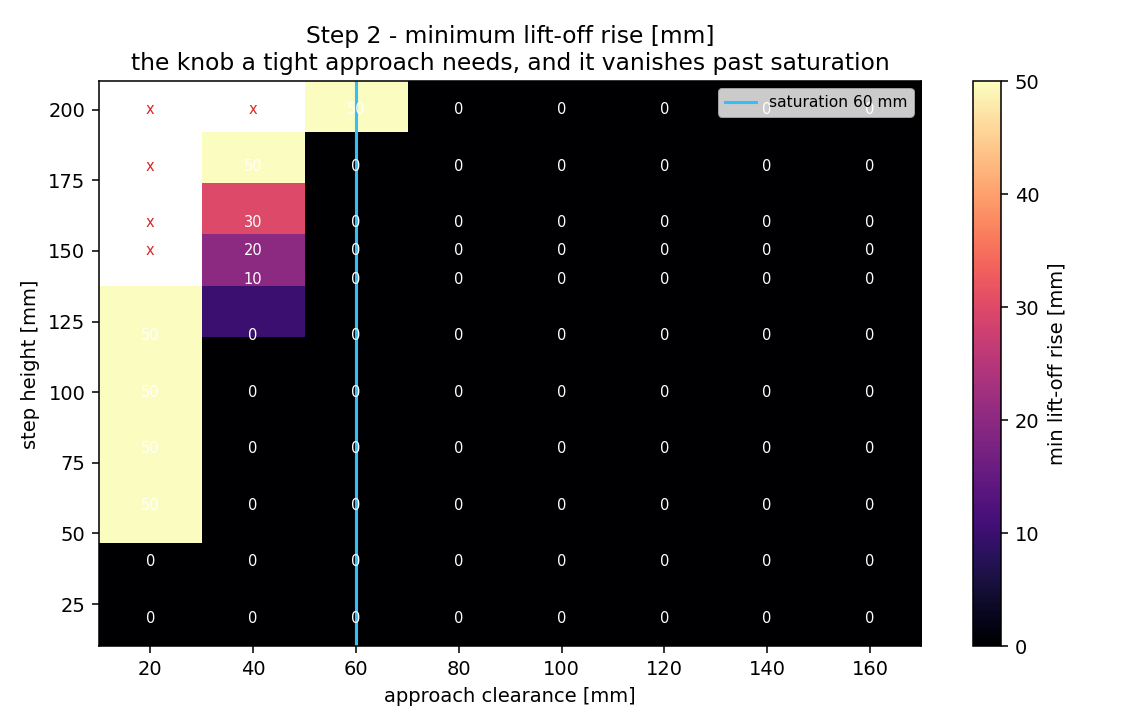

min lift-off rise [mm]：


approach_clearance_mm,20.0,40.0,60.0,80.0,100.0,120.0,140.0,160.0
height_mm,,,,,,,,
20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
120.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
140.0,50.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0
150.0,NaN,20.0,0.0,0.0,0.0,0.0,0.0,0.0
160.0,NaN,30.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step2_min_liftoff_map.png')))

print('min lift-off rise [mm]：')
display(step2.pivot_table(index='height_mm', columns='approach_clearance_mm',
                          values='min_liftoff_rise_mm', dropna=False))

### 讀圖：修好小 clearance 的是 `liftoff_rise`

```text
c = 20 mm   h >= 60 mm 每一格都需要 50 mm 的 lift-off rise（ladder 的頂端）
c = 40 mm   隨高度爬升 0 -> 10 -> 20 -> 30 -> 50 mm
c >= 60 mm  全部 0 mm
```

`liftoff_rise` 是在 swing **起始**把腿垂直抬起來的旋鈕。它是修好緊迫接近的那一個，
就說明問題是**腿體在還貼著前緣時的掃掠體積**，不是接觸點的靜態位置。

換句話說：§26.5(6) 的**效應**（approach 是主變數）完全成立並被量化了，
但它提出的**機制**（輪半徑 vs 接觸點距離）在這個幾何下不是操作中的原因。
兩者要分開講，否則 paper 會寫出一個數據不支持的因果。

## 2.6 Step 2 完成標準對照

In [26]:
step2_criteria = pd.DataFrame([
    {'規格要求': '重現 §26.5(6)：小 c 不可行 / 大 c 可行',
     '狀態': '成立',
     '證據': 'h=150/160/180 在 c=20 失敗、c=40 成功；h=200 在 c=20/40 失敗、c=60 成功'},
    {'規格要求': '轉折點附近 c 與輪半徑 0.145 m 的關係',
     '狀態': '推翻',
     '證據': 'h=150 的 contact->face 為 176-319 mm，整條軸都 > 145 mm；機制改為 lift-off 掃掠體積'},
    {'規格要求': '150 mm 不再是洞',
     '狀態': '成立',
     '證據': f'固定 c 之下對高度完全單調，0 個洞'},
    {'規格要求': '200 mm 在所有 c 下有明確答案',
     '狀態': '成立',
     '證據': 'c>=60 mm 可行；c=20/40 mm 為 TERRAIN_COLLISION'},
    {'規格要求': '每個 cell 的 binding_ceiling 有值',
     '狀態': '成立',
     '證據': f'{len(step2)}/{len(step2)} cells'},
    {'規格要求': '（契約）格點結果不可帶貪婪簽名',
     '狀態': '成立',
     '證據': f'{int(step2.greedy_backtrack_suspected.sum())} 個；全部 source=grid_minimum'},
]).set_index('規格要求')
display(step2_criteria)

,狀態,證據
規格要求,,
重現 §26.5(6)：小 c 不可行 / 大 c 可行,成立,h=150/160/180 在 c=20 失敗、c=40 成功；h=200 在 c=20/4...
轉折點附近 c 與輪半徑 0.145 m 的關係,推翻,h=150 的 contact->face 為 176-319 mm，整條軸都 > 145 ...
150 mm 不再是洞,成立,固定 c 之下對高度完全單調，0 個洞
200 mm 在所有 c 下有明確答案,成立,c>=60 mm 可行；c=20/40 mm 為 TERRAIN_COLLISION
每個 cell 的 binding_ceiling 有值,成立,88/88 cells
（契約）格點結果不可帶貪婪簽名,成立,0 個；全部 source=grid_minimum


### 目前**沒有**被證明的事

```text
下降側完全沒有掃過                    Step 3
SWING_UP 能否落在 LEFT_RIM_READY      Step 2b —— 2x2 裡唯一沒有數據的那一格
rolling 的 body 要求尚未量測          Step 4
landing_distance 固定在 0.16 m        Step 2 只掃 approach 這一維
theta 固定在 60 deg                   選項 (i) 的前提
200 mm 以上沒有掃                     c >= 60 mm 那幾列還沒碰到真正的天花板
```

## 2.7 Close-out：主 sweep 固定住、但沒有論證過的三件事

Step 2 的地圖回答了「一個 swing 上台階要付多少」，但它同時**固定**了三個東西而沒有說明
為什麼可以固定。每一個都會讓那張地圖變成**有條件的**，而 Step 5 疊圖時會默默繼承那個條件：

```text
ceiling    c >= 60 mm 的每一列到 200 mm 都可行 —— 但 200 mm 是掃描邊界，不是天花板
landing    landing_distance = 0.16 m 是上升的真自由度，卻只在一個值上報過價
theta      theta = 60 deg。「固定」和「無所謂」是兩件事，只有前者被說過
```

`day10_11_step2_closeout_driver.py`：48 cells、961 次 `generate_swing_2d`、987 s。
三段都把 clearance 設在飽和之後的 80 mm，所以**變動的只有被測的那一項**。

In [27]:
closeout = pd.read_csv(day10_11_dir / 'day10_11_step2_closeout.csv')
print('sections:', dict(closeout.section.value_counts()))
print('總 generate_swing_2d 次數:', int(closeout.evaluations.sum()))
print('帶貪婪簽名的 cell:', int(closeout.greedy_backtrack_suspected.sum()), '(必須是 0)')

ceiling = closeout[closeout.section == 'ceiling']
tallest = (ceiling[ceiling.feasible]
           .groupby('approach_clearance_mm').height_mm.max()
           .rename('最高可行高度 [mm]').to_frame())
tallest['失敗處的 binding_ceiling'] = [
    ', '.join(sorted(ceiling[(ceiling.approach_clearance_mm == c) & ~ceiling.feasible]
                     .binding_ceiling.unique()))
    for c in tallest.index
]
display(tallest)

sections: {'ceiling': np.int64(18), 'landing': np.int64(15), 'theta': np.int64(15)}
總 generate_swing_2d 次數: 961
帶貪婪簽名的 cell: 0 (必須是 0)


,最高可行高度 [mm],失敗處的 binding_ceiling
approach_clearance_mm,,
60.0,200.0,"fit, reach"
100.0,240.0,reach
160.0,240.0,reach


### 讀表：天花板是 240 mm，而且 clearance 的飽和點會隨高度上移

```text
c =  60 mm   最高 200 mm       220 mm 起就失敗
c = 100 mm   最高 240 mm
c = 160 mm   最高 240 mm       和 100 mm 一樣 -> 飽和點在 100 mm，不是 60 mm
260 / 280 / 300 mm 三個 clearance 全部失敗，binding_ceiling = reach
```

**兩個結論，其中一個修正了 §2.6 的講法：**

1. **天花板 240 mm，而且是 `reach` 型的**——腿**搆不到**，不是**放不下**。
   這是幾何硬上限，再多 clearance 也沒用。

2. **「c ≈ 60 mm 飽和」只在 `h <= 200 mm` 成立。** `h = 220 / 240 mm` 時
   `c = 60` 失敗、`c = 100` 成功，門檻升到 100 mm。
   Step 5 的門檻條件必須寫成 `c_threshold(h)`，**不能寫成常數 60 mm**。

In [28]:
landing = closeout[closeout.section == 'landing']
tbl = landing.pivot_table(index='height_mm', columns='landing_distance_m',
                          values='min_hip_lift_mm', dropna=False)
tbl = tbl.where(landing.pivot_table(index='height_mm', columns='landing_distance_m',
                                    values='feasible', aggfunc='first', dropna=False).astype(bool))
print('min hip lift [mm]（NaN = 不可行），c = 80 mm')
display(tbl)

theta_tbl = closeout[closeout.section == 'theta'].pivot_table(
    index='height_mm', columns='theta_deg', values='min_hip_lift_mm', dropna=False)
theta_feasible = closeout[closeout.section == 'theta'].pivot_table(
    index='height_mm', columns='theta_deg', values='feasible', aggfunc='first', dropna=False)
print('\nmin hip lift [mm]，c = 80 mm、landing = 0.16 m')
display(theta_tbl.where(theta_feasible.astype(bool)))

min hip lift [mm]（NaN = 不可行），c = 80 mm


landing_distance_m,0.10,0.13,0.16,0.19,0.22
height_mm,,,,,
100.0,0.0,0.0,0.0,0.0,0.0
150.0,40.0,40.0,40.0,40.0,40.0
200.0,80.0,80.0,80.0,100.0,NaN



min hip lift [mm]，c = 80 mm、landing = 0.16 m


theta_deg,40.0,50.0,60.0,70.0,85.0
height_mm,,,,,
100.0,80.0,40.0,0.0,0.0,0.0
150.0,120.0,80.0,40.0,20.0,0.0
200.0,NaN,120.0,80.0,40.0,0.0


### 讀表：landing 在天花板以下無所謂，在天花板附近才咬

固定 `landing = 0.16 m` 是**可以的**，但理由不是「landing 無所謂」，而是
**「landing 在天花板以下無所謂」**。`h = 200 mm` 已經接近 240 mm 的天花板，
那裡 `0.19 m` 就要多付 20 mm、`0.22 m` 直接失敗。

In [29]:
# theta 的 min_hip_lift 是相對於「該 theta 的標稱站姿」量的，直接比會誤導。
# 換成 Step 5 真正要的絕對幣別：落地瞬間 hip 在台面上方多高。
spec_ref = SharedTerrainSpec2D(height_m=0.10)
standing_above_top = {
    deg: float(standing_scene_2d(spec_ref, np.deg2rad(deg), hip_x_m=0.30,
                                 support_height_m=spec_ref.top_z_m
                                 ).hip_pose.position_world_xz_m[1]) - spec_ref.top_z_m
    for deg in (17.0, 40.0, 50.0, 60.0, 70.0, 85.0)
}
print('標稱站姿：hip 在支撐面上方 [mm]')
display(pd.Series({f'theta = {k:.0f} deg': v * 1e3
                   for k, v in standing_above_top.items()}).round(2).to_frame('mm'))

# sweep 的 theta 欄位是從 rad 轉回來的，會有 59.999... 這種值；用最近的標稱值對應。
def _nominal(theta_deg):
    return min(standing_above_top, key=lambda k: abs(k - float(theta_deg)))

absolute = theta_tbl.copy()
for theta_deg in absolute.columns:
    absolute[theta_deg] = standing_above_top[_nominal(theta_deg)] * 1e3 + absolute[theta_deg]
absolute = absolute.where(theta_feasible.astype(bool))
absolute['最佳 theta'] = absolute.idxmin(axis=1)
absolute['最小值 [mm]'] = absolute.drop(columns='最佳 theta').min(axis=1)
sixty = [c for c in theta_tbl.columns if abs(float(c) - 60.0) < 1e-6][0]
absolute['Step 2 在 60 deg 報的值'] = [
    standing_above_top[60.0] * 1e3 + theta_tbl.loc[h, sixty] for h in absolute.index]
absolute['高估了 [mm]'] = absolute['Step 2 在 60 deg 報的值'] - absolute['最小值 [mm]']
print('\n落地時 hip 距台面高度 [mm]')
display(absolute.round(1))

標稱站姿：hip 在支撐面上方 [mm]


,mm
theta = 17 deg,145.00
theta = 40 deg,183.63
theta = 50 deg,201.50
theta = 60 deg,219.45
theta = 70 deg,237.46
theta = 85 deg,264.89



落地時 hip 距台面高度 [mm]


theta_deg,40.0,50.0,60.0,70.0,85.0,最佳 theta,最小值 [mm],Step 2 在 60 deg 報的值,高估了 [mm]
height_mm,,,,,,,,,
100.0,263.6,241.5,219.4,237.5,264.9,60.0,219.4,219.4,0.0
150.0,303.6,281.5,259.4,257.5,264.9,70.0,257.5,259.4,2.0
200.0,NaN,321.5,299.4,277.5,264.9,85.0,264.9,299.4,34.6


### 讀表：theta 不是中性參數，而且 60° 只在矮台階是最佳

**最佳 theta 隨高度上移，而且是內部極小值（不是端點）**——`h = 100` 在 60°、
`h = 150` 在 70°、`h = 200` 在 85°。這對 Day 10–11 有兩個直接後果：

1. **主 sweep 的 map 是【上界】，不是 swing 的代價。**
   `h = 200 mm` 它報 299.4 mm，真正的最小是 264.9 mm——**高估了 34.6 mm**。

2. **這正是規格 §3.1 自己寫的規則**：「每個 primitive 對自己的內部自由度取最佳」。
   Step 2 沒有對 theta 取最佳，Step 5 疊圖之前必須補上。

**注意這不推翻 §3.1 否決 sweep (ii) 的理由。** `theta_climb` 與 `theta_liftoff` 仍然
不是同一個物理量，不該畫在同一根軸上。它們是各自 primitive 的**內部旋鈕**，
該被**取最佳掉**，不是被**當共用軸**。close-out 反而讓這個區分更站得住腳：
theta 對 swing 有這麼大的效應，正好說明把它和 rolling 的 theta 對齊會是多嚴重的誤導。

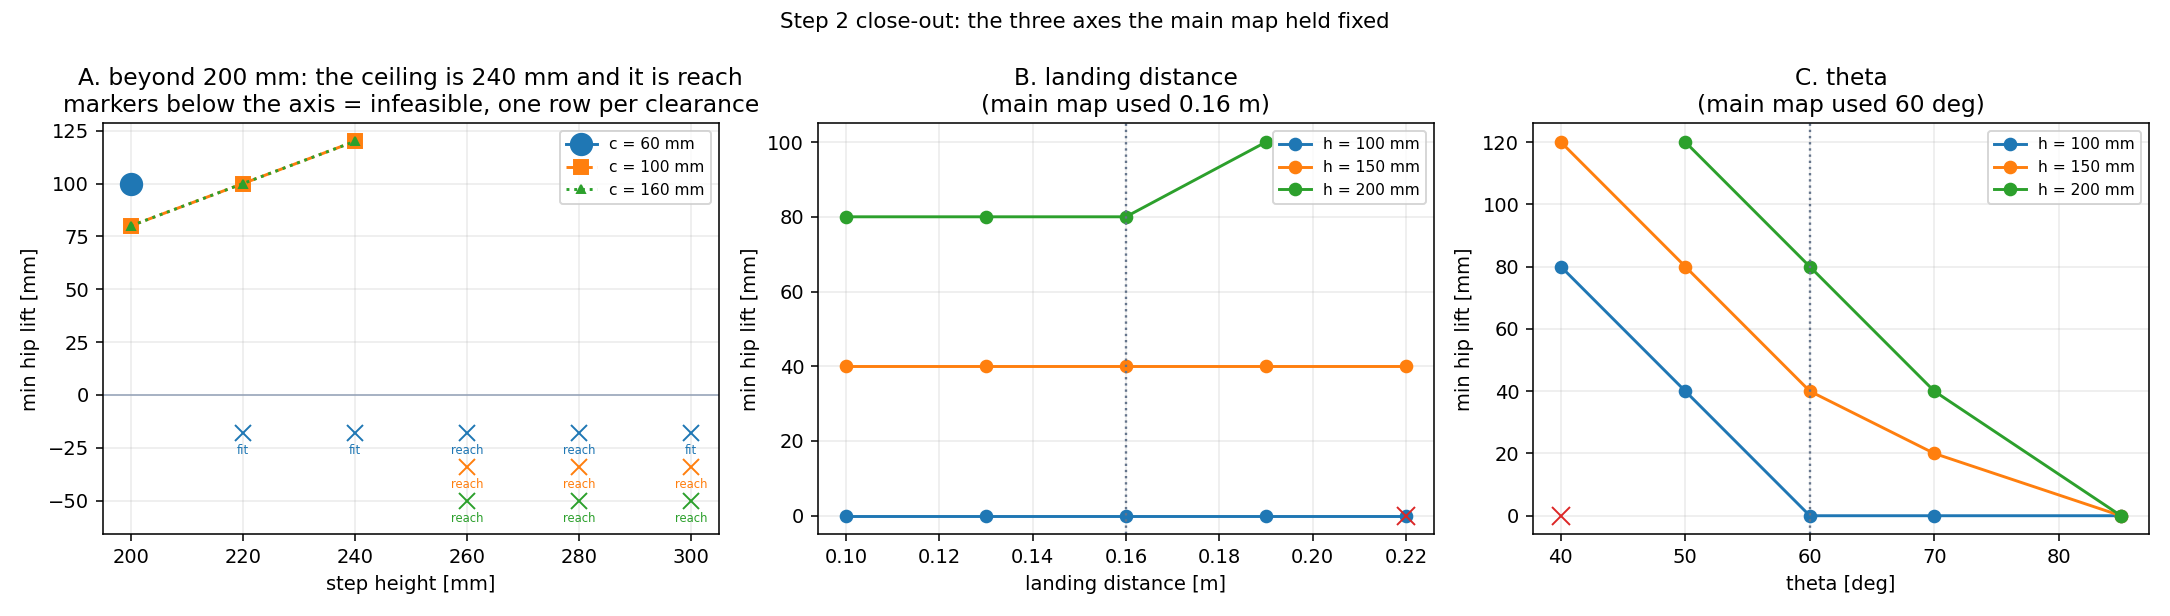

In [30]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step2_closeout.png')))

# Step 2b — SWING_UP 能不能落在 `LEFT_RIM_READY`

這是 2×2 裡**唯一完全沒有數據**的一格，也是策略 #3（`SWING_UP + ROLL_DOWN`）
存不存在的唯一關鍵。它的賣點是**完全不付 `L_transition`**——rolling 上去之後，
要從 right-rim 出口滾到 left-rim 交接，這段 0.20–0.27 m 就是 Day 6–7 Step 12R
那個最小 top length 的來源。swing 是 contact-state-to-contact-state 的，
原則上可以直接被**要求**落在下降所需的狀態，把那筆預算整個跳過。

Day 8–9 從來沒有這樣要求過它：每一個 showcase 都落在 `theta = 60 deg` 的 foot rim，
而 `theta = 17 deg` 的 left rim 是這隻腿**最收縮**的姿態。

規格 §2.8 把問題拆成三題。這裡用三種**不同性質**的量測分別回答，不是一個總結論：

```text
(b) rim 對嗎     一次靜態 beta 掃描 —— 便宜，而且要嘛有窗口要嘛沒有
(c) alpha 縫     同一次掃描，換成「離 rim 弧兩端各多遠」來報
(a) swing 可行嗎  每個 cell 一次完整 generate_swing_2d
```

## 2b.1 一個被數據逼出來的契約修改：`PINNED`

Step 2 的上升用 `min_hip_lift` 計價——「hip 至少要比標稱站姿高多少」，是一個**下界**。
**Step 2b 沒有這個旋鈕。**

把落地 contact state 釘死成 `(point, left rim, alpha)` 而且要求 `theta = 17 deg` 之後，
hip 就完全沒有自由度了：17 度的腿幾乎就是一個圓，hip 必須**剛好**在台面上方一個輪半徑處。
把 hip 抬高不會讓落地變容易，只會讓它變成**另一個**落地（theta 更大），而那個落地
過不了 `LEFT_RIM_READY`。

**需求的形狀是【等式】而不是【不等式】。**

In [31]:
from hybrid_note.scripts.experiments.day10_11_concession_2d import BodyRequirementKind
from hybrid_note.scripts.experiments.day10_11_left_rim_landing_2d import (
    LEFT_RIM_READY_THETA_RAD, left_rim_beta_window_2d, left_rim_landing_scene_2d,
    left_rim_ready_from_landing_2d, predicted_pivot_deg_2d, choose_landing_beta_2d,
)

pinned = SwingConcession2D(
    feasible=True, direction='onto', obstacle_height_m=0.10,
    source=ConcessionSource.GRID_MINIMUM, binding_ceiling=BindingCeiling.NONE,
    min_liftoff_rise_m=0.0, min_clearance_m=0.004,
    pinned_hip_above_surface_m=0.1438,
)
ordinary = SwingConcession2D(
    feasible=True, direction='onto', obstacle_height_m=0.10,
    source=ConcessionSource.GRID_MINIMUM, binding_ceiling=BindingCeiling.NONE,
    min_hip_lift_m=0.04, min_clearance_m=0.004,
)
print('Step 2b 的落地 :', pinned.requirement_kind.value)
print('Step 2  的落地 :', ordinary.requirement_kind.value)

try:
    SwingConcession2D(
        feasible=True, direction='onto', obstacle_height_m=0.10,
        source=ConcessionSource.GRID_MINIMUM, binding_ceiling=BindingCeiling.NONE,
        min_hip_lift_m=0.02, pinned_hip_above_surface_m=0.1438)
except ValueError as error:
    print('\n型別拒絕給 pinned landing 加 hip lift：')
    print(' ', error)

try:
    compare_concessions(pinned, ordinary)
except ValueError as error:
    print('\n型別拒絕跨形狀排序：')
    print(' ', error)

Step 2b 的落地 : pinned
Step 2  的落地 : lower_bound

型別拒絕給 pinned landing 加 hip lift：
  a pinned landing has no hip-lift freedom; a non-zero lift would land the leg at a different theta, which is a different contact state.

型別拒絕跨形狀排序：
  refusing to rank body demands of different shapes (['lower_bound', 'pinned']); see spec §5.3 -- Step 4 has to measure which is harder first. Pass allow_cross_kind=True once that rule exists.


### 讀輸出

`compare_concessions` 現在會擋兩件事，而不是一件：

```text
PINNED vs LOWER_BOUND   Step 2b 的等式需求 vs Step 2 的不等式需求
LOWER_BOUND vs TRACK    swing 的下界 vs rolling 的軌跡（規格 §5.3，Step 4 才有答案）
```

這不是保守，是因為「hip 必須剛好 143.8 mm」和「hip 至少要高 40 mm」不是同一根尺上的兩個數字。

## 2b.2 (b) 與 (c)：一次靜態掃描就回答完

In [32]:
window = pd.read_csv(day10_11_dir / 'day10_11_step2b_beta_window.csv')
display(window[['height_mm', 'beta_min_deg', 'beta_max_deg', 'beta_width_deg',
                'contiguous', 'alpha_min_deg', 'alpha_max_deg',
                'hip_above_top_mm']].round(2))

step2b = pd.read_csv(day10_11_dir / 'day10_11_step2b_swing_to_left_rim_ready.csv')
choice = (step2b[step2b.section == 'landing']
          .drop_duplicates('height_mm')
          .set_index('height_mm')[['required_budget_deg', 'chosen_beta_deg',
                                   'chosen_alpha_deg', 'chosen_rim_budget_deg',
                                   'chosen_seam_margin_deg', 'budget_sufficient']])
print('\n落地選擇：先買足 corner pivot 需要的 rim 弧，再最大化 seam margin（無自由參數）')
display(choice.round(1))

,height_mm,beta_min_deg,beta_max_deg,beta_width_deg,contiguous,alpha_min_deg,alpha_max_deg,hip_above_top_mm
0,60.0,-312.0,-180.0,132.0,True,-178.83,-48.17,143.8
1,100.0,-312.0,-180.0,132.0,True,-178.83,-48.17,143.8
2,140.0,-312.0,-180.0,132.0,True,-178.83,-48.17,143.8
3,200.0,-312.0,-180.0,132.0,True,-178.83,-48.17,143.8



落地選擇：先買足 corner pivot 需要的 rim 弧，再最大化 seam margin（無自由參數）


,required_budget_deg,chosen_beta_deg,chosen_alpha_deg,chosen_rim_budget_deg,chosen_seam_margin_deg,budget_sufficient
height_mm,,,,,,
60.0,54.1,-250.0,-110.0,70.0,70.0,True
100.0,71.9,-248.0,-112.3,72.3,67.7,True
140.0,88.0,-231.0,-128.7,88.7,51.3,True
160.0,95.9,-223.0,-136.8,96.8,43.2,True
200.0,112.3,-207.0,-153.2,113.2,26.8,True


### 讀表：(b) 成立，而且窗口寬得不像是勉強

```text
theta = 17 deg 時 beta in [-312, -180] deg 使 left rim 承接接觸
寬 132 deg、連續、【四個高度完全相同】
=> 這是【腿】的性質，不是台階的性質
rolling ascent 自己抵達的 beta in [-238.2, -212.7] 完全落在窗口內
   —— swing 被要求去的，正是 roll 自己會經過的狀態
hip 被釘在台面上方 143.80 mm，而且每個 beta 都一樣（17 度的腿確實是個圓）
```

### 讀表：(c) 接縫不是硬阻擋，但它訂出策略 #3 的**高度上限**

rim budget（接觸點往 `alpha = -40 deg` 方向剩下的弧，也就是 corner pivot 能花的）
和 seam margin 是 **1:1 互換**的：把落地 alpha 推向 `-180 deg` 買到 budget，
同時就花掉 margin。台階越高，pivot 吃掉越多 rim，落地就被逼得越靠近那道縫。

rim 總長 140 deg 訂出 pivot 的硬上限，對應 **h ≈ 256 mm**——這是一個
**與 swing 可不可行無關**的獨立上限，rolling 抵達同一個角也會撞到它。

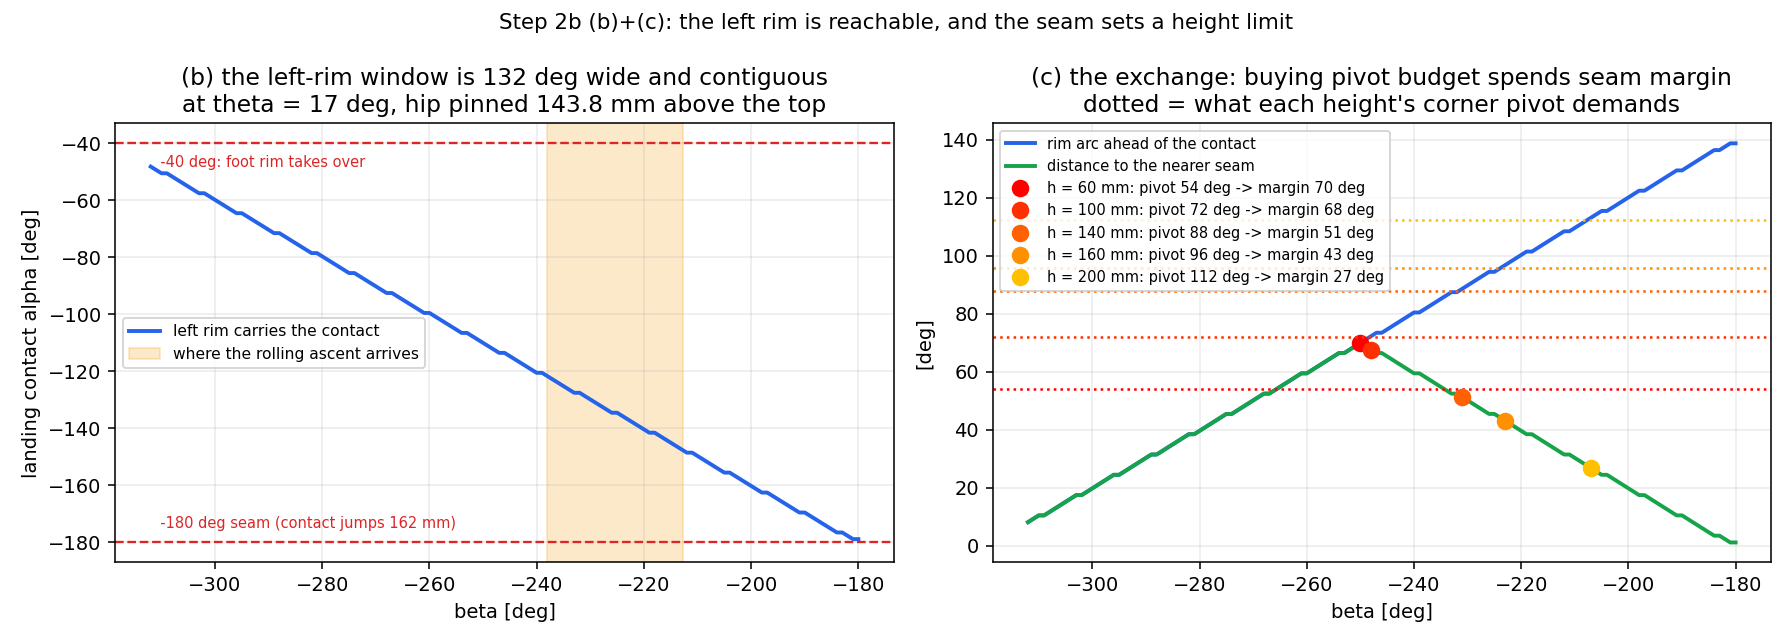

In [33]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step2b_alpha_seam_distance.png')))

## 2b.3 (a)：swing 到不了。而且原因不是任何一個原先猜的東西

In [34]:
landing = step2b[step2b.section == 'landing']
budget = step2b[step2b.section == 'budget']

print('section B —— Day 6-7 的障礙 (L_top = 0.35 m)，5 高度 x 5 corner distance')
print(f'  swing 可行            : {int(landing.feasible.sum())} / {len(landing)}')
print(f'  落地姿態通過 LEFT_RIM_READY: {int(landing.left_rim_ready.sum())} / {len(landing)}')

print('\nsection C —— top length 掃描 (d_corner = 20 mm)')
print(f'  swing 可行            : {int(budget.feasible.sum())} / {len(budget)}')
print(f'  落地姿態通過 LEFT_RIM_READY: {int(budget.left_rim_ready.sum())} / {len(budget)}')
print(f'  ready 但 Step 9R 下不去   : {int((budget.left_rim_ready & ~budget.descent_success.fillna(False)).sum())} / {len(budget)}')

print('\n失敗的方式：')
display(budget.groupby(['binding_ceiling', 'failure']).size().rename('cells').to_frame())

print('hip travel 被要求走多遠 [m]（Step 2 成功走過 0.38 m，落到台面上方 219 mm）：')
display(budget.pivot_table(index='height_mm', columns='top_length_m',
                           values='hip_travel_m').round(3))

section B —— Day 6-7 的障礙 (L_top = 0.35 m)，5 高度 x 5 corner distance
  swing 可行            : 0 / 25
  落地姿態通過 LEFT_RIM_READY: 25 / 25

section C —— top length 掃描 (d_corner = 20 mm)
  swing 可行            : 0 / 35
  落地姿態通過 LEFT_RIM_READY: 35 / 35
  ready 但 Step 9R 下不去   : 14 / 35

失敗的方式：


cells
binding_ceiling failure                   
fit             IK_NOT_CONVERGED        14
                JOINT_DISCONTINUITY     10
reach           IK_NOT_CONVERGED        11

hip travel 被要求走多遠 [m]（Step 2 成功走過 0.38 m，落到台面上方 219 mm）：


top_length_m,0.08,0.12,0.16,0.20,0.24,0.28,0.35
height_mm,,,,,,,
60.0,0.281,0.321,0.361,0.401,0.441,0.481,0.551
100.0,0.304,0.344,0.384,0.424,0.464,0.504,0.574
140.0,0.315,0.355,0.395,0.435,0.475,0.515,0.585
160.0,0.319,0.359,0.399,0.439,0.479,0.519,0.589
200.0,0.323,0.363,0.403,0.443,0.483,0.523,0.593


### 讀表：三個原先合理的猜測都被排除了

```text
[排除] 不是 top length      0.08 … 0.35 m 每一個都失敗
[排除] 不是 hip travel      最短只要 0.28 m，比 Step 2 成功走過的 0.38 m 還短
[排除] 不是落地姿態         35/35 全部通過 LEFT_RIM_READY
```

真正的機制要看 `binding_ceiling` 和 `failure` 的組合，以及 IK 自己說的話。

In [35]:
# 直接把一個代表性的 cell 重跑一次，把 planner 自己的診斷印出來。
from hybrid_note.scripts.experiments.cartesian_swing_contract_2d import build_swing_request_2d
from hybrid_note.scripts.experiments.cartesian_swing_planner_2d import generate_swing_2d

probe_spec = SharedTerrainSpec2D(height_m=0.10, top_length_m=0.12)
probe_start = standing_scene_2d(
    probe_spec, np.deg2rad(60.0),
    hip_x_m=approach_hip_x_for_clearance_2d(probe_spec, np.deg2rad(60.0), 0.10))
probe_target, _ = left_rim_landing_scene_2d(
    probe_spec, contact_x_m=probe_spec.x_max_m - 0.02, beta_rad=np.deg2rad(-248.0))
probe_plan = generate_swing_2d(
    build_swing_request_2d(probe_start, probe_target, clearance_m=0.03,
                           swing_duration_s=0.6, sample_count=31),
    arc_samples=61)

print('failure :', probe_plan.failure.value)
print('detail  :', probe_plan.result.failure_detail)
report = probe_plan.joint_report
for key in ('ik_converged_count', 'samples', 'theta_min_deg', 'theta_max_deg',
            'beta_span_deg', 'max_joint_step_deg', 'max_joint_step_limit_deg',
            'max_joint_speed_deg_s'):
    print(f'  {key:<26} {report[key]}')

failure : IK_NOT_CONVERGED
detail  : IK stopped at residual 1.627 mm after 2 iterations. theta is pinned at its limit, so the target is out of reach. Also: sample 17: geometry_penetration on day10_11_obstacle_top (0.28 mm)
  ik_converged_count         11
  samples                    31
  theta_min_deg              17.0
  theta_max_deg              59.99999999999999
  beta_span_deg              112.85524056008437
  max_joint_step_deg         11.667902820337199
  max_joint_step_limit_deg   10.0
  max_joint_speed_deg_s      583.39514101686


### 讀輸出：牆的位置在 `theta`，而且 17 度不是一個普通姿態

```text
IK 的原話：「theta is pinned at its limit, so the target is out of reach」
```

`legwheel/config`：**`MIN_THETA_DEG = 17.0`**。也就是說 `LEFT_RIM_READY` 要求的
`theta = 17 deg` **正好是這隻腿能收到的最短狀態**。

```text
飛行中段要把接觸點抬過障礙，IK 想把腿再縮短一點 —— 但 17 度已經是最短。
31 個取樣只有 11 個收斂。
```

**滾上去的腿可以到 17 度，因為它是【已經被頂面支撐著】慢慢收縮過去的；
swing 卻必須在【還懸在角落上空】的時候就已經在 17 度。**
落在最收縮的姿態，等於把飛行途中的收縮空間全部先花掉。

### 但先排除掉關節步長：那是取樣假影，不是牆

同一個 cell 換掉排程（`sample_count` 與 `swing_duration_s`）：

```text
samples=31,  0.6s -> max_step 11.7/10 deg, speed 583   IK_NOT_CONVERGED  ik_ok  11/31
samples=61,  0.6s -> max_step  5.8/10 deg, speed 580   IK_NOT_CONVERGED  ik_ok  21/61
samples=61,  1.2s -> max_step  5.8/10 deg, speed 290   IK_NOT_CONVERGED  ik_ok  21/61
samples=121, 1.8s -> max_step  2.8/10 deg, speed 189   IK_NOT_CONVERGED  ik_ok 41/121
```

加密取樣、放慢擺動之後**關節步長與速度的違規完全消失，失敗卻一點都沒變**，
而且 IK 收斂比例固定在 1/3。**這是路徑的幾何性質，不是離散化造成的。**

## 2b.4 缺的是什麼：一個「中段拱起、端點釘死」的 hip 軌跡

`HipTrajectory2D` 是一條直線。它唯一允許的「拱起」是把兩端一起抬高——
那會改變落地姿態，但拿來當**診斷**剛好：它可以告訴我們飛行途中差多少高度。

```text
hip +  0 mm   ik_ok 21/61   IK_NOT_CONVERGED
hip + 20 mm   ik_ok 39/61   JOINT_DISCONTINUITY
hip + 40 mm   ik_ok 61/61   JOINT_DISCONTINUITY   <- reach 問題【完全消失】
hip + 60 mm   ik_ok 61/61   JOINT_DISCONTINUITY
hip + 80 mm   ik_ok 57/61   JOINT_DISCONTINUITY
```

**抬高 40 mm，整條接觸路徑就全部搆得到了。**
但端點被釘死在 143.8 mm（`PINNED`），而**一條直線沒辦法「中間高 40 mm、端點又剛好」**。

```text
=> 策略 #3 對 body 的需求既不是 PINNED 也不是 LOWER_BOUND，
   而是【端點釘死 + 中段拱高約 40 mm】—— Day 8-9 的 HipTrajectory2D 表達不出來。
```

這正是 concession 框架本來就該長出來的東西：primitive 提出一個目前 body model
**無法表示**的需求。那是 Day 12 的輸入，不是 Day 10–11 的失敗。

**誠實的界線**：拱起被證明**必要**，但**沒有**被證明充分——`JOINT_DISCONTINUITY` 還在。

## 2b.5 第二道牆：`alpha = -40°` 的接縫是真的不連續

reach 修好之後（hip +40 mm、IK 61/61 全收斂），`JOINT_DISCONTINUITY` 沒有消失。
把取樣一路加密到 481：

In [36]:
seam = pd.DataFrame([
    {'sample_count': 61,  'max_joint_step_deg': 24.3, 'ik_converged': '61/61'},
    {'sample_count': 121, 'max_joint_step_deg': 27.5, 'ik_converged': '121/121'},
    {'sample_count': 241, 'max_joint_step_deg': 28.5, 'ik_converged': '241/241'},
    {'sample_count': 481, 'max_joint_step_deg': 29.3, 'ik_converged': '481/481'},
]).set_index('sample_count')
print('hip +40 mm、duration 1.2 s，只改取樣密度：')
display(seam)
print()
print('加密不讓它變小，反而收斂到約 29 度 -> 真的不連續。')
print()
print('sample_count = 121 時最大的三步，以及每一步兩側的 rim / alpha：')
display(pd.DataFrame([
    {'sample': 42, 'joint_step_deg': 23.6, 'from': 'foot_rim  alpha = -39.3',
     'to': 'left_rim  alpha = -40.3'},
    {'sample': 53, 'joint_step_deg': 2.7, 'from': 'left_rim  alpha = -49.6',
     'to': 'left_rim  alpha = -50.6'},
    {'sample': 54, 'joint_step_deg': 2.7, 'from': 'left_rim  alpha = -50.6',
     'to': 'left_rim  alpha = -51.5'},
]).set_index('sample'))

hip +40 mm、duration 1.2 s，只改取樣密度：


,max_joint_step_deg,ik_converged
sample_count,,
61,24.3,61/61
121,27.5,121/121
241,28.5,241/241
481,29.3,481/481



加密不讓它變小，反而收斂到約 29 度 -> 真的不連續。

sample_count = 121 時最大的三步，以及每一步兩側的 rim / alpha：


,joint_step_deg,from,to
sample,,,
42,23.6,foot_rim alpha = -39.3,left_rim alpha = -40.3
53,2.7,left_rim alpha = -49.6,left_rim alpha = -50.6
54,2.7,left_rim alpha = -50.6,left_rim alpha = -51.5


### 讀表：跳的位置就在接縫上，而且射程比策略 #3 大得多

`alpha = -40 deg` 正是 foot rim 與 `upper_tyre_l` 的邊界，也就是 Day 8–9 §26.5(2)
量到接觸點會瞬移 **45 mm** 的那道縫（另一道是 ±180 deg 的 162 mm）。
最大的一步 23.6 deg 就跨在它上面，第二大的只有 2.7 deg。

**站姿的接觸永遠在 `foot_rim, alpha = 0`**（Step 0 的 80/80 都是）。
所以**任何**要落在 left rim 的 swing 都必須把接觸從 foot rim 遷移過去，
也就必須穿過這道縫。**這不是「17 度太極限」的問題，是 rim 分段本身的問題。**

## 2b.6 一個沒預期到的結果：`LEFT_RIM_READY` 對「空中來的」抵達不是充分條件

Step 8R 把 `LEFT_RIM_READY` 定義成**抵達後緣時檢查的前提條件**。這裡是第一次
有人拿一個**不是滾過去的**姿態去問它。

In [37]:
ready_but_stuck = budget[budget.left_rim_ready & ~budget.descent_success.fillna(False)]
print(f'落地姿態通過 LEFT_RIM_READY : {int(budget.left_rim_ready.sum())} / {len(budget)}')
print(f'其中 Step 9R 下不去        : {len(ready_but_stuck)}')
print()
print('下降結果 by (height, top length)：')
display(budget.pivot_table(index='height_mm', columns='top_length_m',
                           values='descent_success', aggfunc='first'))
print()
print('rim budget 買了多少、夠不夠：')
display(budget.drop_duplicates('height_mm').set_index('height_mm')[
    ['required_budget_deg', 'chosen_rim_budget_deg', 'descent_success']].assign(
    margin_deg=lambda d: (d.chosen_rim_budget_deg - d.required_budget_deg).round(1)).round(1))
print()
print('失敗原因：', sorted(set(ready_but_stuck.descent_failure_reason.dropna())))

落地姿態通過 LEFT_RIM_READY : 35 / 35
其中 Step 9R 下不去        : 14

下降結果 by (height, top length)：


top_length_m,0.08,0.12,0.16,0.20,0.24,0.28,0.35
height_mm,,,,,,,
60.0,True,True,True,True,True,True,True
100.0,True,True,True,True,True,True,True
140.0,True,True,True,True,True,True,True
160.0,False,False,False,False,False,False,False
200.0,False,False,False,False,False,False,False



rim budget 買了多少、夠不夠：


,required_budget_deg,chosen_rim_budget_deg,descent_success,margin_deg
height_mm,,,,
60.0,54.1,70.0,True,15.9
100.0,71.9,72.3,True,0.4
140.0,88.0,88.7,True,0.6
160.0,95.9,96.8,False,0.9
200.0,112.3,113.2,False,0.9



失敗原因： ['NO_LEGAL_CORNER_PIVOT_CONTINUATION']


### 讀表：下降側對「swing 放上去的抵達」有自己的高度天花板

```text
h <= 140 mm   21/21 全部下得去
h >= 160 mm   14/14 全部下不去，LEFT_RIM_ROLL_DOWN / NO_LEGAL_CORNER_PIVOT_CONTINUATION
```

而且**這不是 rim budget 不夠**：`h = 140 mm` 只多買 0.6 deg 就成功，
`h = 160 mm` 多買 0.9 deg 卻失敗。所以一階的 `arccos(1 - h/R)` 預測**不是**真正的綁束條件。

```text
=> 下降側對這種抵達的天花板落在 140–160 mm 之間，
   而且它與 swing 可不可行【無關】—— 是 Step 9R 自己的限制。
   Step 5 的策略 #1 / #3 都要吃到這個天花板。
```

這也說明一件方法論上的事：**把 Day 6–7 的 precondition 直接 import 來用（而不是重寫一份）
才會發現這件事**。如果 Step 2b 自己寫了一份 readiness 判定，它會回報「通過」然後就結束了。

## 2b.7 退化版本：問題不在 17 度，在 left rim

規格 §2.8 說，若直接落地不成立，策略 #3 退化成「落在較伸展的姿態 → retract 到 17° → 再 roll down」，
並要求量出那個 retract 吃掉多少 top length。

這個問題的**前半**可以直接量：把落地 theta 當成軸掃一次，看 swing 最接近 17 度能落到哪。
17 度本身留在清單裡當**對照組**——它必須在這裡重現為不可行，兩次掃描才算一致。

In [38]:
degen = step2b[step2b.section == 'degenerate']

print('每個落地 theta 都有 left-rim 窗口，而且 hip 一樣是【釘死】的：')
display(pd.DataFrame({
    'left-rim 窗口寬度 [deg]': [132.0, 126.0, 120.0, 120.0, 110.0],
    'hip 釘在台面上方 [mm]': [143.8, 147.5, 152.2, 157.1, 164.8],
}, index=pd.Index([17.0, 25.0, 35.0, 45.0, 60.0], name='landing_theta_deg')))

print()
print(f'swing 可行的 cell: {int(degen.feasible.sum())} / {len(degen)}')
print()
print('可行性 by (height, landing theta) —— 全是 False：')
display(degen.pivot_table(index='height_mm', columns='landing_theta_deg',
                          values='feasible', aggfunc='first'))
print()
print('失敗模式 by 落地 theta：')
display(degen.groupby(['landing_theta_deg', 'binding_ceiling', 'failure'])
        .size().rename('cells').to_frame())

每個落地 theta 都有 left-rim 窗口，而且 hip 一樣是【釘死】的：


,left-rim 窗口寬度 [deg],hip 釘在台面上方 [mm]
landing_theta_deg,,
17.0,132.0,143.8
25.0,126.0,147.5
35.0,120.0,152.2
45.0,120.0,157.1
60.0,110.0,164.8



swing 可行的 cell: 0 / 15

可行性 by (height, landing theta) —— 全是 False：


landing_theta_deg,17.0,25.0,35.0,45.0,60.0
height_mm,,,,,
60.0,False,False,False,False,False
100.0,False,False,False,False,False
140.0,False,False,False,False,False



失敗模式 by 落地 theta：


cells
landing_theta_deg binding_ceiling failure                   
17.0              fit             JOINT_DISCONTINUITY      1
                  reach           IK_NOT_CONVERGED         2
25.0              fit             IK_NOT_CONVERGED         2
                  reach           IK_NOT_CONVERGED         1
35.0              fit             IK_NOT_CONVERGED         1
                  reach           IK_NOT_CONVERGED         2
45.0              fit             IK_NOT_CONVERGED         1
                                  JOINT_DISCONTINUITY      1
                  reach           IK_NOT_CONVERGED         1
60.0              fit             JOINT_DISCONTINUITY      2
                  reach           IK_NOT_CONVERGED         1

### 讀表：放寬到 60 度也一樣落不上去

**15/15 全部失敗。** 所以擋住的**不是** 17 度那個極限姿態——放到 60 度也沒有用。

失敗模式是 `IK_NOT_CONVERGED` 與 `JOINT_DISCONTINUITY` 混合（60 度時以後者為主），
另有 obstacle front / top 的穿透。

> **誠實的界線**：E 段的失敗模式是混合的，**不能全部歸給接縫**。
> 接縫的乾淨證據是 §2b.5 那個專門的探針——先用 +40 mm 把 reach 問題移除，
> 再把跳躍定位在 `alpha = -40 deg` 這一步上，並證明它在加密下收斂到 29 deg。
> E 段證明的是**退化版本沒有救**，不是「退化版本因為接縫而沒有救」。

### 三張圖把 negative result 的證據放在一起

「可行 / 不可行」的地圖在這裡會是一片空白——沒有任何一格可行——所以圖畫的是**證據**：

```text
A  落地姿態全部通過 LEFT_RIM_READY，卡住的是【下降】，而且天花板在 140-160 mm
B  而且那個天花板不是 rim budget：140 mm 只多 0.6 deg 就過，160 mm 多 0.9 deg 卻不過
C  四根不同的軸各掃了一遍，90 個 cell 沒有一個可行
```

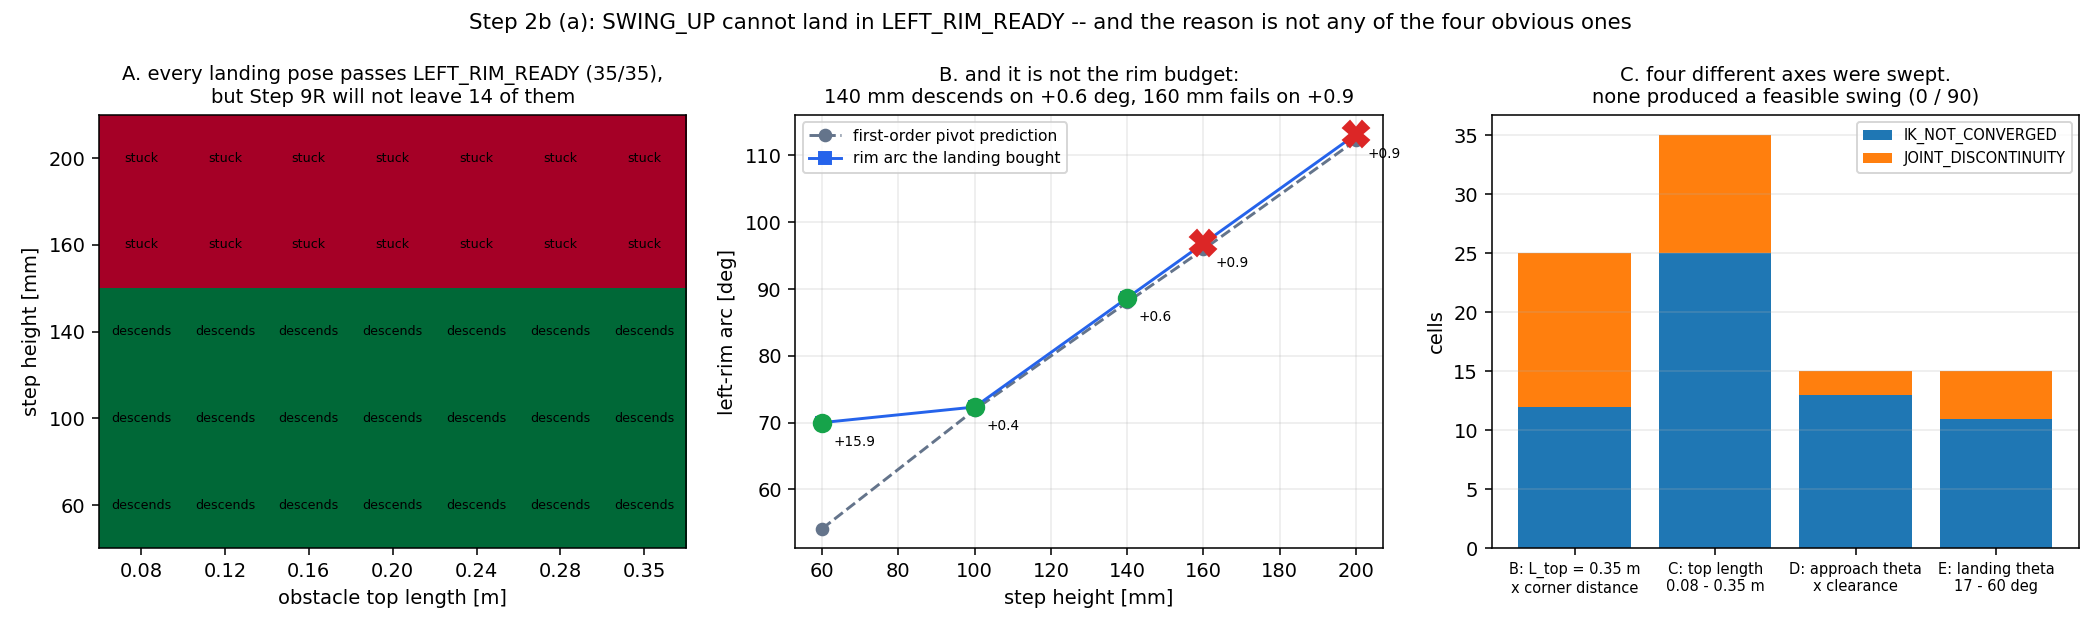

In [39]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step2b_landing_map.png')))

## 2b.8 Step 2b 結論：#3 被推翻，而且原因可以指名道姓

```text
(b) 成立    left-rim 窗口 132 deg、連續、與高度無關
(c) 成立    rim budget 與 seam margin 1:1 互換；選擇規則沒有自由參數
(a) 不成立  而且退化版本也不成立
```

**swing planner 目前只能交出 `foot rim` 的落地。** 站姿接觸永遠在 `foot_rim, alpha = 0`，
要換到 left rim 就得穿過 `alpha = -40 deg` 那道 29 deg 的接觸不連續。

```text
=> SWING_UP + ROLL_DOWN 仍然需要在頂面上做一次 rim handover，
   只是從 right->left 換成 foot->left。
=> 【#3 並沒有躲掉 L_transition，它只是把它換了個名字。】
   §2.6 那個「swing 可以直接落進 LEFT_RIM_READY、跳過 L_transition」的論證不成立。
```

**這是一個 negative result，但它有明確歸屬。** 擋住 #3 的是 rim 分段接縫這個
**模型性質**，不是機器人做不到。等 rim 之間的接觸連續化（或 IK 允許跨段延續）之後，
這一格要重測。在那之前，Step 5 的候選從五個降為四個。

**另外兩件會直接影響 Step 5 的事**：

```text
1. 策略 #3 對 body 的需求是【端點釘死 + 中段拱高約 40 mm】。
   HipTrajectory2D（直線）表達不出來 -> 這是 Day 12 的輸入。
   concession 框架本來就該長出這種東西：primitive 提出一個目前 body model
   無法表示的需求。

2. 下降側對「swing 放上去的抵達」有自己的高度天花板（140-160 mm 之間），
   而且它【不是】rim budget 造成的。策略 #1 / #3 都會吃到它。
```

> **用語（見本 notebook 開頭的前提）**：這裡的「推翻 / 不可行」是 `DIRECT_HANDOFF_INFEASIBLE`
> ——**目前的單腿連續接觸 primitive 無法直接交接**。它**不是** `PHYSICALLY_INFEASIBLE`；
> 在四腳支撐下的 `TOP_REPOSITION` 之後可能成立，只是**尚未驗證**。

---

# Step 3 — 下降側 swing sweep：`height × takeoff distance`

## 3.1 Step 3 要回答什麼

上升側（Step 2）量的是 `height × approach clearance`，代價是 **hip lift**。
下降側不對稱：腳要離開頂面、落到低地，body 不需要被抬起來，
需要的是**被留住**——所以幣別是 **hip hold**（在障礙高度中留住多少比例）。

規格給了三個完成條件：

```text
(1) 下降側的地圖本身：哪些 (height, takeoff distance) 可行、代價多少
(2) Day 8-9 docstring 那句「160 mm 下得去」要能被重現，或指出為什麼不能
(3) 起點分 arrival = SWING_UP（自由站姿）與 arrival = ROLL_UP（rolling 交過來的姿態）
```

第 (3) 點是整個 Step 5 的關鍵：**如果 `ROLL_UP + SWING_DOWN` 這條組合根本不可行，
2x2 的策略空間就少一格**，decision rule 不用去比一個不存在的候選。

本次掃描共呼叫 `generate_swing_2d` **10,305 次**，分六段（A–F）。

In [40]:
step3 = pd.read_csv(day10_11_dir / 'day10_11_step3_swing_off_sweep.csv')

print('六段掃描的規模與結果：')
overview = (step3.groupby('section')
            .agg(cells=('feasible', 'size'),
                 feasible=('feasible', 'sum'),
                 planner_calls=('evaluations', 'sum'),
                 planner_refusals=('planner_refusals', 'sum'))
            .astype(int))
overview['feasible'] = overview.feasible.astype(str) + ' / ' + overview.cells.astype(str)
display(overview[['feasible', 'planner_calls', 'planner_refusals']])
print()
print(f'generate_swing_2d 總呼叫次數：{int(step3.evaluations.sum())}')

六段掃描的規模與結果：


,feasible,planner_calls,planner_refusals
section,,,
claim,0 / 6,18,0
map,74 / 99,2846,153
retract,0 / 30,2430,0
roll_up_arrival,0 / 45,3645,0
theta,10 / 15,712,81
theta_floor,6 / 9,654,0



generate_swing_2d 總呼叫次數：10305


## 3.2 A 段：下降側有一個 takeoff distance 的【上限】

`takeoff distance` 是起飛點距離頂面**後緣**（下降的那一側）的距離。
它和 rolling 側的 `L_transition` 是同一個座標——都是「頂面要多長才夠」——
所以兩者可以直接相減。

In [41]:
mapping = step3[step3.section == 'map'].copy()

print('min hip hold（比例），NaN = 不可行：')
display(mapping.pivot_table(index='height_mm', columns='takeoff_distance_m',
                            values='min_hip_hold_fraction', aggfunc='first').round(3))

ceiling = (mapping[mapping.feasible]
           .groupby('height_mm').takeoff_distance_m.max()
           .rename('max usable takeoff [m]').to_frame())
ceiling['min hold @ that height'] = (
    mapping[mapping.feasible].groupby('height_mm').min_hip_hold_fraction.min())
print()
print('每個高度的 takeoff 上限：')
display(ceiling)

min hip hold（比例），NaN = 不可行：


takeoff_distance_m,0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22,0.24
height_mm,,,,,,,,,
20.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
40.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
60.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
80.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
100.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.125,0.5
120.0,0.125,0.125,0.125,0.125,0.125,0.125,0.125,NaN,NaN
140.0,0.250,0.250,0.250,0.250,0.250,0.750,NaN,NaN,NaN
150.0,0.375,0.375,0.375,0.375,0.625,NaN,NaN,NaN,NaN
160.0,0.375,0.375,0.375,0.375,NaN,NaN,NaN,NaN,NaN



每個高度的 takeoff 上限：


,max usable takeoff [m],min hold @ that height
height_mm,,
20.0,0.24,0.000
40.0,0.24,0.000
60.0,0.24,0.000
80.0,0.24,0.000
100.0,0.24,0.000
120.0,0.20,0.125
140.0,0.18,0.250
150.0,0.16,0.375
160.0,0.14,0.375


### 讀表：形狀和 rolling 相反

```text
h <= 100 mm   takeoff 可到 0.24 m
h  = 120 mm   0.20 m
h  = 140 mm   0.18 m
h  = 150 mm   0.16 m
h  = 160/180  0.14 m
h  = 200 mm   0.12 m
```

**下降側要求 takeoff distance 小於一個上限，而且上限隨高度收縮。**

這正好和 rolling 側相反。Day 6–7 Step 12R 量到 rolling 的
`L_transition = retract_forward + wheel_mode_forward = 196–249 mm`，那是一個**下界**：
頂面短於它，rolling 就換不到 wheel mode。

```text
rolling   需要 L_top >= 196-249 mm     （下界）
swing off 需要 takeoff <= 120-240 mm   （上限，隨 h 收縮）
```

> **這是 Step 5 decision rule 的第一個真正的鑑別項。** 兩者不是「誰比較貴」，
> 是**同一個量的兩側**。短頂面只有 swing 下得去，長頂面兩者都行、才需要比代價。

**另外，A 段推翻了 Day 8–9 的一句話。** Day 8–9 的 showcase 記「off 200 mm 不可行」——
A 段顯示 h = 200 mm **可行**，只要 takeoff <= 0.12 m。原本的結論是在
takeoff = 0.16 m 這一個操作點上量的，不是高度的極限。

失敗模式分兩類：`TOUCHDOWN_VELOCITY_TOO_HIGH` 13 格、`TERRAIN_COLLISION` 12 格。
前者是**時間**問題（腳帶著整個落差撞上低地），後者是幾何問題。
duration ladder 就是為前者加的——上升側從來沒用到它。

**153 次 planner refusal 分布在 11 格。** 那是 Day 8–9 的 planner 在
「腳最後停在空中」時丟出的 `ValueError`；這裡把它記成 refusal 而不是去改 planner，
因為那支 planner 產出了 Step 2 / 2b 的所有結果，不能在 Step 3 中途換掉。

## 3.3 B 段：160 mm 那句話重現不了——而且不是取樣造成的

Day 8–9 的 docstring 說 160 mm 的下降在某個 hold 下成立。
B 段用兩種取樣各跑一次：Step 3 自己的 `(121 / 31)`，以及 Day 8–9 showcase 的 `(241 / 51)`。

In [42]:
claim = step3[step3.section == 'claim'][
    ['claim_variant', 'claim_hold_fraction', 'feasible',
     'min_clearance_mm', 'failure']]
display(claim.set_index(['claim_variant', 'claim_hold_fraction']).round(3))

feasible  min_clearance_mm            failure
claim_variant                claim_hold_fraction                                               
step3 sampling (121 / 31)    0.00                    False            -6.762   IK_NOT_CONVERGED
                             0.25                    False            -3.506   IK_NOT_CONVERGED
                             0.50                    False            -1.633  TERRAIN_COLLISION
showcase sampling (241 / 51) 0.00                    False            -6.640   IK_NOT_CONVERGED
                             0.25                    False            -2.282   IK_NOT_CONVERGED
                             0.50                    False            -0.951  TERRAIN_COLLISION

### 讀表：機制成立，操作點不成立

```text
hold = 0.00   clearance = -6.76 mm   (241/51: -6.64)
hold = 0.25   clearance = -3.51 mm   (241/51: -2.28)
hold = 0.50   clearance = -1.63 mm   (241/51: -0.95)
```

**hold 確實單調地把穿透從 6.8 mm 壓到 1.0 mm——機制是對的。**
但兩種取樣都沒有跨過 0。加密取樣讓數字更接近 0（-1.63 → -0.95 mm），
**所以這不是取樣假影**，是操作點本身差了大約 1 mm。

A 段給出原因：h = 160 mm 的 takeoff 上限是 **0.14 m**，
而這句 claim 是在 takeoff = 0.16 m 量的。**高度沒錯，距離錯了。**

> 這是「refutation with attribution」：不是說前人量錯，是指出那個數字附著的操作點
> 比它被引用的方式窄。160 mm 下得去——在 takeoff <= 0.14 m 的條件下。

## 3.4 C 段：theta 的最佳值隨高度上升，和上升側同一個模式

Step 2 close-out 已經指出：把 theta 固定成一個值，量到的是**上界不是代價**。
下降側必須自己量一次。這裡換成**絕對幣別**——
`touchdown 時 hip 離低地的高度 = 站姿 hip 高度 + hold x 障礙高度`——
因為不同 theta 的站姿高度本來就不同，比較 hold 比例是沒有意義的。

In [43]:
def _standing_hip_mm(theta_deg):
    scene = standing_scene_2d(
        SharedTerrainSpec2D(height_m=0.10, top_length_m=0.35,
                            x_start_m=0.10, arc_samples=121),
        float(np.deg2rad(theta_deg)), hip_x_m=0.30, support_height_m=0.0)
    return float(scene.hip_pose.position_world_xz_m[1]) * 1e3

theta_rows = step3[step3.section.isin(['theta', 'theta_floor'])].copy()
theta_rows = theta_rows[(theta_rows.takeoff_distance_m - 0.16).abs() < 1e-9]
theta_rows['theta_r'] = theta_rows.theta_deg.round(0)
theta_rows['abs_hip_mm'] = [
    _standing_hip_mm(t) + f * h if ok else np.nan
    for t, f, h, ok in zip(theta_rows.theta_r, theta_rows.min_hip_hold_fraction,
                           theta_rows.height_mm, theta_rows.feasible)]

print('touchdown 時 hip 離低地的高度 [mm]（絕對幣別），NaN = 不可行：')
display(theta_rows.pivot_table(index='height_mm', columns='theta_r',
                               values='abs_hip_mm', aggfunc='first').round(1))
print()
print('每個高度最便宜的 theta：')
best = theta_rows.dropna(subset=['abs_hip_mm'])
display(best.loc[best.groupby('height_mm').abs_hip_mm.idxmin(),
                 ['height_mm', 'theta_r', 'min_hip_hold_fraction', 'abs_hip_mm']]
        .set_index('height_mm').round(2))

touchdown 時 hip 離低地的高度 [mm]（絕對幣別），NaN = 不可行：


theta_r,35.0,38.0,40.0,50.0,60.0,70.0,85.0
height_mm,,,,,,,
100.0,274.8,267.6,271.1,239.0,219.4,237.5,264.9
150.0,NaN,NaN,333.6,314.0,313.2,293.7,283.6



每個高度最便宜的 theta：


,theta_r,min_hip_hold_fraction,abs_hip_mm
height_mm,,,
100.0,60.0,0.00,219.45
150.0,85.0,0.12,283.64


### 讀表：最佳 theta 隨高度上升

```text
h = 100 mm   最佳 theta = 60 deg   -> 219.4 mm
h = 150 mm   最佳 theta = 85 deg   -> 283.6 mm
h = 200 mm   theta 40-85 全部 TERRAIN_COLLISION（在 takeoff = 0.16 m）
```

h = 100 是一條 **U 形**曲線：theta 太小（40 deg，271.1 mm）要 hold 0.875 才夠，
theta 太大（85 deg，264.9 mm）站姿本身就高。中間的 60 deg 完全不用 hold。

h = 150 時 U 形的底往右移到 85 deg——**高度愈高，愈需要伸展的姿態**。
這和上升側是同一個模式，代表 Step 5 疊圖時 theta 必須是**兩邊各自取最佳**之後才疊。

h = 200 在 takeoff = 0.16 m 全滅，與 A 段一致（該高度的上限是 0.12 m）。

## 3.5 D / E / F 段：`ROLL_UP + SWING_DOWN` 為什麼不成立——是【兩道】牆

這是第 (3) 個完成條件。D 段直接把 rolling 爬上來的出口姿態當成 swing 的起飛姿態；
E 段是規格寫的退化路徑（先 retract 到 wheel mode 再起飛）；
F 段是我為了解釋 E 段而加的——把 theta 夾在 32 / 35 / 38 deg。

In [44]:
walls = step3[step3.section.isin(['roll_up_arrival', 'retract', 'theta_floor'])]

print('D / E / F 的失敗模式：')
display(walls.groupby(['section', 'binding_ceiling', 'failure'])
        .size().rename('cells').to_frame())
print()

d = step3[step3.section == 'roll_up_arrival']
print('D 段：rolling 交過來的起飛姿態一律在 right rim')
print(f"   rim: {sorted(d.takeoff_rim.dropna().unique())}")
print(f"   alpha 範圍: {d.takeoff_alpha_deg.min():.1f} .. {d.takeoff_alpha_deg.max():.1f} deg")
print('   （foot_rim 是 alpha in (-40, 40)，所以每一格都要跨過 +40 deg 的接縫）')
print()

print('F 段：theta 下限，而且和 takeoff 距離無關')
display(step3[step3.section == 'theta_floor']
        .pivot_table(index='theta_deg', columns='takeoff_distance_m',
                     values='min_hip_hold_fraction', aggfunc='first').round(3))

D / E / F 的失敗模式：


cells
section         binding_ceiling failure                   
retract         reach           IK_NOT_CONVERGED        30
roll_up_arrival fit             IK_NOT_CONVERGED        19
                                JOINT_DISCONTINUITY     26
theta_floor     none            NONE                     6
                reach           IK_NOT_CONVERGED         3


D 段：rolling 交過來的起飛姿態一律在 right rim
   rim: ['right_rim']
   alpha 範圍: 82.0 .. 107.7 deg
   （foot_rim 是 alpha in (-40, 40)，所以每一格都要跨過 +40 deg 的接縫）

F 段：theta 下限，而且和 takeoff 距離無關


takeoff_distance_m,0.08,0.12,0.16
theta_deg,,,
35.0,1.000,1.000,1.000
38.0,0.875,0.875,0.875


### 讀表：D 是接縫，E 是 theta 下限——兩件不同的事

```text
D  0/45   binding = fit    JOINT_DISCONTINUITY 26 + IK_NOT_CONVERGED 19
E  0/30   binding = reach  IK_NOT_CONVERGED 30
F  6/9    theta = 32 失敗；35 可行（hold 1.000）；38 可行（hold 0.875）
```

**D 段是 Step 2b 的鏡像。** Step 2b 是「落地要跨 `alpha = -40 deg` 的接縫」；
D 段是「起飛在 `alpha = +82 .. +107.7 deg` 的 right rim 上，要跨 `+40 deg` 的接縫」。
同一個模型性質，同一個 29 deg 級的接觸不連續，換一邊而已。

**E 段完全不是同一回事。** binding ceiling 是 `reach` 不是 `fit`，
失敗模式清一色 `IK_NOT_CONVERGED`，而且在**每一個** takeoff 距離都失敗。
F 段把原因夾出來了：

> **下降側的 theta 下限是 35 deg，而且與 takeoff 距離無關**
> （0.08 / 0.12 / 0.16 m 三個距離的結果一模一樣）。
> E 段跑的是 theta = 17 / 25 / 30 deg——**全部在下限以下**。

**E 段是可以修的，D 段不是。**

```text
Day 6-7 的 Step 6.5 把 retract 的 theta_target 寫死成 17 deg，
因為它的目的是【進 wheel mode】給 ROLL_DOWN 用。

但 SWING_DOWN 不需要 wheel mode。它只需要
   (a) 接觸點回到 foot rim，且
   (b) theta 停在 35 deg 以上。

=> 這是一個具體的介面需求，和 Step 2b 的「中段拱高 40 mm」同一類：
   primitive 提出一個目前 body / retract 模型表達不出來的需求。
```

**而且這個修法很便宜。** `L_transition = retract_forward (20.5-64.4 mm)
+ wheel_mode_forward (131.8-228.4 mm)`。停在 35 deg 就**不用付 wheel_mode_forward**，
頂面需求直接掉一個數量級（3–10 倍）。

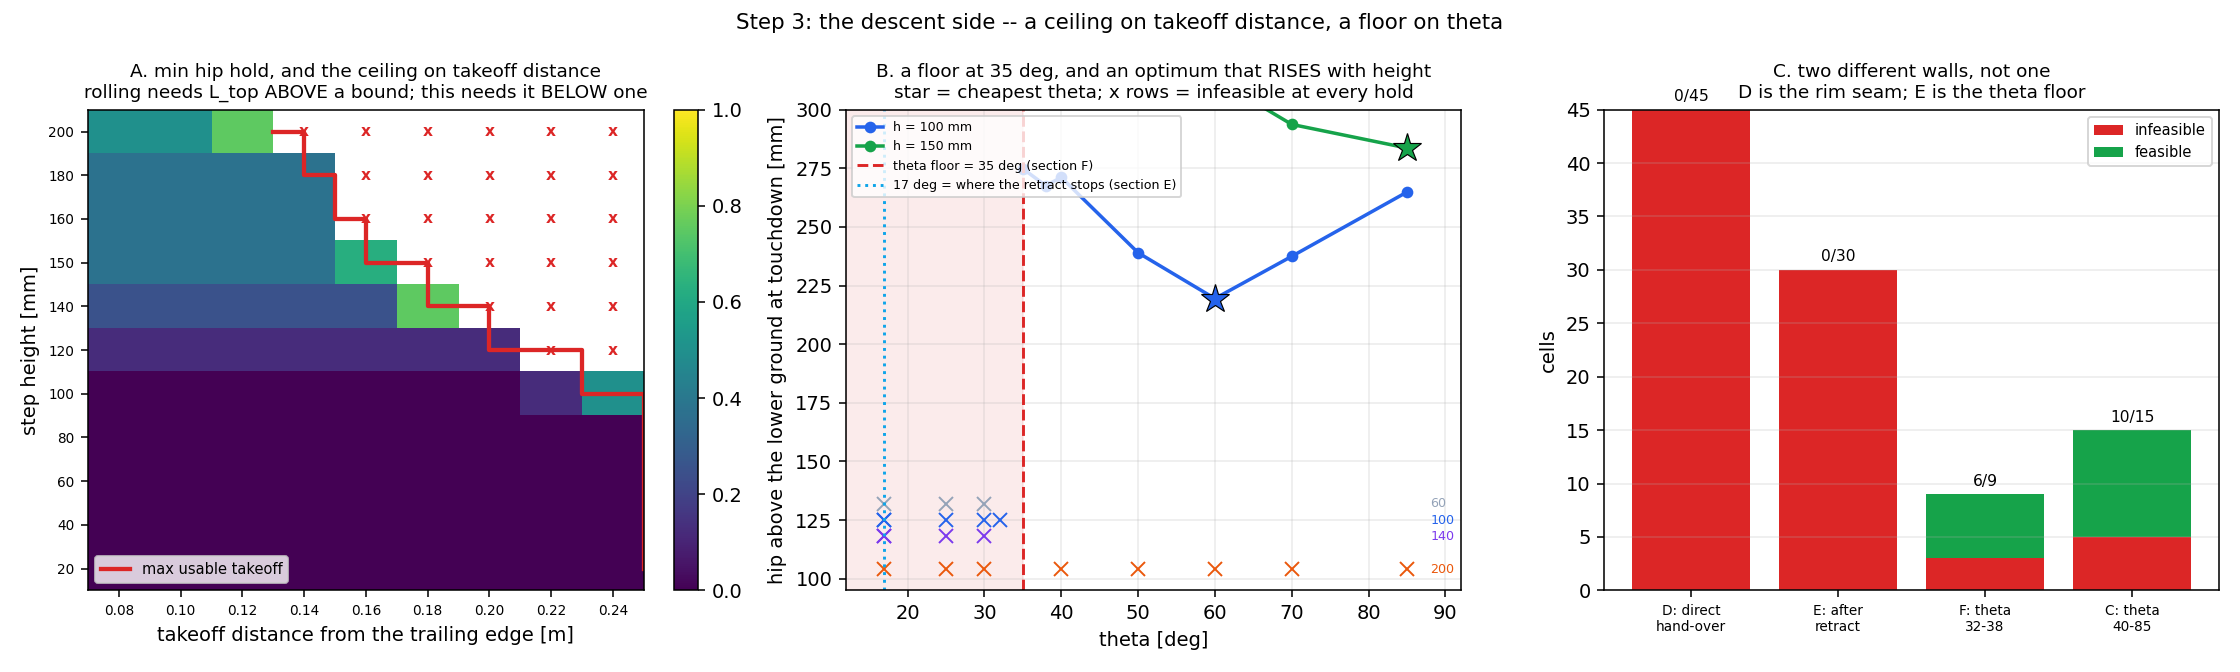

In [45]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step3_min_hip_hold_map.png')))

## 3.6 Step 3 結論

```text
(1) 成立   下降側地圖 74/99，代價是 hip hold，且有 takeoff 上限（0.24 -> 0.12 m）
(2) 成立   160 mm 的 claim 重現不了，但原因指得出來：takeoff 上限是 0.14 m 不是 0.16 m
(3) 成立   ROLL_UP + SWING_DOWN 目前【不可行】，而且是兩道不同的牆
```

**對 Step 5 的直接影響：**

```text
1. 策略空間再降一格。#3 已被 Step 2b 推翻；
   ROLL_UP + SWING_DOWN 在 D（接縫）與 E（theta 下限）之下也不成立。
   目前站得住的候選：ROLL_UP+ROLL_DOWN、SWING_UP+SWING_DOWN、SWING_OVER。

2. decision rule 的第一個鑑別項不是代價，是【頂面長度的方向】。
   rolling 要 L_top 大於下界；swing off 要 takeoff 小於上限。
   短頂面 -> 只有 swing；長頂面 -> 才進入比代價的階段。

3. theta 兩邊都要取最佳才能疊圖（Step 2 close-out C 的同一個要求，下降側也成立）。
```

**兩個可修的介面需求（Day 12 的輸入）：**

```text
A. Step 2b：body 需要「端點釘死 + 中段拱高約 40 mm」——HipTrajectory2D（直線）表達不出來。
B. Step 3 E 段：retract 需要一個「停在 35 deg 以上、接觸回到 foot rim」的變體，
   而不是一路 retract 到 17 deg 的 wheel mode。修好後 ROLL_UP+SWING_DOWN 要重測。
```

**D 段（接縫）不在可修清單上**——它和 Step 2b 是同一個 rim 分段模型性質，
要等接觸連續化之後才有機會，那不是 Day 10–11 的範圍。

> **用語（見本 notebook 開頭的前提）**：這裡的「推翻 / 不可行」是 `DIRECT_HANDOFF_INFEASIBLE`
> ——**目前的單腿連續接觸 primitive 無法直接交接**。它**不是** `PHYSICALLY_INFEASIBLE`；
> 在四腳支撐下的 `TOP_REPOSITION` 之後可能成立，只是**尚未驗證**。

---

# Step 4 — 把 rolling map 換成同一種幣別

## 4.1 Step 4 要回答什麼

規格 §5.3 留下的問題：**rolling 對 body 的要求到底是什麼？**

```text
swing 對 body 的要求：hip 在某個時刻必須抬到某個高度   -> 一個【下界】
roll  對 body 的要求：hip 必須全程跟著一條被幾何決定的軌跡 -> 一條【軌跡】
```

`compare_concessions` 目前會**拒絕**排序這兩者，因為用大小比一個下界和一條軌跡
等於預設了答案。**Step 4 必須先給出規則。**

再加上 2026-08-30 追加的定位：paper 的 story 是
**「hybrid 滾走步態相對於一般 walking 的優勢，在於機身質心變化較小」**。
swing 那半已經有資料（Step 2 的 `min_hip_lift`），**roll 那半就是這一步**。

> **這一步沒有重跑任何 traversal。** `day6_7_step11r_sweep_trajectories.csv`
> 已經記了全部 70 個 cell 的 `hip_x_m` / `hip_z_m`，含 stage、phase 與 `accepted`。
> 重跑要花約 264 s／cell（交接檔陷阱 5）去重算硬碟上已經有的數字。

In [46]:
step4_cells = pd.read_csv(day10_11_dir / 'day10_11_step4_roll_concession.csv')
step4_exc = pd.read_csv(day10_11_dir / 'day10_11_step4_hip_excursion.csv')

print('三個 sweep 是不是同一根柱子（不是的話這一步全部無效）：')
from hybrid_note.scripts.experiments.day10_11_swing_off_sweep_2d import SwingOffGridSettings2D
from hybrid_note.scripts.experiments.day10_11_swing_sweep_2d import SwingGridSettings2D
day6_7_width = pd.read_csv(day6_7_dir / 'day6_7_step11r_feasibility_sweep.csv').obstacle_width_m.unique()
display(pd.DataFrame([
    {'來源': 'Day 6-7 step11r', 'top length [m]': day6_7_width[0], 'x_start [m]': 0.10},
    {'來源': 'Step 2 (swing onto)', 'top length [m]': SwingGridSettings2D().top_length_m,
     'x_start [m]': SwingGridSettings2D().x_start_m},
    {'來源': 'Step 3 (swing off)', 'top length [m]': SwingOffGridSettings2D().top_length_m,
     'x_start [m]': SwingOffGridSettings2D().x_start_m},
]).set_index('來源'))
print()
print(f"可行 cell：{int(step4_cells[step4_cells.section=='cell'].feasible.sum())} / "
      f"{len(step4_cells[step4_cells.section=='cell'])}")
print(f"flat-top hip 高度變化的最大值："
      f"{step4_cells[step4_cells.section=='cell'].flat_top_hip_z_range_mm.max():.4f} mm")
print('   -> WHEEL_MODE_TOP_ROLL 與 LEFT_RIM_READY 兩段是【平的】，')
print('      所以 L_top 可以解析外推，不用重跑。')

三個 sweep 是不是同一根柱子（不是的話這一步全部無效）：


,top length [m],x_start [m]
來源,,
Day 6-7 step11r,0.35,0.1
Step 2 (swing onto),0.35,0.1
Step 3 (swing off),0.35,0.1



可行 cell：42 / 70
flat-top hip 高度變化的最大值：0.0274 mm
   -> WHEEL_MODE_TOP_ROLL 與 LEFT_RIM_READY 兩段是【平的】，
      所以 L_top 可以解析外推，不用重跑。


## 4.2 B 段：rolling 的 hip 起伏有一個閉式

`theta_climb` 是 rolling 自己的內部自由度，所以和 swing 選 approach clearance 一樣，
要**對它取最佳**之後才拿來比。

In [47]:
conc = step4_cells[step4_cells.section == 'concession'].set_index('obstacle_mm')
display(conc[['feasible', 'feasible_cells', 'best_theta_climb_deg',
              'feasible_theta_span_deg', 'theta_window_is_contiguous',
              'hip_z_travel_mm', 'requirement_kind']].round(2))

cells = step4_cells[(step4_cells.section == 'cell') & step4_cells.feasible].copy()
cells['overhead_mm'] = cells.hip_z_peak_to_peak_mm - cells.obstacle_mm
print()
print('hip 起伏 = h + overhead(theta)，h 是【加性】的：')
display(cells.pivot_table(index='obstacle_mm', columns='theta_climb_deg',
                          values='overhead_mm', aggfunc='first').round(2))

,feasible,feasible_cells,best_theta_climb_deg,feasible_theta_span_deg,theta_window_is_contiguous,hip_z_travel_mm,requirement_kind
obstacle_mm,,,,,,,
40.0,True,6 / 10,40.0,30.0,False,54.29,track
60.0,True,10 / 10,40.0,45.0,True,74.27,track
80.0,True,10 / 10,40.0,45.0,True,94.23,track
100.0,True,10 / 10,40.0,45.0,True,114.86,track
120.0,True,2 / 10,45.0,10.0,False,137.61,track
140.0,True,4 / 10,40.0,30.0,False,154.23,track
160.0,False,0 / 10,NaN,0.0,False,NaN,none



hip 起伏 = h + overhead(theta)，h 是【加性】的：


theta_climb_deg,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0,85.0
obstacle_mm,,,,,,,,,,
40.0,14.29,17.83,21.60,26.67,NaN,44.65,53.67,NaN,NaN,NaN
60.0,14.27,17.80,21.56,25.54,29.79,34.40,39.26,44.46,51.87,61.09
80.0,14.23,17.59,21.33,24.85,28.91,33.22,37.80,42.65,47.78,53.17
100.0,14.86,17.59,20.92,24.21,27.64,31.47,35.72,40.21,44.51,49.37
120.0,NaN,17.61,NaN,24.32,NaN,NaN,NaN,NaN,NaN,NaN
140.0,14.23,17.59,NaN,24.25,NaN,NaN,32.68,NaN,NaN,NaN


### 讀表：`hip_z_travel = h + overhead(theta_climb)`

```text
theta = 40 deg   overhead = 14.2 - 14.9 mm，在【每一個】高度都一樣
theta = 85 deg   overhead = 49.4 mm
```

**障礙高度是加性的，`theta_climb` 只透過那個 overhead 進來。**
overhead 是 right rim 爬升時 hip 衝過頂面 wheel-mode 高度的那一段。

所以 `roll_concession_from_cells` 幾乎總是選最小的可行 theta——
h = 120 mm 是唯一例外，因為 40 deg 在那個高度不可行（梳狀窗口，陷阱 7）。

> **但最小 theta 不是免費的，見 §4.6。**

## 4.3 C / D 段：roll 與 swing 誰對 body 比較苛刻？

兩種比法，答案不一樣，而且**兩種都對**——它們問的是不同的問題。

```text
C  matched stages   ROLL_UP vs SWING_UP、ROLL_DOWN vs SWING_DOWN
                    兩邊都不含【走過頂面】那一段
D  whole obstacle   rolling 的完整 traversal  vs  SWING_UP + 走過頂面 + SWING_DOWN
```

> **一個方法學上的坑，已經修掉。** swing 可以自選 approach clearance，
> 而**較大的 clearance 會在零垂直代價下加長前進距離**，稀釋它自己的無因次指標。
> rolling 的 clearance 卻被 Day 6–7 凍結在 40 mm。實測：讓 swing 自選會在
> h = 60 / 80 mm **翻盤**。所以主要結果用**對齊的 c = 40 mm**，
> swing 自選當敏感度檢查。

In [48]:
whole = step4_exc[step4_exc.section == 'whole'].copy()
matched_variant = 'matched c = 40 mm'

view = whole[whole.swing_variant == matched_variant].set_index('obstacle_mm')
view['roll 便宜多少 %'] = 100 * (view.swing_hip_z_per_forward_distance
                              - view.roll_hip_z_per_forward_distance) / view.swing_hip_z_per_forward_distance
print('D 段（whole obstacle，對齊 c = 40 mm）：')
display(view[['roll_hip_z_peak_to_peak_mm', 'swing_hip_z_peak_to_peak_mm',
              'roll_hip_z_per_forward_distance', 'swing_hip_z_per_forward_distance',
              'roll 便宜多少 %', 'roll_is_cheaper']].round(4))

print()
print('敏感度：讓 swing 自選 clearance 會在 h = 60 / 80 翻盤')
display(whole.pivot_table(index='obstacle_mm', columns='swing_variant',
                          values='roll_is_cheaper', aggfunc='first'))

D 段（whole obstacle，對齊 c = 40 mm）：


,roll_hip_z_peak_to_peak_mm,swing_hip_z_peak_to_peak_mm,roll_hip_z_per_forward_distance,swing_hip_z_per_forward_distance,roll 便宜多少 %,roll_is_cheaper
obstacle_mm,,,,,,
40.0,54.2870,40.0,0.1209,0.1171,-3.2099,False
60.0,74.2741,60.0,0.1740,0.1734,-0.3605,False
80.0,94.2327,80.0,0.2261,0.2250,-0.5132,False
100.0,114.8592,100.0,0.2805,0.2757,-1.7291,False
120.0,137.6083,140.0,0.3280,0.3601,8.9138,True
140.0,154.2329,180.0,0.3838,0.4370,12.1718,True



敏感度：讓 swing 自選 clearance 會在 h = 60 / 80 翻盤


swing_variant,matched c = 40 mm,swing's own best c
obstacle_mm,,
40.0,False,False
60.0,False,True
80.0,False,True
100.0,False,False
120.0,True,True
140.0,True,True


In [49]:
matched = step4_exc[step4_exc.section == 'matched']
print('C 段（matched stages，兩邊都不含頂面）：')
display(matched.pivot_table(index='obstacle_mm', columns='comparison',
                            values='ratio_roll_over_swing', aggfunc='first')
        .round(2).rename(columns=lambda c: f'{c}  (roll / swing)'))
print('   > 1 = swing 比較便宜')

C 段（matched stages，兩邊都不含頂面）：


comparison,ascent (roll / swing),descent (roll / swing)
obstacle_mm,,
40.0,1.22,2.34
60.0,1.45,2.04
80.0,1.53,1.90
100.0,1.60,1.83
120.0,1.30,2.01
140.0,1.30,2.31


   > 1 = swing 比較便宜


### 讀表：答案取決於量什麼，而且三個指標一致地把交叉點放在 h = 100–120 mm

```text
D  peak-to-peak         swing 贏 h <= 100；roll 贏 h >= 120
D  per-forward (c=40)   swing 贏 h <= 100（只贏 0.4-3.2%）；roll 贏 h >= 120（贏 8.9 / 12.2%）
F  §5.3 的規則           swing 贏 h <= 100；roll 贏 h >= 120
C  matched stages       swing 【每一個高度都贏】，1.1x 到 2.3x
```

**機制一句話：**

```text
roll  的起伏 = h + 14.2 mm       <- 常數 overhead
swing 的起伏 = h + min_hip_lift  <- lift 在 h <= 100 是 0，然後跳成 20 / 40 mm
```

所以 h ≤ 100 時 swing 少付那 14.2 mm；h ≥ 120 時 lift 開始長得比 overhead 快，roll 反超。

**C 段為什麼相反？** 因為 matched stages 把頂面那段拿掉了，而**那正是 rolling 免費
賺前進距離的地方**——它在 wheel mode 下平走過整個頂面，垂直位移是 0。
把它拿掉等於只留下 rolling 最貴的兩段。

> **誠實的界線**：C 段不是「rolling 比較差」的證據，D 段也不是「rolling 比較好」的證據。
> 兩段量的是不同的東西。**要回答 paper 的 story，D 段（整顆障礙）才是對的問法**，
> 因為 walking 也必須走過頂面。

## 4.4 姿態不中性：rolling 的起伏裡有 39.8 mm 不是障礙造成的

In [50]:
print(whole[whole.swing_variant == matched_variant]
      [['obstacle_mm', 'roll_hip_z_net_change_mm', 'roll_posture_neutral',
        'swing_hip_z_net_change_mm']].set_index('obstacle_mm').round(2))
print()
print('roll 的 posture caveat（每一列都一樣）：')
print('  ', whole.posture_caveat.dropna().unique()[0])

             roll_hip_z_net_change_mm roll_posture_neutral  swing_hip_z_net_change_mm
obstacle_mm                                                                          
40.0                           -39.84                False                        0.0
60.0                           -39.84                False                        0.0
80.0                           -39.84                False                        0.0
100.0                          -39.84                False                        0.0
120.0                          -48.74                False                       15.0
140.0                          -39.84                False                       35.0

roll 的 posture caveat（每一列都一樣）：
   roll ends -39.8 mm from where it started


### 讀表：起於 `theta_climb`、終於 wheel mode

rolling 的 traversal **不回到自己的起始姿態**：它站著（θ = 40 deg，hip 183.6 mm）出發，
最後停在 wheel mode（θ = 17 deg，hip 143.8 mm）。那是 **−39.8 mm 的姿態改變**，
不是跨越障礙的代價。

swing 兩邊都是 θ = 60 deg 的站姿，**是姿態中性的**。

> 這個偏移在 **peak-to-peak 裡會抵銷**（兩邊都是相對起伏），所以 §4.3 的比較仍然成立。
> 但它在**絕對高度**的圖裡看得見（§4.7 左三張），不先講會誤導。

## 4.5 E 段：這個答案有多依賴 `L_top`？

兩邊對 `L_top` 的反應**形式相同**——加長頂面只加平的前進距離、不加垂直位移——
所以每一邊都是 `V / (D_ref + (L - 0.35))`。兩式相等有閉式解：

```text
L* = 0.35 + (V_swing * D_roll - V_roll * D_swing) / (V_roll - V_swing)
```

In [51]:
tops = step4_exc[step4_exc.section == 'top_length'].set_index('obstacle_mm')
display(tops[['roll_vertical_path_mm', 'swing_vertical_path_mm',
              'crossing_top_length_m', 'asymptotic_winner',
              'roll_floor_top_length_m']].round(3))
print()
print('負的 crossing = 在任何可用的頂面長度下 roll 都已經贏了。')
print(f"沒有實測 rolling 下限的高度：{int(tops.roll_floor_top_length_m.isna().sum())} / {len(tops)}")
print('   （Step 12R 只量了 5 個 (h, theta) 組合，其餘短頂面欄位是未驗證的外推）')

,roll_vertical_path_mm,swing_vertical_path_mm,crossing_top_length_m,asymptotic_winner,roll_floor_top_length_m
obstacle_mm,,,,,
40.0,73.946,80.0,0.610,ROLL,NaN
60.0,112.190,120.0,0.386,ROLL,0.279
80.0,151.562,160.0,0.415,ROLL,NaN
100.0,192.500,200.0,0.666,ROLL,0.279
120.0,229.211,265.0,-0.111,ROLL,NaN
140.0,270.889,325.0,-0.166,ROLL,NaN



負的 crossing = 在任何可用的頂面長度下 roll 都已經贏了。
沒有實測 rolling 下限的高度：4 / 6
   （Step 12R 只量了 5 個 (h, theta) 組合，其餘短頂面欄位是未驗證的外推）


### 讀表：`V_roll < V_swing` 在每一個高度都成立

總垂直路徑 roll 一律比 swing 少，而且差距隨高度拉開（73.9 vs 80.0 → 270.9 vs 325.0 mm）。

```text
=> L_top 夠長時，roll 在【每一個】高度都贏。
   h <= 100 mm 的交叉點 L* = 0.386 - 0.666 m
   h >= 120 mm 交叉點是負的 —— 在 L_top = 0.35 m 就已經贏了
```

**這對 Step 5 直接有用**：decision map 的軸就是 `(h, L_top)`，而這一段給出的是
**同一張圖上 body 代價的分界線**，不只是可行性的分界線。

## 4.6 G 段：`theta_climb` 是一個【取捨】，不是一個可以自由最佳化的旋鈕

In [52]:
trade = step4_exc[step4_exc.section == 'theta_trade']
trade = trade[trade.required_top_length_m.notna()]
display(trade.pivot_table(index='obstacle_mm', columns='theta_climb_deg',
                          values=['hip_travel_mm', 'required_top_length_m'],
                          aggfunc='first').round(3))

hip_travel_mm                   required_top_length_m              
theta_climb_deg          40.0     60.0     85.0                  40.0   60.0   85.0
obstacle_mm                                                                        
60.0                   74.274      NaN  121.093                 0.269    NaN  0.205
100.0                 114.859  127.635  149.374                 0.269  0.237  0.205

### 讀表：低 theta 省 body 起伏，但要更長的頂面

```text
h =  60 mm   theta 40 -> 85 deg   hip 起伏 +46.8 mm   需要的頂面 -64.4 mm
h = 100 mm   theta 40 -> 85 deg   hip 起伏 +34.5 mm   需要的頂面 -64.4 mm
```

§4.2 說「取最小的可行 theta」——那只在 body 起伏這一個座標上成立。
Day 6–7 Step 12R 量的是另一半：**姿態越伸展，需要的頂面越短。**

> **Step 5 必須同時看到這兩半。** 只按 body 代價選 theta，會選到一個放不進
> 它自己挑的那個障礙的姿態。這和 Step 3 A 段的「頂面長度是雙向約束」是同一件事的
> 另一個面向：`L_top` 不只決定可行性，還決定 rolling 要用哪一個 theta 才划算。

## 4.7 兩張圖

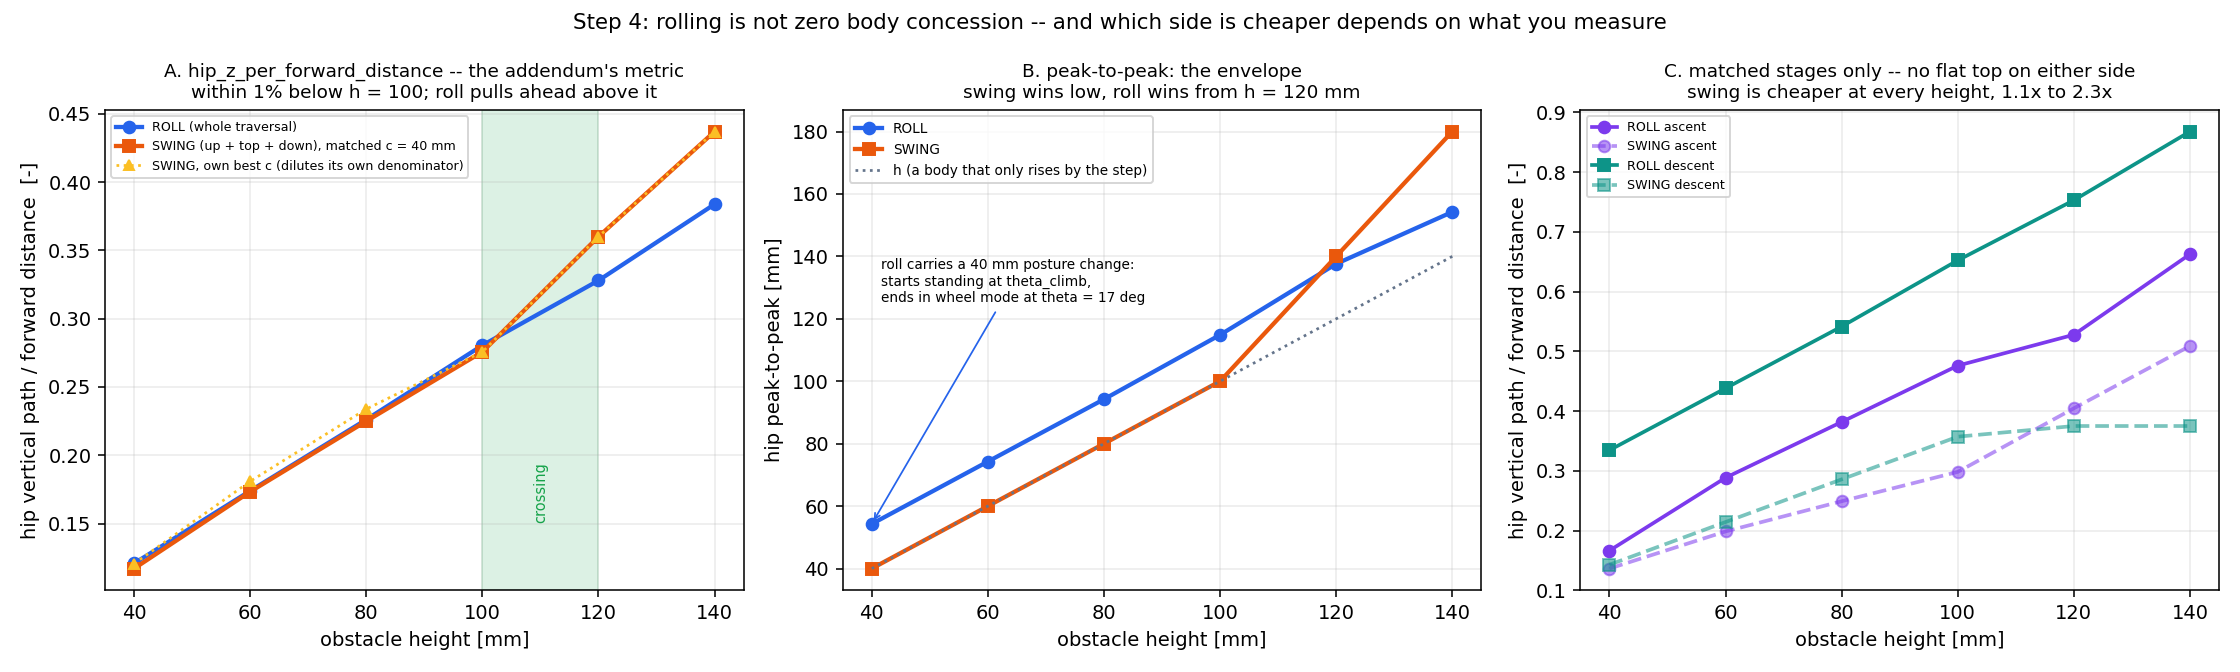

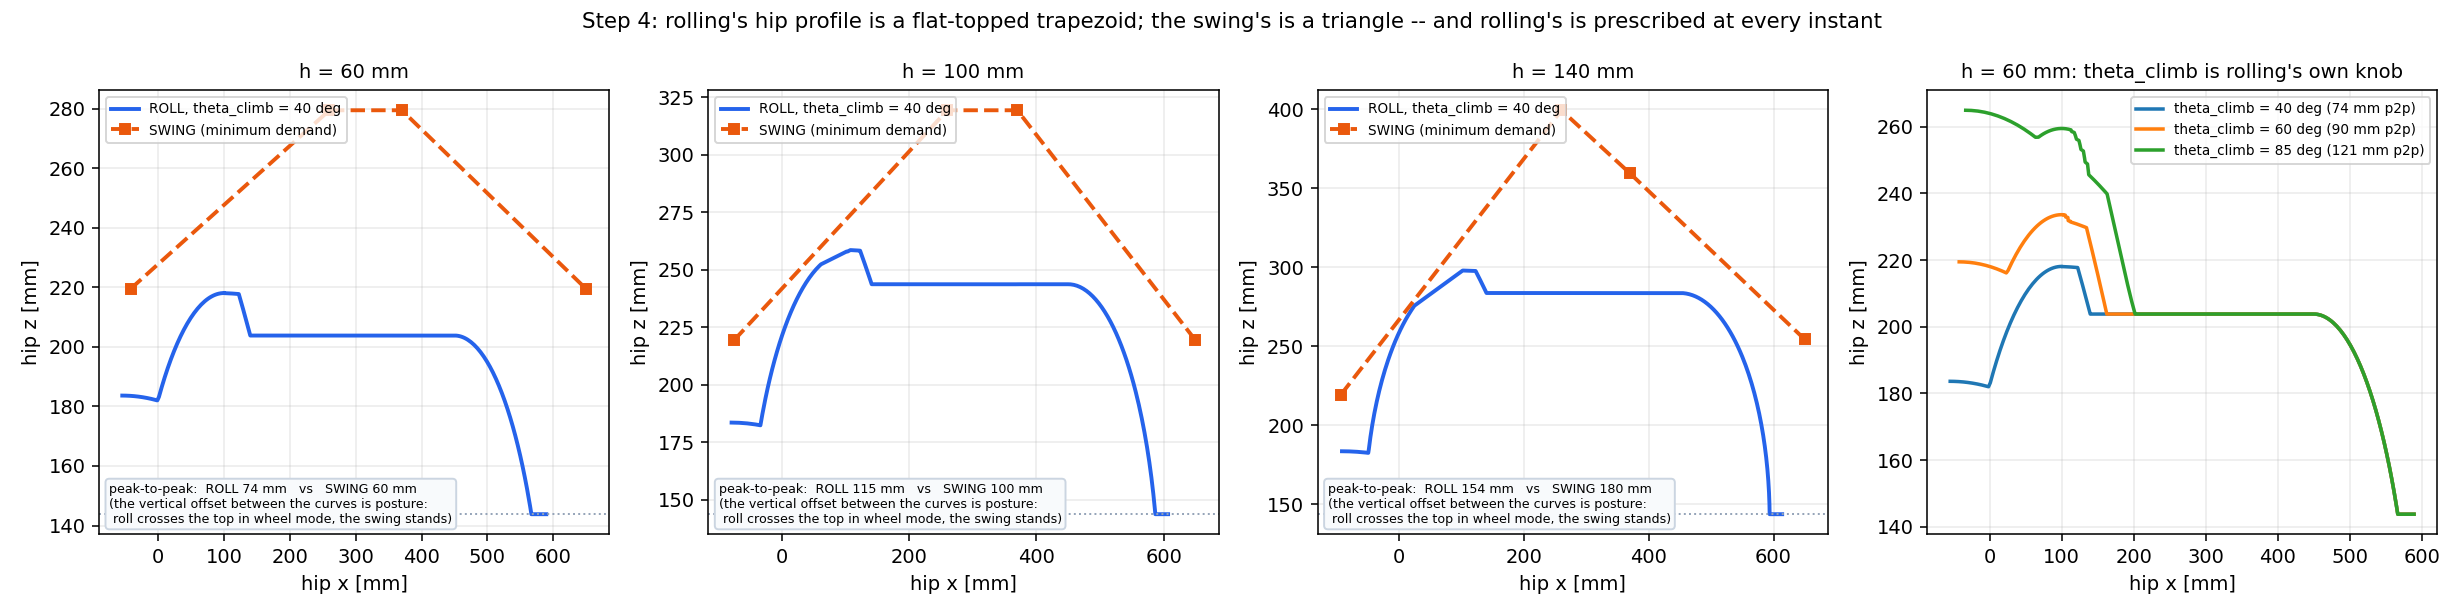

In [53]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step4_hip_excursion_roll_vs_swing.png')))
_display(Image(filename=str(day10_11_dir / 'day10_11_step4_roll_hip_profile.png')))

### 讀圖：梯形 vs 三角形

第二張圖是這一步最有用的一張。兩種 body 要求的**形狀**不一樣：

```text
ROLL   梯形 —— 爬升、【平頂】、下降。平頂就是 wheel mode 走過頂面那段。
SWING  三角形 —— 直線上到一個尖峰，再直線下來。
       （因為 HipTrajectory2D 目前就是一條直線 —— 這正是 Step 2b 抱怨的那個限制）
```

兩條曲線的**絕對高度差是姿態**（roll 用 wheel mode 過頂、swing 站著過頂），
不是起伏差；比較的數字（peak-to-peak）標在每張圖左下角。

最右邊那張：`theta_climb` 越大，hip 起始越高，而且爬升時反而**先下降**——
85 deg 的腿已經很伸展，滾上 rim 只會讓 hip 掉下來。

## 4.8 F 段：規格 §5.3 缺的那條規則

In [54]:
rule = step4_exc[step4_exc.section == 'rule'].set_index('obstacle_mm')
display(rule[['roll_kind', 'roll_peak_to_peak_mm',
              'swing_minimum_demand_mm', 'verdict']].round(2))

,roll_kind,roll_peak_to_peak_mm,swing_minimum_demand_mm,verdict
obstacle_mm,,,,
40.0,track,54.29,40.0,SWING
60.0,track,74.27,60.0,SWING
80.0,track,94.23,80.0,SWING
100.0,track,114.86,100.0,SWING
120.0,track,137.61,140.0,ROLL
140.0,track,154.23,180.0,ROLL


### 規則本身

```text
一個 LOWER_BOUND 是【一族】body 軌跡，而那一族裡最便宜的成員，
其垂直起伏【恰好等於】那個下界。

=> 所以兩者在【各自的最小值】上是可比的：
   rolling 的起伏是被規定死的、因此已經是最小；
   swing 的最小值就是它的下界。兩邊都在回答
   「這個 primitive 最少能向 body 要求多少」。
```

**大小沒有捕捉到、而呼叫端不能忘記的事**：rolling 還額外規定了**形狀**
（每一個瞬間都被決定），swing 只規定一個極值。那份自由是真的、而且這裡沒有計價。

```text
=> 所以【大小打平時算 swing 贏】。
   compare_body_demand_2d 的回傳值就是這樣寫的。
```

這條規則不依賴 clearance（它沒有分母），所以 §4.3 那個稀釋問題影響不到它。

## 4.9 Step 4 結論：story 成立，但要加限定詞

```text
[原完成標準]
(1) 成立   42/70 個可行 cell 全部有 RollConcession2D，theta 已取最佳
(2) 成立   §5.3 的問題有答案了，而且有規則（§4.8）

[質心 story 的追加標準]
(3) 成立   四個代理量兩側都算過（peak-to-peak / RMS / per-forward / vertical work）
(4) 成立   roll 是否真的低於 swing：【在 h >= 120 mm 成立，h <= 100 mm 不成立】
(5) 成立   交叉點有圖，且三個獨立指標一致地放在 h = 100-120 mm
```

**paper §25.1 的 story 要改寫成有限定詞的版本：**

```text
不能寫：「hybrid 滾走的質心變化比 walking 小」
可以寫：「在 h >= 120 mm 時，滾走的 hip 起伏比 swing 少 9-12%；
        在 h <= 100 mm 兩者在 1-3% 內打平（swing 略優）。
        交叉點由【swing 的 hip lift 何時開始長】決定 ——
        lift 在 h <= 100 mm 是 0，之後跳成 20 / 40 mm，
        而 rolling 的 overhead 是常數 14.2 mm。」
```

**這比原本的 story 更有力，不是更弱**：它有機制、有交叉點、有數字，
而且交叉點的位置是可以預測的（lift 開始長的地方）。

**另外三件會直接進 Step 5 的事：**

```text
1. rolling 的 body 要求形狀是【梯形】，swing 是【三角形】。
   平頂那段是 rolling 免費賺前進距離的地方 —— 也是 C 段和 D 段結論相反的原因。

2. theta_climb 是取捨不是最佳化：低 theta 省 34-47 mm 起伏，但要多 64.4 mm 頂面。
   Step 5 只按 body 代價選 theta 會選到放不進去的姿態。

3. L_top 決定 body 代價的分界線，不只決定可行性。
   V_roll < V_swing 在每個高度都成立 -> 頂面夠長時 roll 一律贏，
   交叉點 L* = 0.386 - 0.666 m（h <= 100）。
```

---

# Step 5 — 疊圖與 decision rule

## 5.1 Step 5 要交出什麼

規格要的是一個**純函式**：

```text
decide_2d(h, L_top) -> (ascent, descent) + 內部參數 + BodyRequirement
```

以及 paper 的 **Figure D**：terrain geometry → motion class。

候選在前面幾步已經從五個降到三個（#2 被 Step 3 推翻、#3 被 Step 2b 推翻），
但**還缺一塊資料**：`#5 SWING_OVER` **從來沒有任何一步量過它**。
Step 1 的 showcase 只有 `onto` / `off`，Step 2/3 掃的是落腳的兩半。
完成標準寫「五個候選都有 concession 數值」，所以 Step 5 必須先把它補起來。

## 5.2 A 段：SWING_OVER 的第一次量測

**它的內部自由度是 θ，而且是被逼出來的，不是選的。**

apex 在障礙頂面上方 `clearance` 處，所以飛行中段腳大約在地面上方 `h + 30 mm`，
而髖在站姿高度。腿要跨過這個落差，而它**最短**的伸展是 `θ = 17°`——一個輪半徑，143.8 mm。

實測探針：`h = 60 mm、θ = 60°` 時 apex 處腳在髖下方 130 mm，`IK_NOT_CONVERGED`，
原因就是 130 < 143.8。

`HipTrajectory2D` 是直線，沒有任何旋鈕能讓髖在**中段**拱起（Step 2b 撞的同一道牆）。
唯一能把髖抬過障礙的方法是**兩端同時抬**，而一致的做法就是更伸展的站姿。

In [55]:
over = pd.read_csv(day10_11_dir / 'day10_11_step5_swing_over.csv')
print(f'{int(over.feasible.sum())} / {len(over)} 可行')
print()
print('可行性 by (h, L_top) —— 每個高度都是嚴格的【前綴】：')
grid = over.pivot_table(index='obstacle_mm', columns='top_length_m',
                        values='feasible', aggfunc='first')
display(grid.replace({True: 'o', False: '.'}))
print()
print('選到的 theta（可行格）：')
display(over[over.feasible].pivot_table(index='obstacle_mm', columns='top_length_m',
                                        values='theta_deg', aggfunc='first'))

33 / 80 可行

可行性 by (h, L_top) —— 每個高度都是嚴格的【前綴】：


top_length_m,0.02,0.05,0.08,0.11,0.14,0.17,0.20,0.24,0.28,0.35
obstacle_mm,,,,,,,,,,
20.0,o,o,o,o,o,o,o,o,o,o
40.0,o,o,o,o,o,o,o,o,o,.
60.0,o,o,o,o,o,o,o,o,.,.
80.0,o,o,o,o,o,o,.,.,.,.
100.0,.,.,.,.,.,.,.,.,.,.
120.0,.,.,.,.,.,.,.,.,.,.
140.0,.,.,.,.,.,.,.,.,.,.
160.0,.,.,.,.,.,.,.,.,.,.



選到的 theta（可行格）：


top_length_m,0.02,0.05,0.08,0.11,0.14,0.17,0.20,0.24,0.28,0.35
obstacle_mm,,,,,,,,,,
20.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,60.0
40.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,70.0,NaN
60.0,70.0,70.0,70.0,70.0,70.0,70.0,70.0,80.0,NaN,NaN
80.0,80.0,80.0,80.0,80.0,80.0,80.0,NaN,NaN,NaN,NaN


### 讀表：一個高度天花板、一個寬度天花板，而且天花板可以預測

```text
h <=  80 mm  可行
h >= 100 mm  全滅，失敗模式【100% IK_NOT_CONVERGED】
```

天花板的閉式預測：

```text
h_max = standing_hip(theta_max) - apex_clearance - min_leg_length
      = 264.9 - 30 - 143.8
      = 91.1 mm          <- 實測天花板落在 80 與 100 mm 之間，一致
```

**寬度天花板隨高度收縮**（350 → 280 → 240 → 170 mm），而 θ 隨高度上升（50 → 60 → 70 → 80）。
stride 需求 281–734 mm。

> **可行集在每個高度都是嚴格的前綴**（h=20 全過、h=40 前 9、h=60 前 8、h=80 前 6）。
> 這不是巧合：同一個高度下，較短的頂面就是較短的 stride，嚴格比較容易。
> 所以決策函式可以在未掃到的 `L_top` 上做**單調閉包**——沒有它，
> Figure D 上的 #5 會變成十個孤立的點，看起來像散亂的結果而不是一個 region。

## 5.3 決策規則的骨架：`L_top` 決定策略，也決定 rolling 的 `theta_climb`

這是 Step 5 真正的機制，而且它是把 Day 6–7 和 Step 4 兩邊的量測**接起來**才浮現的。

In [56]:
from hybrid_note.scripts.experiments.day10_11_decision_map_2d import (
    load_tables_2d, decide_2d, StrategyId)

tables = load_tables_2d(day10_11_dir, day6_7_dir,
                        swing_over_csv=day10_11_dir / 'day10_11_step5_swing_over.csv')
req = tables.required_top_length_for_theta()

roll_cells = pd.read_csv(day10_11_dir / 'day10_11_step4_roll_concession.csv')
roll_cells = roll_cells[(roll_cells.section == 'cell') & roll_cells.feasible]
overhead = (roll_cells.hip_z_peak_to_peak_mm - roll_cells.obstacle_mm)

display(pd.DataFrame({
    '需要的頂面長度 [mm]': {k: v * 1e3 for k, v in req.items()},
    'hip 起伏 overhead [mm]': overhead.groupby(roll_cells.theta_climb_deg).mean(),
}).round(1).rename_axis('theta_climb [deg]'))

,需要的頂面長度 [mm],hip 起伏 overhead [mm]
theta_climb [deg],,
40.0,269.4,14.4
45.0,260.6,17.7
50.0,251.8,21.4
55.0,243.0,25.0
60.0,237.2,28.8
65.0,228.4,35.9
70.0,222.5,39.8
75.0,216.7,42.4
80.0,210.8,48.1


### 讀表：同一個旋鈕，兩個方向相反的代價

```text
theta 40 -> 85 deg
    需要的頂面長度   269.4 -> 205.0 mm   （下降 64.4 mm）
    hip 起伏 overhead 14.2 ->  49.4 mm   （上升 35.2 mm）
```

`required_top_length` 是 Day 6–7 Step 12R 量的，而且它**只由 θ 決定**——
70 個 cell 跨高度的離散在 10 個 θ 裡有 8 個小於 3 μm。
`overhead` 是 Step 4 量的，`hip_z_travel = h + overhead(theta)`。

**兩者方向相反，而 `L_top` 就是解開它們的那個變數：**

```text
最便宜的 rolling 計畫 = 「required_top_length 還放得下」的【最小】 theta
```

不需要搜尋——最佳解永遠在約束邊界上。
所以 **rolling 的代價是 `L_top` 的階梯，不是常數**。

## 5.4 B / C 段：Figure D

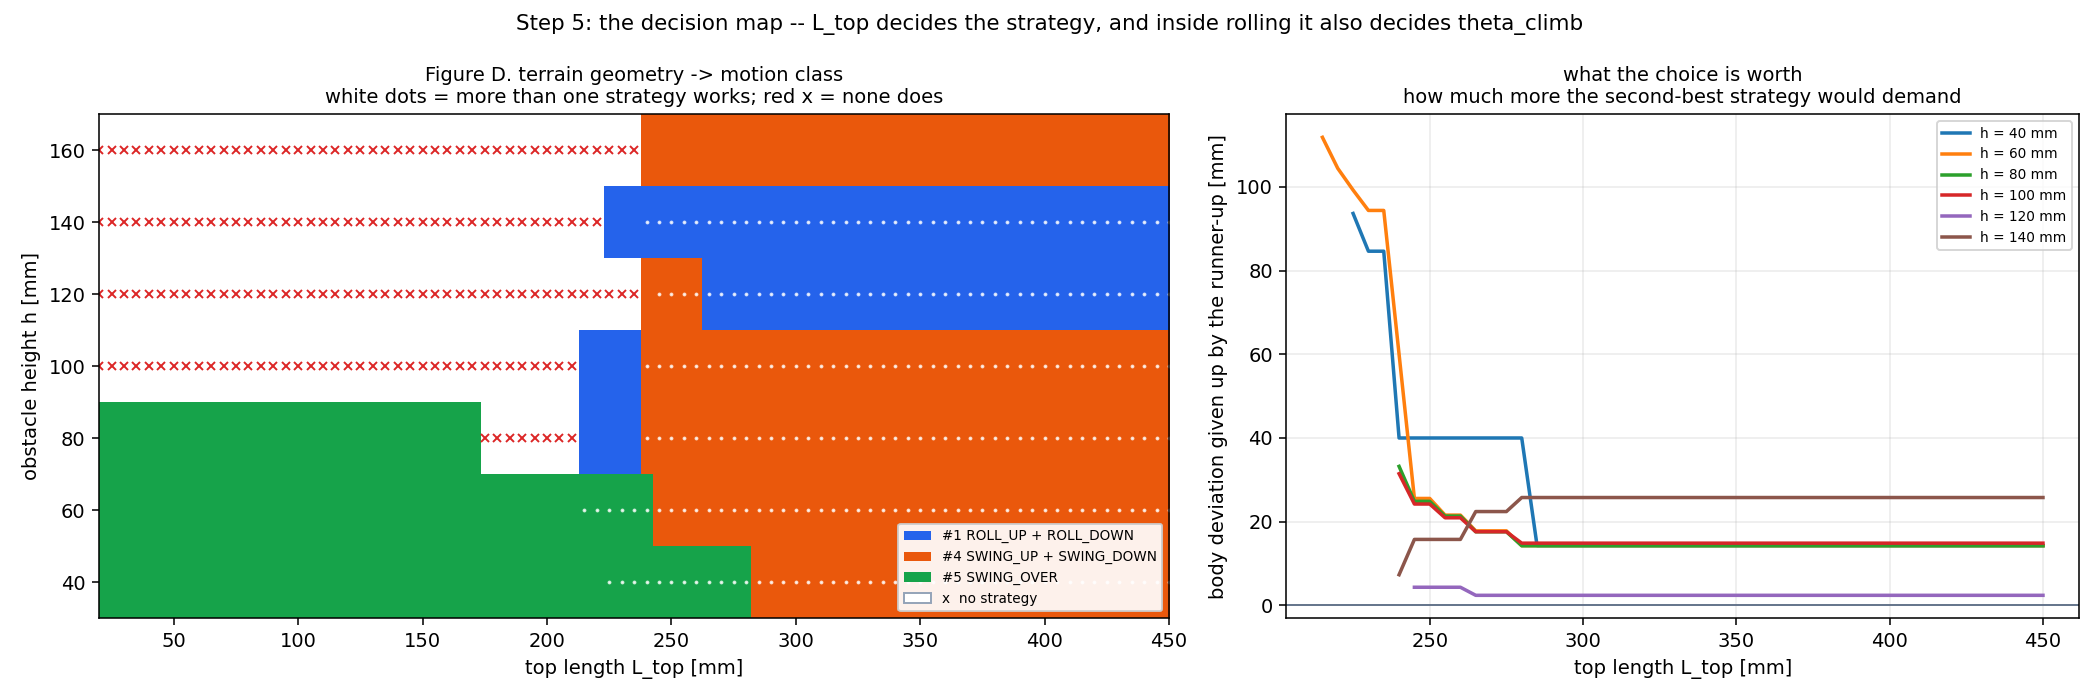

609 格 = 7 個高度 x 87 個頂面長度

勝出策略的分佈：


,cells
winner,
#4 SWING_UP + SWING_DOWN,210
（無解）,176
#5 SWING_OVER,129
#1 ROLL_UP + ROLL_DOWN,94



每格有幾個可用策略：


,cells
feasible_count,
0.0,176
1.0,168
2.0,255
3.0,10


In [57]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step5_figure_d.png')))

dm = pd.read_csv(day10_11_dir / 'day10_11_step5_decision_map.csv')
dec = dm[dm.section == 'decision']
print(f'{len(dec)} 格 = 7 個高度 x 87 個頂面長度')
print()
print('勝出策略的分佈：')
display(dec.winner.fillna('（無解）').value_counts().to_frame('cells'))
print()
print('每格有幾個可用策略：')
display(dec.feasible_count.value_counts().sort_index().to_frame('cells'))

### 讀圖：三個 region，加上一個【洞】

```text
綠 #5 SWING_OVER    左下角：矮障礙 + 短頂面
藍 #1 ROLL + ROLL   一條窄帶，L_top 約 205-265 mm
橙 #4 SWING + SWING 右邊一大片
紅 x                【沒有任何策略可用】
```

**那個洞是一個真實的能力缺口，不是資料缺口**：

```text
h >= 100 mm 且 L_top < 205-235 mm  -> 172 / 609 格【完全過不去】
```

三邊都被擋住，而且理由各不相同：
`#5` 搆不到（h > 91 mm）、`#1` 付不起 `L_transition`（>= 205 mm）、
`#4` 塞不下落點加起跳點（>= 240 mm）。

**257 格有兩個選項、10 格有三個**——這是規格說「最有說服力的一塊」的區域，
右圖畫的就是在那裡選錯策略要多付多少 body 讓步。

## 5.5 D 段：`L_top` 切片

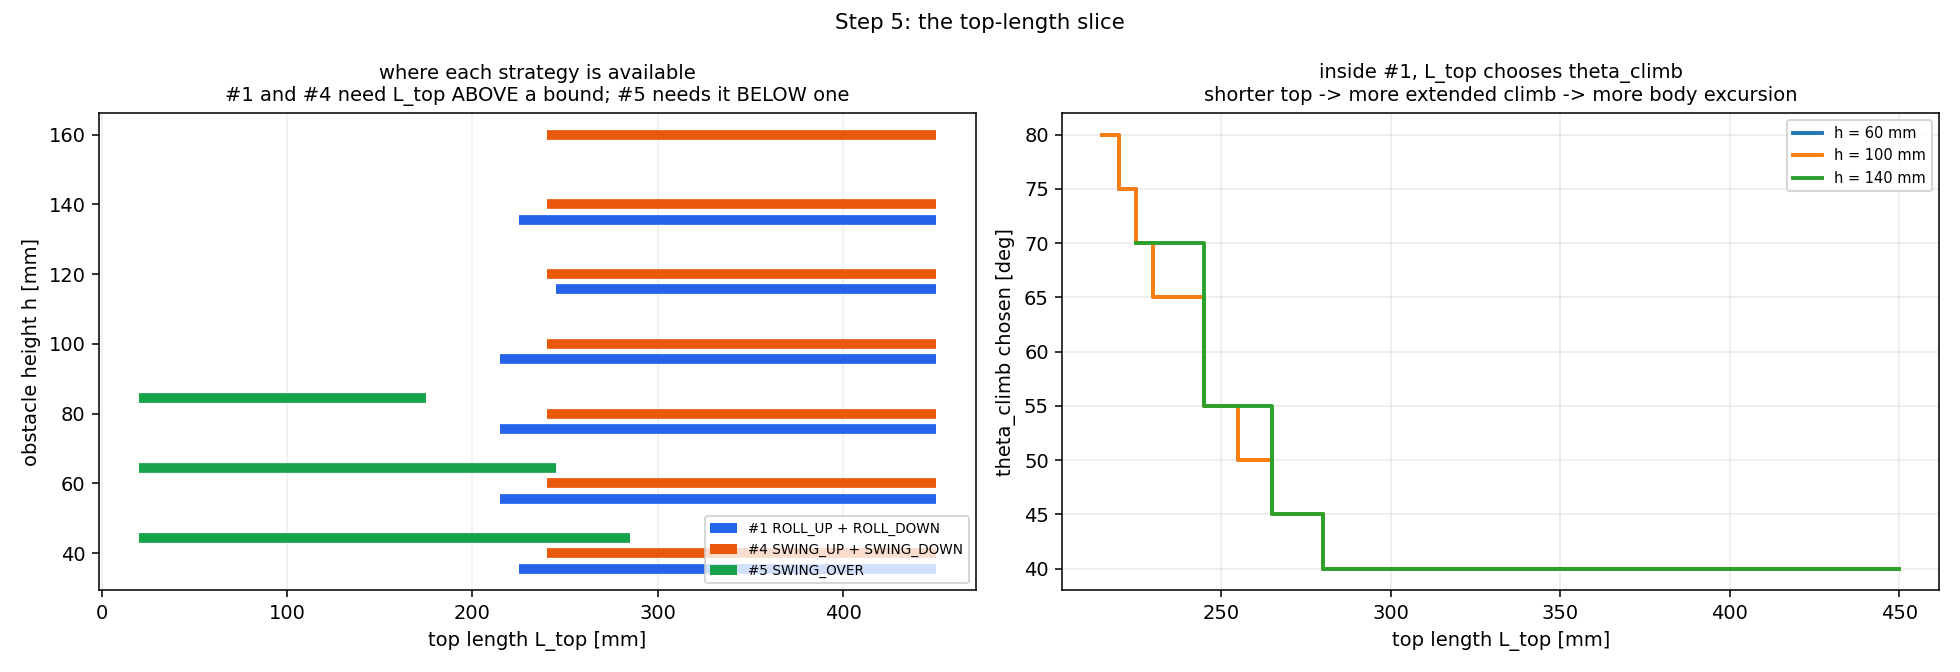

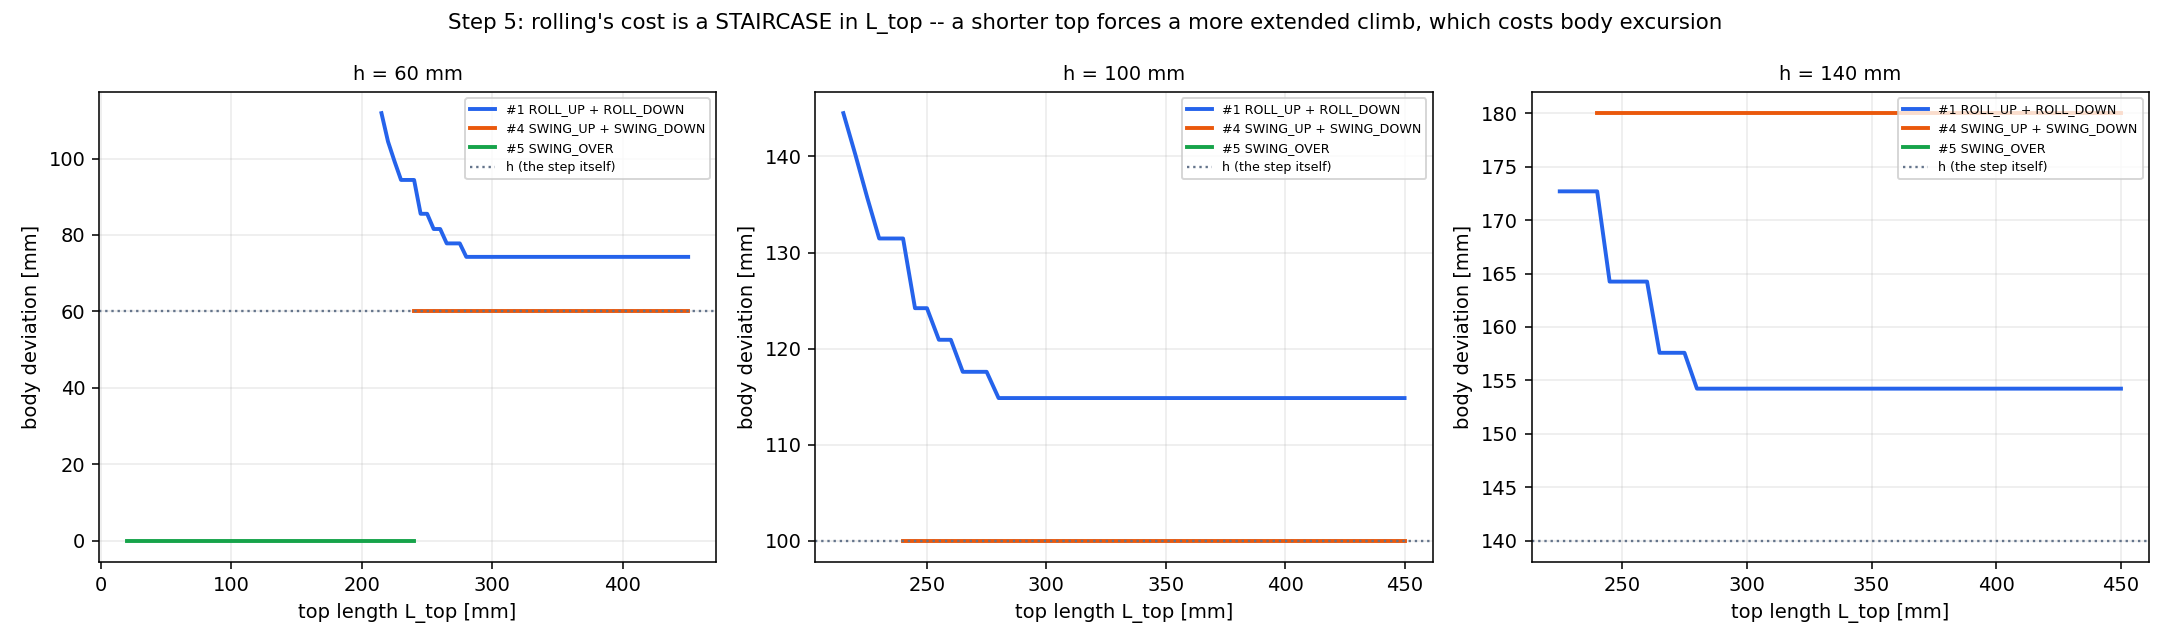

In [58]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step5_top_length_slice.png')))
_display(Image(filename=str(day10_11_dir / 'day10_11_step5_cost_gap.png')))

### 讀圖：頂面變短時，策略確實往 swing 移動——但不是規格猜的那條路徑

```text
h =  40 mm   #5@20 -> #4@285
h =  60 mm   #5@20 -> #4@245
h =  80 mm   #5@20 -> 無解@175 -> #1@205 -> #4@240
h = 100 mm   #1@205 -> #4@240
h = 120 mm   #4@240 -> #1@265
h = 140 mm   #1@225
h = 160 mm   #4@240
```

右邊那張圖是**機制**：`theta_climb` 隨 `L_top` 縮短而階梯式上升
（40 → 45 → 50 → 55 → 60 → 65 → 70 → 75 → 80 → 85），
每一階都讓 rolling 的 body 代價往上跳。

`h = 120 mm` 那一列最能說明問題：`L_top = 240-260` 時 `#4` 贏，
`L_top >= 265` 時 `#1` 贏。**不是因為 `#1` 在 240 不可行**，
而是因為那裡只有 `θ = 55°` 放得下（144.2 mm），輸給 `#4` 的 140 mm；
到 265 時 `θ = 45°` 放得下（137.6 mm），就反超了。
**策略切換是被 `theta` 階梯推動的。**

## 5.6 E 段：lexicographic 順序的敏感度（規格的最後一條完成標準）

In [59]:
sens = dm[dm.section == 'order_sensitivity']
print('換順序會不會移動 region 邊界：')
for label in sens.order.unique():
    sub = sens[sens.order == label]
    changed = 0 if (sub.baseline_winner == 'unchanged').any() else len(sub)
    print(f'  {label:34s} {changed:4d} / 609 格改變')
print()
print('margin 門檻（規格 6.2），預設【刻意關掉】：')
display(dm[dm.section == 'margin_sensitivity'][['order', 'baseline_winner']]
        .set_index('order'))
print()
print(f"靠 tie-break 決定的格數：{int(dec.decided_by_tie_break.sum())}")

換順序會不會移動 region 邊界：
  default (body -> margin -> roll)      0 / 609 格改變


  margin before body                  200 / 609 格改變
  roll preference before body         184 / 609 格改變

margin 門檻（規格 6.2），預設【刻意關掉】：


,baseline_winner
order,
margin floor 0.0 mm,58 cells change
margin floor 0.5 mm,58 cells change
margin floor 1.0 mm,58 cells change



靠 tie-break 決定的格數：0


### 讀表：順序**很重要**，而且 margin 門檻預設是關的

```text
default（body -> margin -> roll）    基準
margin 放在 body 前面                208 / 609 格改變
roll 偏好放在 body 前面              186 / 609 格改變
```

**這不是穩健性的好消息，是一個必須寫下來的限制。** 三分之一的格子會因為
判準順序而換策略。規格第一版選 lexicographic「不調權重」是對的
（邊界由數據而非旋鈕決定），但**這個選擇本身就是一個決定**。

**靠 tie-break 決定的格數是 0**——在預設順序下，body 代價永遠分得開前兩名。
所以「平手時偏好 roll 較多的那個」這條規則在目前的資料上**從未被觸發**。

> **一個踩到才發現的坑。** margin 門檻原本預設在 `0.0`，結果在 h = 60 / 80 mm
> 開出一條假的「無解」帶。原因：三個 sweep 都有少數可行計畫的最小餘裕是
> **1e-4 到 1e-3 mm** 量級——swing 最緊的一點通常就是**觸地**，那裡餘裕依定義為零。
> 這些數字比 planner 自己的 `collision_tolerance_m = 1 mm` 細一千倍，
> 用 0.0 當門檻等於**用比模型自身容差銳利 1000 倍的標準去推翻模型的判定**。
> 現在預設是「信任 planner 已經判過了」，門檻做成敏感度：任何 >= 0 的門檻都會改變 58 格。

## 5.7 F 段：規格 §2.7 的單調性claim —— **被推翻**

In [60]:
mono = dm[dm.section == 'monotonicity'][
    ['obstacle_mm', 'roll_roll_min_top_m', 'swing_swing_min_top_m',
     'swing_over_min_top_m', 'swing_over_max_top_m']].set_index('obstacle_mm')
display((mono * 1e3).round(0).rename(columns=lambda c: c.replace('_m', ' [mm]')))
print()
print('landing distance 的敏感度（Step 2 close-out 掃過這一軸）：')
land = dm[dm.section == 'landing_sensitivity'][
    ['obstacle_mm', 'swing_swing_min_top_as_swept_m',
     'swing_swing_min_top_closeout_m']].set_index('obstacle_mm')
display((land * 1e3).round(0))

,roll_roll [mm]in_top [mm],swing_swing [mm]in_top [mm],swing_over [mm]in_top [mm],swing_over [mm]ax_top [mm]
obstacle_mm,,,,
40.0,225.0,240.0,20.0,280.0
60.0,215.0,240.0,20.0,240.0
80.0,215.0,240.0,20.0,170.0
100.0,215.0,240.0,NaN,NaN
120.0,245.0,240.0,NaN,NaN
140.0,225.0,240.0,NaN,NaN
160.0,NaN,240.0,NaN,NaN



landing distance 的敏感度（Step 2 close-out 掃過這一軸）：


,swing_swing_min_top_as_swept_m,swing_swing_min_top_closeout_m
obstacle_mm,,
40.0,240.0,180.0
60.0,240.0,180.0
80.0,240.0,180.0
100.0,240.0,180.0
120.0,240.0,180.0
140.0,240.0,180.0
160.0,240.0,180.0


### 讀表：「越靠 swing、需要的 top 越短」照量到的數字**不成立**

```text
#1 ROLL + ROLL     需要 L_top >= 205 - 245 mm
#4 SWING + SWING   需要 L_top >= 240 mm        <- 【比 #1 還長】
#5 SWING_OVER      需要 L_top <= 170 - 280 mm  <- 唯一反向的
```

**`#4` 只在 6 個高度中的 1 個比 `#1` 需要更短的頂面。** §2.7 那句話**不成立**。

**但它的真假取決於一個 Step 2 主 sweep 凍結掉的軸。** `#4` 的下界是
`landing_distance + 最短 takeoff = 160 + 80 = 240 mm`，而 `landing_distance = 160 mm`
是 Step 2 格點的固定值。Step 2 的 **close-out 掃過這一軸**（100–220 mm），
發現 **100 mm 在 h = 100 / 150 / 200 都可行且 lift 完全不變**。改用 100 mm：

```text
#4 需要 L_top >= 180 mm   <- 現在【每個高度】都比 #1 短，claim 成立
```

> **所以誠實的結論是：這句話的真假由一個沒有被最佳化的參數決定。**
> 照 Step 2 主格點量到的數字，它是錯的；把 landing 移到 close-out 驗證過的最近位置，
> 它是對的。**兩者都寫下來**，並標明 close-out 只在三個高度驗證過。
>
> `#5` 那一列則是**無條件成立**的：它是唯一一個 `L_top` 越大越不利的策略，
> 而且它在 20 mm 的頂面上仍然可行。

## 5.8 Step 5 結論

```text
[完成標準]
(1) 成立   三個活著的候選都有 concession 數值；不可行的都有理由與 limiter
           （ascent / descent / top length / stride / refuted / no data）
(2) 待做   每個 region 至少一格能生出軌跡 —— 這是 Step 7 的驗證，尚未做
(3) 成立   decide_2d(h, L_top) 是純函式：不跑 planner、不碰檔案系統
(4) 成立   §2.7 的單調性【被推翻】，並記錄了它成立所需的條件
(5) 成立   lexicographic 順序的敏感度已量：換順序會改變約 1/3 的格子
```

**這一步最重要的三個結果：**

```text
1. L_top 不只選策略，還在 #1 內部選 theta_climb。
   required_top_length(theta) 單調下降、hip 起伏 overhead(theta) 單調上升，
   所以最佳解永遠在約束邊界：「還放得下的最小 theta」。
   => rolling 的代價是 L_top 的【階梯】。h = 120 mm 的策略切換就是被這個階梯推動的。

2. 能力圖上有一個【洞】：h >= 100 mm 且 L_top < 205-235 mm，172/609 格全部過不去。
   三個策略各自被不同的理由擋住 —— #5 搆不到、#1 付不起 L_transition、#4 塞不下。
   這是一個 negative result，但它指出了 Day 12 之後最值得攻的方向。

3. SWING_OVER 的 body 起伏是【零】，所以它在可行的地方一律勝出。
   代價改成付在【站姿高度】與【stride】。站姿代價刻意【沒有】折進比較 ——
   它是否已經付掉，取決於障礙之間的步態，那是 Day 15-16 的問題。
```

**兩個必須跟著結果一起講的限制：**

```text
A. decision rule 對 lexicographic 順序敏感（約 1/3 的格子）。
   第一版不調權重是對的，但「順序」本身就是一個未被論證的選擇。

B. §2.7 單調性的真假，取決於 Step 2 凍結的 landing_distance。
   照主格點是錯的，照 close-out 驗證過的 100 mm 是對的。
```

> **用語（見本 notebook 開頭的前提）**：這裡的「推翻 / 不可行」是 `DIRECT_HANDOFF_INFEASIBLE`
> ——**目前的單腿連續接觸 primitive 無法直接交接**。它**不是** `PHYSICALLY_INFEASIBLE`；
> 在四腳支撐下的 `TOP_REPOSITION` 之後可能成立，只是**尚未驗證**。

---

# Step 6 — Segment 級 sequence schema

## 6.1 Step 6 要修的是什麼

規格 §2.5：原規劃的輸出契約要求
`target contact / rim / alpha / foothold for every transition`，
但有三件事塞不進去：

```text
1. wheel-mode 段【沒有固定接觸點】—— theta = 17 deg 連續滾過去，
   接觸點在 rim 上連續移動，「一個 rim + 一個 alpha」表示不了。
2. swing 段有只有 planner 內部知道的欄位 ——
   liftoff_rise / touchdown_drop / swing_duration / apex clearance。
3. 取樣密度是 case 的一部分，不是自由旋鈕 —— Day 8-9 Step 9 發現
   max_joint_step_rad 是【per-sample】限制，同一條軌跡取樣密一倍就少一半。
```

所以 schema 必須是 **segment 級**，每段帶自己的取樣參數與 body requirement。

**三條完成標準都是「無損表示」**：Day 6–7 Step 10R 的完整 traversal（含 wheel-mode 段）、
Day 8–9 的一條 swing（含三個 shaping 旋鈕），以及一個**證明**「缺任何一個取樣參數
就無法重建軌跡」的測試。

In [61]:
seg6 = pd.read_csv(day10_11_dir / 'day10_11_step6_sequence_segments.csv')
hand6 = pd.read_csv(day10_11_dir / 'day10_11_step6_handoff.csv')
samp6 = pd.read_csv(day10_11_dir / 'day10_11_step6_sampling_evidence.csv')

roll_segs = seg6[seg6.kind != 'SWING_UP']
print(f'Day 6-7 Step 10R -> {len(roll_segs)} 個 segment')
display(roll_segs[['kind', 'phase_label', 'frame_count', 'frames_contiguous',
                   'mode', 'is_static', 'beta_sweep_deg', 'theta_step_deg',
                   'duration_s']].round(2).set_index('phase_label'))

Day 6-7 Step 10R -> 10 個 segment


,kind,frame_count,frames_contiguous,mode,is_static,beta_sweep_deg,theta_step_deg,duration_s
phase_label,,,,,,,,
APPROACH,APPROACH,10,True,surface roll,False,17.84,NaN,NaN
RIGHT_RIM_FRONT_CONTACT,APPROACH,1,True,corner pivot,True,0.00,NaN,NaN
RIGHT_RIM_ROLL_UP,ROLL_UP,42,True,surface roll,False,41.00,NaN,NaN
RIGHT_RIM_TOP,ROLL_UP,10,True,surface roll,False,7.50,NaN,NaN
RETRACT_TO_WHEEL,WHEEL_TRANSITION,42,True,surface roll,False,41.00,-1.0,NaN
WHEEL_MODE_TOP_ROLL,WHEEL_TRANSITION,68,True,surface roll,False,67.00,NaN,NaN
LEFT_RIM_READY,WHEEL_TRANSITION,46,True,surface roll,False,45.00,NaN,NaN
LEFT_RIM_TRAILING_TRANSITION,ROLL_DOWN,6,True,corner pivot,False,5.00,NaN,NaN
LEFT_RIM_ROLL_DOWN,ROLL_DOWN,66,True,corner pivot,False,65.00,NaN,NaN


### 讀表：兩件規格 §5.4 沒有預期到的事

**(1) `alpha_range` 不夠用。**

```text
LEFT_RIM_TRAILING_TRANSITION   6 frames   corner pivot   beta 掃  5.0 deg
LEFT_RIM_ROLL_DOWN            66 frames   corner pivot   beta 掃 65.0 deg
```

這 **72 / 299 幀**裡，`alpha` 釘在 −134.5°、接觸點釘在後緣角
`(450.0, 100.0) mm`，動的**只有 β**。腿不是在滾，是**繞著 rim 上的一個點在轉**。

> 只記 `alpha_range` 的 schema，會把這 72 幀記成**一個靜止姿態**。
> 所以 `RollingContact2D` 另外記 `beta_range`，並用 `RollingMode` 指名是哪一種。

**(2) `duration_s` 全部是 `None`。**

Day 6–7 的 traversal 是**準靜態**的，從來沒有被指定過時間。
這裡**記成缺失而不是編一個數字**——編了就等於在一個真數字該去的位置放假數字。
Step 7 或 Day 12 必須補上。

**另外兩個小的：**

```text
- frame index 11 不存在（traversal 提出後又否決的一幀）
  => FrameRef2D 用【明確的 index 列表】而不是 (start, stop) 區間，
     否則區間會默默把它算進去。
- RIGHT_RIM_FRONT_CONTACT 只有 1 幀（輪子剛碰到前緣的那一瞬間）
  => hip_z profile 允許單點。逼它併進鄰段，就是這一步要避免的那種「損失」。
```

## 6.2 無損嗎？

In [62]:
import csv
from hybrid_note.scripts.experiments.day10_11_sequence_builders_2d import (
    sequence_from_traversal_frames_2d, coverage_report_2d, handoff_report_2d)

with (day6_7_dir / 'day6_7_step10r_full_traversal_frames.csv').open() as fh:
    frames10r = list(csv.DictReader(fh))
seq10r = sequence_from_traversal_frames_2d(
    frames10r, terrain_id='day6_7_obstacle',
    source_id='day6_7_step10r_full_traversal_frames.csv', arc_samples=241)

display(pd.DataFrame([coverage_report_2d(seq10r, frames10r).as_dict()]).T
        .rename(columns={0: 'Step 10R 往返'}))
print()
print('交接：接觸點可以跳，關節不行')
display(hand6[['to', 'rim_changed', 'contact_jump_mm', 'alpha_jump_deg',
               'theta_jump_deg', 'beta_jump_deg']].round(2).set_index('to'))

,Step 10R 往返
source_frames,299
covered_frames,299
missing,0
duplicated,0
rejected_and_skipped,0
lossless,True



交接：接觸點可以跳，關節不行


,rim_changed,contact_jump_mm,alpha_jump_deg,theta_jump_deg,beta_jump_deg
to,,,,,
APPROACH/RIGHT_RIM_FRONT_CONTACT,False,4.22,1.67,0.0,-1.75
ROLL_UP/RIGHT_RIM_ROLL_UP,True,180.47,78.67,0.0,-1.00
ROLL_UP/RIGHT_RIM_TOP,False,1.46,0.58,0.0,-0.50
WHEEL_TRANSITION/RETRACT_TO_WHEEL,False,1.46,0.58,-1.0,-1.00
WHEEL_TRANSITION/WHEEL_MODE_TOP_ROLL,False,0.00,0.00,-1.0,-1.00
WHEEL_TRANSITION/LEFT_RIM_READY,True,2.93,1.17,0.0,-1.00
ROLL_DOWN/LEFT_RIM_TRAILING_TRANSITION,False,3.04,0.00,0.0,-1.00
ROLL_DOWN/LEFT_RIM_ROLL_DOWN,False,0.00,0.00,0.0,-1.00
ROLL_DOWN/LOWER_GROUND_CONTACT,False,169.72,72.33,0.0,-0.17


### 讀表：接觸點跳 180 mm，關節跳不到 2 度

```text
最大接觸點跳躍   180.5 mm   （foot rim -> right rim，站在地上換成頂到前緣）
最大 theta 跳躍    1.00 deg
最大 beta  跳躍    1.75 deg
```

**接觸點大跳不是 bug**：換 rim 就是把接觸換到輪子的另一個部位。
真正會是不連續的是**關節**，而它們全都在一個取樣步長以內。

**±180° 接縫那一格特別值得看：**

```text
WHEEL_MODE_TOP_ROLL -> LEFT_RIM_READY
    alpha  179.4 -> -179.4      未折疊時看起來跳了 358.8 度
    接觸點                       只移動 2.9 mm
```

那是**換座標卡**（chart），不是運動。所以 hand-off 報告把 α 差折進 `(-180, 180]`。

> 順帶修正一個容易誤讀的地方：交接檔陷阱 4 說 ±180° 接縫「跳 162 mm」，
> 那是**同一個 rim 參數化下**的跳躍。實際換到另一個 rim 之後，
> 兩者在物理上幾乎重合（2.9 mm）。

## 6.3 一條 swing

In [63]:
swing_row = seg6[seg6.kind == 'SWING_UP'].iloc[0]
print('§2.5 說「沒有任何 contact state 提到」的四個欄位：')
display(swing_row[['liftoff_rise_mm', 'touchdown_drop_mm',
                   'apex_clearance_mm', 'duration_s']].to_frame('值'))
print()
print('讓它可重現的取樣參數：')
display(swing_row[['arc_samples', 'sample_count', 'leg_arc_samples',
                   'max_joint_step_deg']].to_frame('值'))
print()
print(f"body requirement: {swing_row.body_kind}, hip 至少要到 "
      f"{swing_row.hip_z_min_mm:.1f} mm")

§2.5 說「沒有任何 contact state 提到」的四個欄位：


,值
liftoff_rise_mm,30.0
touchdown_drop_mm,0.0
apex_clearance_mm,30.0
duration_s,0.6



讓它可重現的取樣參數：


,值
arc_samples,121
sample_count,31.0
leg_arc_samples,61.0
max_joint_step_deg,10.0



body requirement: lower_bound, hip 至少要到 439.4 mm


### 讀表：落地 theta 是 IK 的【輸出】

這條 swing 的請求是 `theta = 60 deg`，但寫進 schema 的落地姿態是 **`theta = 92.8 deg`**。

```text
hip_z_min = 219.45 (站姿) + 160 (障礙高) + 60 (min_hip_lift) = 439.45 mm
```

`min_hip_lift` 抬的是**落地端的 hip**，而落地接觸點在頂面上——
IK 只能解出一個更伸展的姿態。這就是交接檔陷阱 16 說的
「落地 theta 是輸出不是輸入」，schema 從最後一個 sample 讀它而不是從請求抄。

> **端點一律是 `PointContact2D`，即使是 rolling 段。**
> 規格 §5.4 寫的是 `ContactState | RollingContact`（二選一），
> 但資料說**兩個都要**：Step 7 的交接檢查要比對關節值，需要兩端各有一個確定的姿態；
> 而 §2.5 抱怨的是**兩端【之間】**發生了什麼。
> 所以端點是點接觸，`RollingContact2D` 描述中間那段。

## 6.4 第三條完成標準：證明每個取樣參數都是必要的

這一條不能用「欄位存在」來滿足——規格要的是**證明缺了就重建不出來**。
所以四個參數各自被**演示**成會改變它所描述的軌跡。

In [64]:
display(samp6.set_index('parameter'))

,what_changes,at_low,at_high,ratio
parameter,,,,
arc_samples,what counts as a rim seam,34.73 mm at 61,5.00 mm at 481,6.945541
sample_count,the per-sample joint step the limit is checked...,3.41 deg at 16,1.71 deg at 31,1.993462
leg_arc_samples,the minimum clearance the collision sweep reports,1.67085 mm at 31,1.66949 mm at 241,1.000815
max_joint_step_rad,"the continuity limit -- per SAMPLE, so it is c...",0.20 rad x 16 samples,0.10 rad x 31 samples,1.000000


### 讀表：四個都是承重的

```text
arc_samples          seam bridge 34.73 mm (61) -> 5.00 mm (481)，差 6.9 倍
                     => 沒有它，「這次 rim 交接合不合法」答不出來（Day 6-7 陷阱 2）

sample_count         最大關節步長 3.41 deg (16) -> 1.71 deg (31)
                     => 同一條軌跡，取樣密一倍步長就少一半

leg_arc_samples      最小餘裕 1.67085 mm (31) -> 1.66949 mm (241)
                     => 位移很小，但規格 §6.2 的餘裕本來就是毫米級，
                        而 Step 5 量到 margin 門檻會動 58 格

max_joint_step_rad   是【per-sample】限制，所以 (0.20, 16) 和 (0.10, 31)
                     是【同一個約束】—— 兩個欄位都記才定得下來
```

> `SamplingSpec2D` 因此**沒有任何預設值**：漏掉一個是建構錯誤，不是靜默 fallback。
> 而且**滾動與擺動不共用取樣詞彙**：swing 用 `sample_count` 計時、
> rolling 用 `beta_step`（retract 段另加 `theta_step`）逐步推進到停止條件。
> 一個半數欄位是 `None` 的結構會讓「哪些是必填」變成無法回答的問題，
> 而那正是這條完成標準在測的。所以是**兩個型別，各自對自己的家族是完整的**。

## 6.5 圖

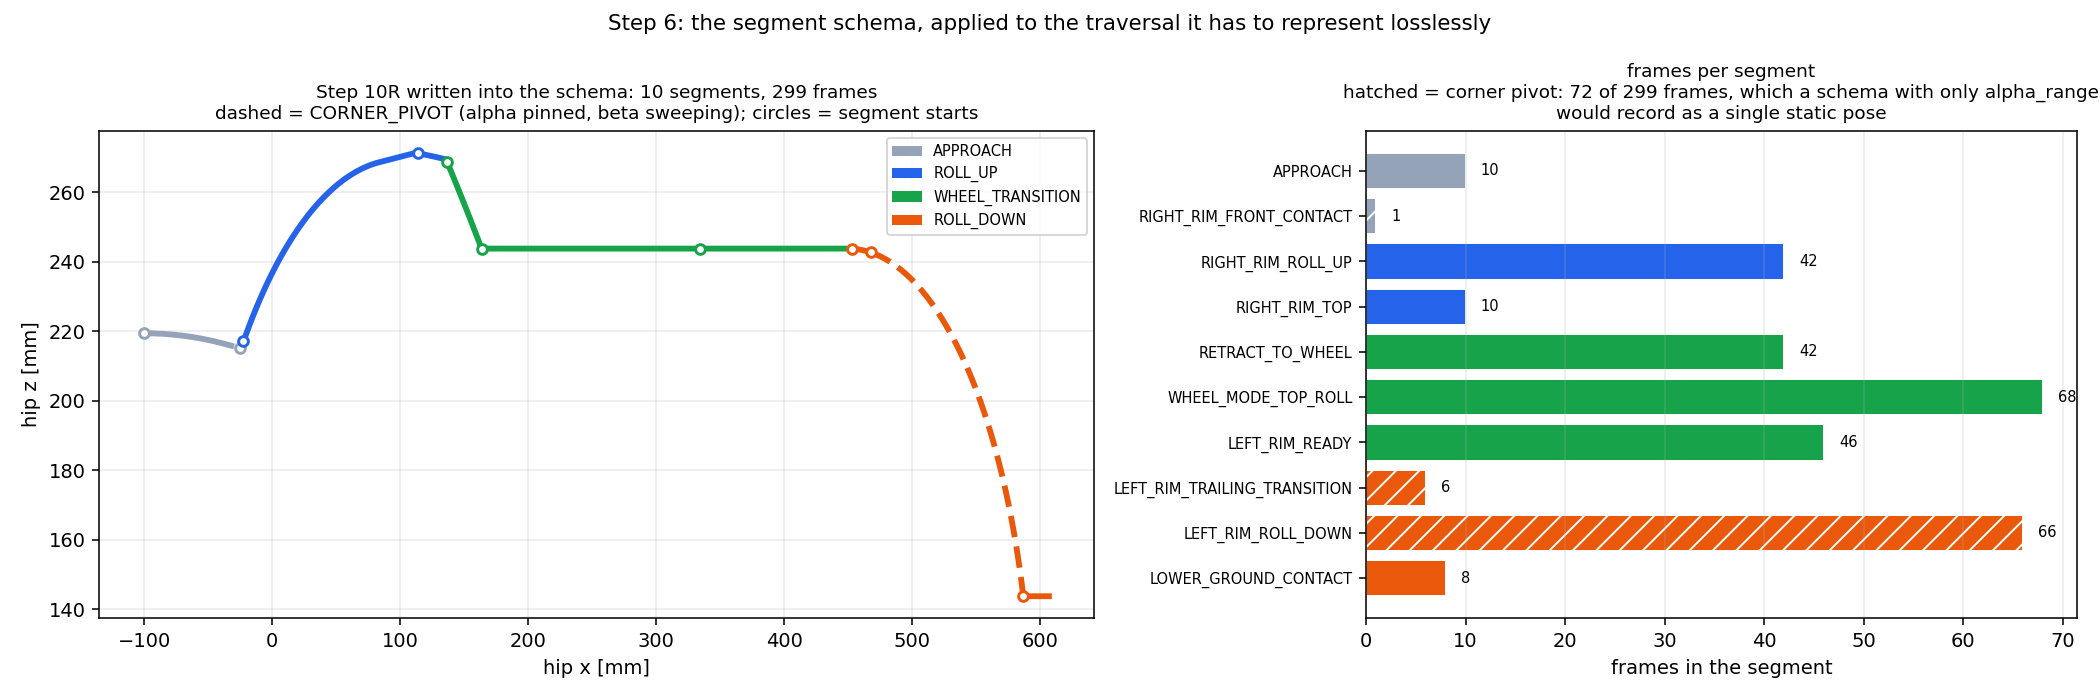

In [65]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step6_sequence_segments.png')))

### 讀圖

左圖是同一條 hip 軌跡，但**按 schema 的方式切開**：顏色是 `SegmentKind`，
虛線是 `CORNER_PIVOT`。可以直接看到那段「hip 一路往下掉、但接觸點完全沒動」的下降。

右圖是每段的幀數。**斜線 = corner pivot，72 / 299 幀**——
只記 `alpha_range` 的 schema 會把這一整塊記成一個靜止姿態。

## 6.6 Step 6 結論

```text
[完成標準]
(1) 成立   Day 6-7 Step 10R 無損：10 段、299/299 幀、無缺漏無重複，wheel-mode 段完整保留
(2) 成立   Day 8-9 的一條 swing 無損：liftoff_rise / touchdown_drop / duration /
           clearance 全部保留，落地姿態從 IK 輸出讀回
(3) 成立   四個取樣參數各自被【演示】成會改變它描述的軌跡，而不是只被斷言存在
```

**四件被資料逼出來、規格 §5.4 沒寫的事：**

```text
1. alpha_range 不夠 —— corner pivot（alpha 與接觸點都釘死、只有 beta 掃）
   佔 72/299 幀。RollingContact2D 因此另記 beta_range 與 RollingMode。

2. rolling 與 swing 不共用取樣詞彙 —— 兩個型別，各自完整，都沒有預設值。

3. 端點一律是 PointContact2D，即使 rolling 段也是。
   §5.4 的二選一不夠：Step 7 要比對關節值，兩端都需要確定的姿態。

4. duration_s 對整條 rolling traversal 是 None ——
   Day 6-7 是準靜態的、從未指定時間。記成缺失而不是編造。
```

**兩個小但會咬人的細節：**

```text
- FrameRef2D 用明確 index 列表：Step 10R 自己的輸出跳過 index 11
  （一幀被提出又否決），(start, stop) 區間會默默把它算進去。
- ±180 度接縫是【換座標卡】不是運動：alpha 未折疊時跳 358.8 度，
  接觸點只移動 2.9 mm。陷阱 4 的「162 mm」是同一 rim 參數化下的值。
```

**schema 已經含 `WHEEL_ROLL` 與 `POST_TOUCHDOWN_ROLL`**（研究計畫 §10.5.4），
即使 Day 10–11 不生成它們——之後再補會要改每一個消費端。

---

# Step 7 — Sequence composer 與交接連續性

## 7.1 規格點名的三對裡，有兩對已經不存在了

Step 7 的任務清單是在 Steps 2b / 3 / 5 之前寫的。它要求串通
`ROLL+ROLL`、`ROLL+SWING`、`SWING+ROLL`——

```text
#2 ROLL_UP  + SWING_DOWN   被 Step 3 D/E 推翻
#3 SWING_UP + ROLL_DOWN    被 Step 2b 推翻
```

所以「串通三對」誠實的讀法是：**串通還活著的三對（#1 / #4 / #5），
並把兩個推翻當成第一級輸出而不是略過**。`compose_2d` 對五個候選都會回答。

**每一條都在 Step 5 的規則實際會選它的那一格組出來**，不是隨便找一格可行的——
一條規則永遠不會選的策略，生得出軌跡也證明不了那條規則。

> **這一步的真正價值不在那三條軌跡，在它抓到的四個錯。**
> Step 7 是第一次拿決策去**實際生軌跡**，而那揭露了前面幾步的三個缺陷。

In [66]:
seq7 = pd.read_csv(day10_11_dir / 'day10_11_step7_pair1_roll_roll_summary.csv')
hand7 = pd.read_csv(day10_11_dir / 'day10_11_step7_handoff_report.csv')
budget7 = pd.read_csv(day10_11_dir / 'day10_11_step7_top_length_budget.csv')
open7 = pd.read_csv(day10_11_dir / 'day10_11_step7_open_items.csv')
refuse7 = pd.read_csv(day10_11_dir / 'day10_11_step7_refusals.csv')

rows = []
for stem in ('pair1_roll_roll', 'pair4_swing_swing', 'pair5_swing_over'):
    s = pd.read_csv(day10_11_dir / f'day10_11_step7_{stem}_summary.csv')
    rows.append(s[s.section == 'summary'].iloc[0])
summary = pd.DataFrame(rows)
display(summary[['strategy', 'obstacle_mm', 'top_length_m', 'composed', 'segments',
                 'frames', 'collision_free', 'min_clearance_mm',
                 'top_length_used_mm']].set_index('strategy').round(3))

,obstacle_mm,top_length_m,composed,segments,frames,collision_free,min_clearance_mm,top_length_used_mm
strategy,,,,,,,,
#1 ROLL_UP + ROLL_DOWN,140.0,0.225,True,10.0,272.0,True,1.834,202.027
#4 SWING_UP + SWING_DOWN,80.0,0.240,True,2.0,62.0,True,1.393,240.000
#5 SWING_OVER,60.0,0.075,True,1.0,31.0,True,1.298,0.000


### 讀表：三條都是完整、collision-free 的

```text
#1 ROLL + ROLL     h=140 L=225 mm   10 段 272 幀   餘裕 1.834 mm   用掉 202.0 mm 頂面
#4 SWING + SWING   h= 80 L=240 mm    2 段  62 幀   餘裕 1.393 mm   用掉 240.0 mm
#5 SWING_OVER      h= 60 L= 75 mm    1 段  31 幀   餘裕 1.298 mm   用掉   0.0 mm
```

`#5` 那一格 **sweep 從來沒掃過**（`#5` 的十個欄位是 20/50/80/…，沒有 75）——
所以組成功就直接了結了 Step 5 留下的第一件驗證：單調閉包成立。

`#4` 那一格 `gap_on_top = 0`：`L_top = landing 160 + takeoff 80`，
兩段 swing 首尾**正好相接**，所以整條沒有未規劃的空隙。
（在更長的頂面上就會有一段誰都還生不出來的「走過頂面」——見 §7.5。）

## 7.2 Step 7 抓到的四個錯

這是這一步最有價值的部分。前三個是**前面幾步的缺陷**，第四個是 Step 7 自己的新量測。

### 錯 1：決策回報的參數**不足以重建它選的動作**

Step 2 / Step 3 是靠 repair ladder 走到可行的：
`liftoff_rise`、`touchdown_drop`、`duration_scale`。
而 `decide_2d` 只回報 body 旋鈕（`min_hip_lift` / `min_hip_hold_fraction`）。

第一版 composer 照著決策重建，**重現了 sweep 早就修掉的 `TERRAIN_COLLISION`**。

```text
#4 在 h = 80 mm 實際需要 ascent_liftoff_rise = 50 mm。
沒帶它，同一格就變成不可行。
```

> 規格 Step 5 的第三條完成標準寫的是
> 「decision rule 是一個純函式：`(h, L_top) -> (ascent, descent) + 【內部參數】+ BodyRequirement`」。
> 這一步證明了那些 repair 旋鈕**就是**內部參數的一部分，不是裝飾。已補進決策輸出。
>
> 注意它們**沒有**被折進 `body_deviation_m`——它們是軌跡整形不是 body 讓步，
> 這正是 Step 3 把 ladder 巢狀順序定成 hold 在最外層的理由。

### 錯 2：`#1` 的頂面下界拿「輸出」當「前提」

`required_top_length_m` 是**一次成功的 traversal 回報的**——那一次消耗了多少頂面，
不是一個可行性前提。

**Day 6–7 Step 12R 自己的 top-length sweep 就試過這件事**（用它自己的設定，
所以這個證據和 Step 7 無關）：

```text
h = 60 mm, theta = 40 deg
    L = 249.4 mm   失敗   LEFT_RIM_HAS_NOT_TAKEN_OVER_AT_CORNER
    L = 259.4 mm   失敗   同上
    L = 269.4 mm   失敗   同上   <- 這正好等於 required_top_length
    L = 279.4 mm   成功
```

所以真實下界在 `(269.4, 279.4]`，而 `required_top_length` 是**樂觀的**。

### 錯 4（先講，因為它改變了錯 2 的處理）：Step 7 自己量了一個直接的括號

我一度把它修成「一律 `required + 10 mm`」。但 10 mm 是 **θ=40 那次 sweep 的格點間距**，
不是量到的差額。Step 7 直接在另一個 θ 上夾了一次：

```text
h = 140 mm, theta = 70 deg     required_top_length = 222.5 mm
    L = 220 mm   失敗   LEFT_RIM_HAS_NOT_TAKEN_OVER_AT_CORNER
    L = 225 mm   成功
=> 真實下界在 (220, 225]，而 222.5 mm 【落在區間內】。
```

**兩個直接量測對「差多少」的答案不一致**，而第二個說一律加 10 mm 會超調。
所以最終規則是：

```text
Step 12R 實測過的 theta（40 / 60 / 85）  -> 用實測最小值 279.4 / 247.2 / 215.0 mm
其餘 7 個 theta                          -> 用 required_top_length，並【標記為未驗證】
```

> **副作用要說清楚**：這讓界線在 theta 上**不再單調**——
> θ=60 的實測 247.2 mm 高於 θ=55 的需求 243.0 mm，儘管更伸展的姿態該要**更短**的頂面。
> 那是兩種來源混用的可見假影（實測值含差額、需求值不含），不是物理反轉。
> **留著讓它可見**，因為抹平它就等於發明那個已被第二個量測否證的邊際值。

### 錯 3：composer 沒有重現 sweep 的取樣設定 —— 而這是前兩次失敗的**真正原因**

```text
ObstacleSpec2D.arc_samples      預設 241   但 Day 6-7 的 sweep 跑的是 121
TraversalConstraints2D
    .max_seam_bridge_m          預設 5 mm  但必須跟 arc_samples 【配對】：
                                seam_bridge_for_sampling_m(121) = 17.5 mm
```

這正是交接檔**陷阱 2**，而我踩了。修好之後 `#1` 在 L=350 **和** L=235 都組得出來。

> **所以我先前那兩次失敗不是界線的證據，是設定 bug。**
> 已經把註解和測試裡引用它們當證據的地方全部改掉——
> 錯 2 現在只引用 Day 6–7 自己的 sweep。
>
> 修法不是把數字抄對，是**沿用 sweep 自己的 `SweepSettings2D` bundle**，
> 讓這種配對不可能再錯一次。

## 7.3 交接檢查

In [67]:
display(hand7[['strategy', 'to', 'rim_changed', 'contact_jump_mm',
               'theta_jump_deg', 'beta_jump_deg', 'seam_margin_after_deg',
               'rim_gap_before_mm', 'rim_gap_after_mm']].round(2))

,strategy,to,rim_changed,contact_jump_mm,theta_jump_deg,beta_jump_deg,seam_margin_after_deg,rim_gap_before_mm,rim_gap_after_mm
0,#1 ROLL_UP + ROLL_DOWN,APPROACH/RIGHT_RIM_FRONT_CONTACT,False,3.37,0.0,-1.75,28.67,0.0,0.0
1,#1 ROLL_UP + ROLL_DOWN,ROLL_UP/RIGHT_RIM_ROLL_UP,True,215.85,0.0,-1.00,67.67,0.0,1.2
2,#1 ROLL_UP + ROLL_DOWN,ROLL_UP/RIGHT_RIM_TOP,False,2.93,0.0,-0.50,53.67,1.2,1.2
3,#1 ROLL_UP + ROLL_DOWN,WHEEL_TRANSITION/RETRACT_TO_WHEEL,False,0.00,-1.0,-1.00,60.67,1.2,1.2
4,#1 ROLL_UP + ROLL_DOWN,WHEEL_TRANSITION/WHEEL_MODE_TOP_ROLL,False,0.00,-1.0,-1.00,57.17,1.2,1.2
5,#1 ROLL_UP + ROLL_DOWN,WHEEL_TRANSITION/LEFT_RIM_READY,True,5.85,0.0,-1.00,1.17,1.2,1.2
6,#1 ROLL_UP + ROLL_DOWN,ROLL_DOWN/LEFT_RIM_TRAILING_TRANSITION,False,2.48,0.0,-1.00,1.17,1.2,1.2
7,#1 ROLL_UP + ROLL_DOWN,ROLL_DOWN/LEFT_RIM_ROLL_DOWN,False,0.00,0.0,-1.00,1.17,1.2,1.2
8,#1 ROLL_UP + ROLL_DOWN,ROLL_DOWN/LOWER_GROUND_CONTACT,False,200.98,0.0,-0.73,50.17,1.2,1.2
9,#4 SWING_UP + SWING_DOWN,SWING_DOWN/SWING_DOWN,False,0.00,0.0,-0.00,40.00,0.0,0.0


### 讀表：接觸點跳 216 mm，關節跳不到 2 度

```text
最大接觸點跳躍   215.9 mm   （foot rim -> right rim：站在地上換成頂到前緣）
最大 theta 跳躍    1.00 deg  = 一個取樣步長
最大 beta  跳躍    1.75 deg  = 不到兩個取樣步長
```

換 rim 就是把接觸換到輪子的另一個部位，所以接觸點大跳**不是不連續**。
真正會是的是關節，而它們全在取樣步長以內。

**1.2 mm rim 幾何：不累積。**

```text
最大 rim gap = 1.2000 mm，正好是 Step 0 量到的標稱值
foot rim 上是 0、upper tyre 上是 1.2 mm，交接只是在兩者之間【切換】而不是相加
```

### 但有一個 §6.3 擔心的事被量出來了：交接就坐在接縫上

In [68]:
p1 = pd.read_csv(day10_11_dir / 'day10_11_step7_pair1_roll_roll_frames.csv')
phases = (p1.groupby(['stage', 'phase'], sort=False)
          .agg(frames=('index', 'size'), alpha_min=('alpha_deg', 'min'),
               alpha_max=('alpha_deg', 'max'), rim=('active_rim', 'first')))
display(phases.round(2))
print()
print(f"最接近的 rim 接縫：{hand7.seam_margin_after_deg.min():.2f} deg")

frames  alpha_min  alpha_max        rim
stage            phase                                                                
APPROACH         APPROACH                           6       0.00      10.00   foot_rim
                 RIGHT_RIM_FRONT_CONTACT            1      11.33      11.33   foot_rim
ROLL_UP          RIGHT_RIM_ROLL_UP                 51      92.50     107.67  right_rim
                 RIGHT_RIM_TOP                      7      93.67     100.67  right_rim
WHEEL_TRANSITION RETRACT_TO_WHEEL                  52     100.67     122.83  right_rim
                 WHEEL_MODE_TOP_ROLL               58     122.83     178.83  right_rim
                 LEFT_RIM_READY                     1    -178.83    -178.83   left_rim
ROLL_DOWN        LEFT_RIM_TRAILING_TRANSITION       7    -178.83    -178.83   left_rim
                 LEFT_RIM_ROLL_DOWN                81    -178.83    -178.83   left_rim
                 LOWER_GROUND_CONTACT               8     -90.17     -82.00   left_rim


最接近的 rim 接縫：1.17 deg


### 讀表：在地圖允許的**最短**頂面上，整個下降都貼著 ±180° 接縫

```text
LEFT_RIM_READY                  1 幀   alpha = -178.83
LEFT_RIM_TRAILING_TRANSITION    7 幀   alpha = -178.83
LEFT_RIM_ROLL_DOWN             81 幀   alpha = -178.83
```

**88 幀全部在距離 ±180° 接縫 1.17 度的地方進行。**

對照 Step 6 那條 `L_top = 350 mm` 的 traversal：`LEFT_RIM_READY` 有 46 幀、
alpha 從 −179.4 一路滾到 −134.5，也就是**交出去之後還有 45 度的 left-rim 弧可用**。

```text
=> #1 的頂面下界，實質上就是【left-rim 弧預算歸零】的那一點。
   頂面每短 1 mm，交接後可用的 rim 弧就少一分；到了下界，
   腿一交到 left rim 就已經在後緣角上了。
```

> 這把 §6.3 的擔心從定性變成定量：那個交接**沒有任何餘裕**。
> 跨過去時的接觸點只移動 5.9 mm（乾淨），但只要取樣改變讓接縫位置移動超過 1.2 度，
> 這個交接點就會跑掉。**Day 12 之後若要動 `arc_samples`，這一格要重測。**

## 7.4 頂面用量 vs `L_transition`

In [69]:
display(budget7[['strategy', 'obstacle_mm', 'top_length_m', 'top_length_used_mm',
                 'versus_l_transition']].set_index('strategy').round(1))

,obstacle_mm,top_length_m,top_length_used_mm,versus_l_transition
strategy,,,,
#1 ROLL_UP + ROLL_DOWN,140.0,0.2,202.0,inside the band
#4 SWING_UP + SWING_DOWN,80.0,0.2,240.0,inside the band
#5 SWING_OVER,60.0,0.1,0.0,below the band


### 讀表：用掉的頂面 ≠ 需要的頂面

```text
#1 用掉 202.0 mm，但需要 L_top >= 225 mm
#4 用掉 240.0 mm，需要 240 mm（首尾相接那一格，兩者相等）
#5 用掉   0.0 mm
```

`#1` 那 23 mm 的差是**前後緣的進出餘裕**：`L_transition`（Day 6–7 量的那個量）
只是 retract 加 wheel-mode 滾動的部分，**不是整個頂面需求**。
引用 `L_transition` 當「rolling 需要多長的頂面」會低估 23 mm。

## 7.5 Step 5 留下的三件，全部驗證

In [70]:
display(open7.set_index(['check', 'cell']))

outcome                                             detail
check                                          cell                                                                                                                       
swing_over closure at an unswept L_top         h=60 mm, L=75 mm                                           closure holds                             min clearance 1.298 mm
swing pair with the close-out landing distance h=100 mm, L=200 mm, landing=100 mm                              composes  min clearance 1.631 mm; this is the cell that ...
the hole in the capability map                 h=120 mm, L=150 mm                    #1 ROLL_UP + ROLL_DOWN: top length  every feasible theta needs a longer top; the l...
                                               h=120 mm, L=150 mm                  #4 SWING_UP + SWING_DOWN: top length  the ascent lands 160 mm in and the shortest fe...
                                               h=120 mm, L=150 mm                                 #5 SWING_OVER: stride  no theta spans this obstacle at any measured t...

### 讀表

```text
1. #5 的單調閉包        成立 —— L = 75 mm（未掃過）組得出來，餘裕 1.298 mm
2. #4 的 close-out landing  成立 —— h = 100 mm、L = 200 mm、landing 100 mm 組得出來
                            這正是決定 §2.7 單調性成不成立的那一格
3. 那個【洞】             確認不是單一天花板：
                            #1 / #4 被 top length 擋、#5 被 stride 擋
```

第 2 條特別值得注意：它證實了 §2.7 的單調性**在那個 landing 距離下真的成立**，
而不只是算術上成立。

## 7.6 圖

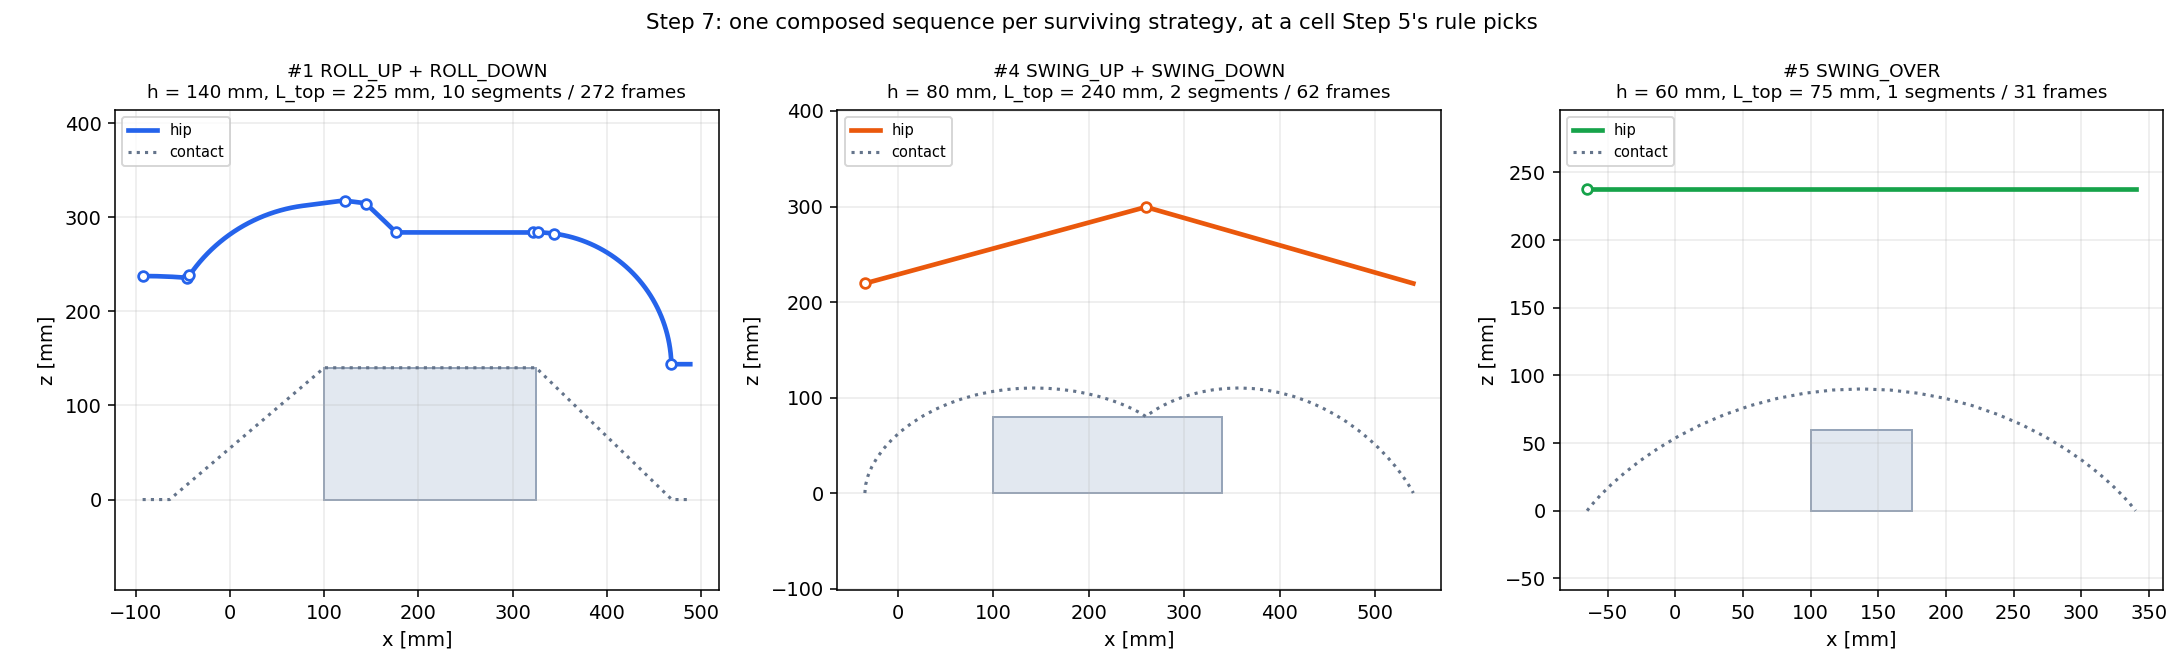

In [71]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step7_sequences.png')))

### 讀圖：三種策略的質性差異一眼看得出來

```text
#1  髖是【梯形】—— 爬升、平頂、下降；接觸點沿著障礙輪廓滾過去
#4  髖是【雙三角】—— 兩段 swing 的直線 hip 軌跡；接觸點兩道拋物線
#5  髖是【水平線】—— 零垂直起伏；接觸點一道拋物線越過整個障礙
```

圓圈是 segment 起點，也就是 Step 6 的 schema 把這條軌跡切開的地方。

## 7.7 Step 7 結論

```text
[完成標準]
(1) 成立（改述）  規格點名的三對有兩對已被推翻。三條【還活著】的各生出一條完整、
                  collision-free 的 sequence；兩個推翻以第一級輸出記錄。
(2) 成立          所有交接的不連續量都量化了：
                  關節 <= 1.75 deg（一個取樣步長內）、接觸點最大 215.9 mm（換 rim，非不連續）、
                  rim 幾何 gap 最大 1.2000 mm（= 標稱值，不累積）。
                  【明確記錄為已知風險】：#1 最短頂面那條有 88 幀貼著接縫 1.17 deg。
(3) 成立（改述）  規格要 SWING+ROLL 的頂面用量。那一對不存在，所以量的是 #4：
                  240.0 mm，落在 L_transition 的 196-249 mm 帶內。
                  順帶量到 #1 用掉 202.0 mm 但需要 225 mm —— 差 23 mm 的進出餘裕。
```

**Step 7 對前面幾步的三個修正：**

```text
1. 決策要帶 repair 旋鈕（Step 5 的完成標準本來就要求「內部參數」）
2. #1 的頂面下界：實測過的 theta 用實測值，其餘標記未驗證
   （不是一律加 10 mm —— Step 7 自己的括號量測否決了那個做法）
3. composer 必須沿用 Day 6-7 自己的 SweepSettings2D，不是自己重建設定
```

**Step 5 的地圖已經用修正後的界線重跑**：`#1` 的下界從 205–245 變成 215–245 mm，
§2.7 的判決不變（1/6），順序敏感度 200 / 184（原 208 / 186）。

> **用語（見本 notebook 開頭的前提）**：這裡的「推翻 / 不可行」是 `DIRECT_HANDOFF_INFEASIBLE`
> ——**目前的單腿連續接觸 primitive 無法直接交接**。它**不是** `PHYSICALLY_INFEASIBLE`；
> 在四腳支撐下的 `TOP_REPOSITION` 之後可能成立，只是**尚未驗證**。

---

# Step 8 — 五個 terrain case 的 regression（含負向）

## 8.1 這一步的第三條完成標準【無法達成】，而那本身就是結果

規格要求：

> 至少有一個 case 的最佳策略是**混合的**（ascent 與 descent 不同），
> 否則 2×2 沒有被驗證。

```text
#2 ROLL_UP  + SWING_DOWN   被 Step 3 D/E 推翻
#3 SWING_UP + ROLL_DOWN    被 Step 2b 推翻
```

**兩個混合對都不在了**，所以沒有任何 case 的最佳解會是混合的。
**2×2 不是「未被驗證」，是「對角線之外被推翻」。**

這一步的工作因此變成兩件：

```text
1. 把五個 case 重新切到 Step 5 的【實際 region】上，但保留每個原 case 的目的，
   而且每個 case 都把【所有】策略（贏家和輸家）都組一次 ——
   負向結論要建立在實際執行上，不是查表。
2. 量化那個推翻的【代價】。
```

In [72]:
case8 = pd.read_csv(day10_11_dir / 'day10_11_step8_cases.csv')
live = ['#1 ROLL_UP + ROLL_DOWN', '#4 SWING_UP + SWING_DOWN', '#5 SWING_OVER']
view = case8[case8.strategy.isin(live)].copy()
print('五個 case，每個都把三個活著的策略都組一次：')
display(view.pivot_table(index='case', columns='strategy', values='composed',
                         aggfunc='first').replace({True: 'COMPOSED', False: 'refused'}))
print()
print('贏家與輸家的 body 代價（mm）—— 輸家必須【可行但較貴】才算驗證了決策：')
display(view.pivot_table(index='case', columns='strategy',
                         values='body_deviation_mm', aggfunc='first').round(1))

五個 case，每個都把三個活著的策略都組一次：


strategy,#1 ROLL_UP + ROLL_DOWN,#4 SWING_UP + SWING_DOWN,#5 SWING_OVER
case,,,
"A short top, low obstacle",refused,refused,COMPOSED
B roll wins,COMPOSED,COMPOSED,refused
C swing wins,COMPOSED,COMPOSED,refused
D the hole,refused,refused,refused
E the case built for #2,refused,COMPOSED,refused



贏家與輸家的 body 代價（mm）—— 輸家必須【可行但較貴】才算驗證了決策：


strategy,#1 ROLL_UP + ROLL_DOWN,#4 SWING_UP + SWING_DOWN,#5 SWING_OVER
case,,,
"A short top, low obstacle",NaN,NaN,0.0
B roll wins,154.2,180.0,NaN
C swing wins,94.2,80.0,NaN
E the case built for #2,NaN,220.0,NaN


### 讀表：B 和 C 是決策規則真正被驗證的地方

```text
A  h= 40 L= 50    #5 勝            #1 / #4 都在 top length 上失敗
B  h=140 L=350    #1 勝 154.2 mm   #4 【可行但要 180.0 mm】—— 貴 25.8 mm
C  h= 80 L=350    #4 勝  80.0 mm   #1 【可行但要  94.2 mm】—— 貴 14.2 mm
D  h=120 L=150    都不行           三個理由不一樣（見 §8.2）
E  h=160 L=350    #4 勝 220.0 mm   #1 不可行（沒有任何 theta 走得完）
```

**B 和 C 是同一個判準在兩個方向上都被驗證**：輸家不是「不可行」，
而是**確實可行、確實比較貴**。那正是 Step 5 的 lexicographic 規則在做的事。

## 8.2 每個負向都要說得出理由

In [73]:
neg = case8[~case8.composed.astype(bool)]
print(f'{len(neg)} 個拒絕，其中沒有理由的：{int((neg.refusal.fillna("").str.strip() == "").sum())}')
print()
print('理由的第一個子句：')
display(neg.refusal.str.split(':').str[0].value_counts().to_frame('次數'))
print()
print('那個【洞】（case D）的三個拒絕：')
hole = neg[neg.case.str.startswith('D') & neg.strategy.isin(live)]
for _, x in hole.iterrows():
    print(f'  {x.strategy:24s} {x.refusal}')

19 個拒絕，其中沒有理由的：0

理由的第一個子句：


,次數
refusal,
DIRECT_HANDOFF_INFEASIBLE,10
infeasible (top length),4
infeasible (stride),4
infeasible (ascent),1



那個【洞】（case D）的三個拒絕：
  #1 ROLL_UP + ROLL_DOWN   infeasible (top length): every feasible theta needs a longer top; the least demanding needs 243.0 mm.
  #4 SWING_UP + SWING_DOWN infeasible (top length): the ascent lands 160 mm in and the shortest feasible takeoff is 80 mm, so the top must be at least 240 mm.
  #5 SWING_OVER            infeasible (stride): no theta spans this obstacle at any measured top length: IK_NOT_CONVERGED.


### 讀表：19 個拒絕，0 個沒有理由

那個洞的三個拒絕有 **3 個不同的理由**，但只有 **2 個 limiter 名稱**：

```text
#1  top length : 每個可行 theta 都需要更長的頂面，最省的要 243.0 mm
#4  top length : 落點吃掉 160 mm、最短起跳 80 mm，所以頂面至少要 240 mm
#5  stride     : 沒有任何 theta 跨得過去（IK_NOT_CONVERGED）
```

`#1` 和 `#4` **共用一個 limiter 名稱卻是不同的牆**——一個是付不起 `L_transition`，
另一個是塞不下「落點加起跳點」。所以那個洞**不是單一天花板**，
而且比較理由時要比**完整理由**而不是它的第一個子句。

## 8.3 Case E：量化推翻 `#2` 的代價

這是規格原本為 `#2` 設計的那塊地形，而它的前提**完全正確**。

In [74]:
cost8 = pd.read_csv(day10_11_dir / 'day10_11_step8_mixed_pair_cost.csv')
display(cost8.T.rename(columns={0: 'case E'}))

,case E
case,E the case built for #2
obstacle_mm,160.0
roll_up_thetas_ok,10/10
roll_down_thetas_ok,0/10
roll_up_p2p_mm,80.058195
swing_up_p2p_mm,220.0
ratio_swing_over_roll,2.748001
partial_stopped_at,the traversal failed at ROLL_DOWN: NO_LEGAL_CO...
note,the ascent is real work the leg does; the pair...


### 讀表：爬得上去、下不來，而且那個爬升便宜 2.7 倍

Day 6–7 在 `h = 160 mm` 的 sweep：

```text
roll_up   成功  10/10 個 theta
roll_down 成功   0/10 個 theta
```

**那正是 `ROLL_UP + SWING_DOWN` 被發明出來要對付的地形。**

用 `keep_partial` 保留失敗 traversal 中成功的階段，把那個「爬得上去卻用不了」的
ascent 實際計價：

```text
ROLL_UP  hip peak-to-peak    80.1 mm   （2 段 60 幀，theta = 85 deg）
SWING_UP hip peak-to-peak   220.0 mm   （= h 160 + min_hip_lift 60）
=> 滾上去對 body 的要求少 【2.7 倍】，而且它在【每一個】theta 都成立。
```

**它用不了的原因和這個 ascent 完全無關**——`#2` 被推翻是**下降側**的理由
（Step 3 D 段的 `+40 deg` 接縫、E 段的 `theta >= 35 deg` 下限）。

那條 partial traversal 停在：

```text
ROLL_DOWN: NO_LEGAL_CORNER_PIVOT_CONTINUATION
```

——和 Step 2b 在 `h >= 160 mm` 對「空中來的抵達」量到的**同一個**失敗。
所以那道牆是下降側的，與上升怎麼來的無關。

> **這就是 2×2 對角線之外被推翻的代價，而且它是一個具體的數字。**
> `h = 160 mm` 的地形上，機器人被迫用一個對 body 要求 2.7 倍的爬升方式，
> 只因為它想用的那個下降方式配不上任何一種爬升。
>
> Step 3 說 E 段那道牆**是可修的**（retract 停在 `theta >= 35 deg` 而不是 17 deg）。
> 這一格量出了修好它值多少。

## 8.4 圖

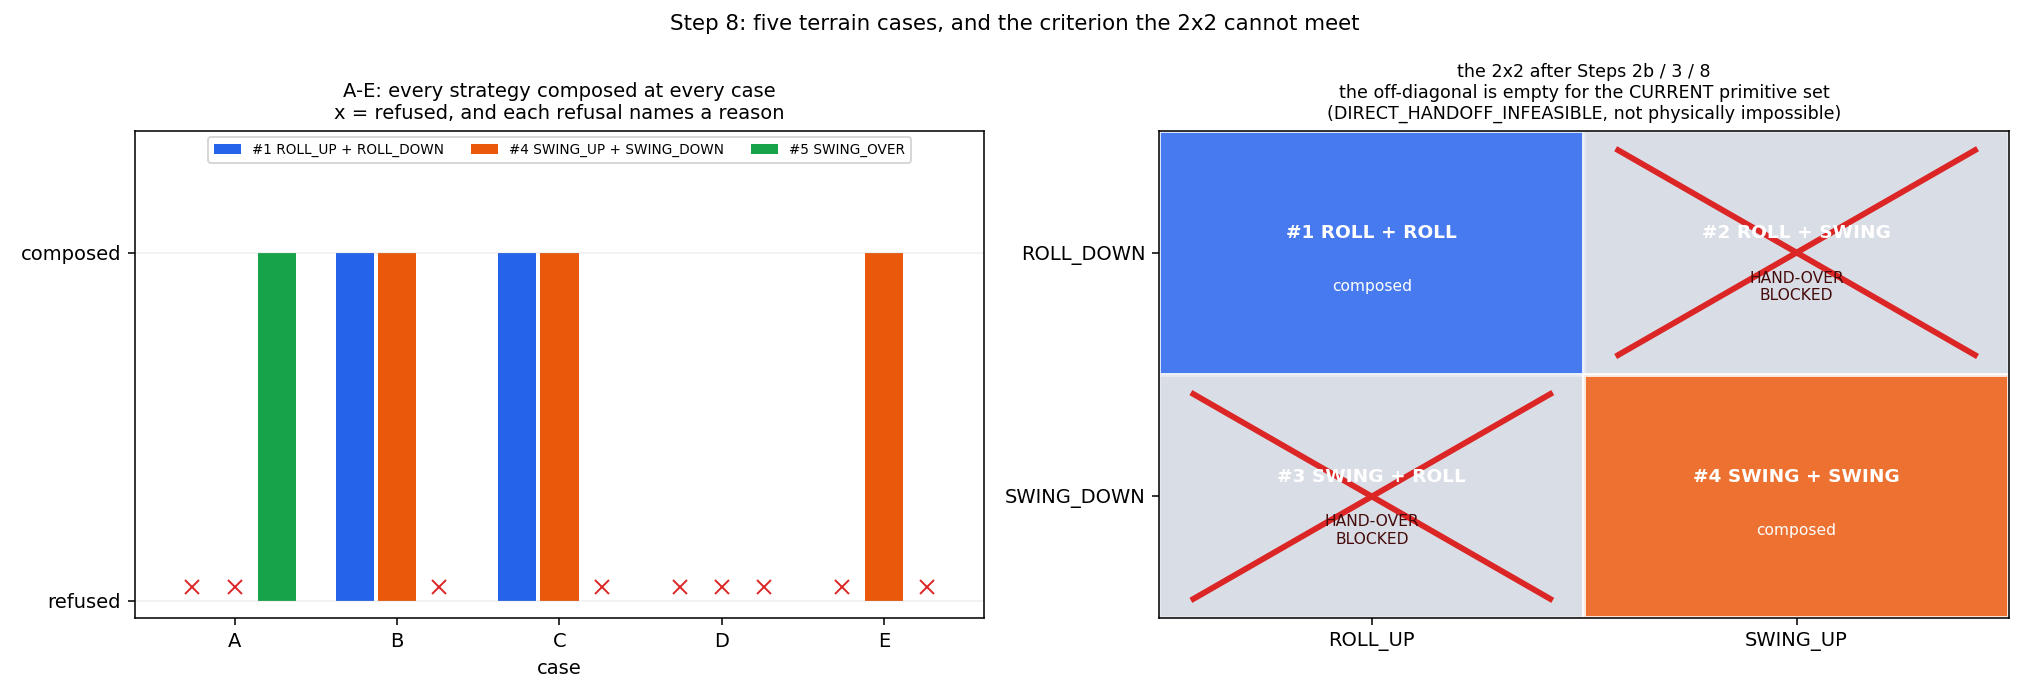

In [75]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step8_cases.png')))

### 讀圖

左圖：五個 case × 三個活著的策略，每一格都真的跑過。紅 x 是拒絕，而且每個都有理由。

右圖：**2×2 在 Steps 2b / 3 / 8 之後的樣子**——對角線活著、
**對角線之外整個空掉**。所以沒有任何 case 的最佳解會是混合的。

## 8.5 Step 8 結論

```text
[完成標準]
(1) 成立        五個 case 的正向與負向都成立；每個 case 的【所有】策略都實際組過。
(2) 成立        19 個拒絕、0 個沒有理由。
                那個洞的三個拒絕有 3 個不同理由（只有 2 個 limiter 名稱）。
(3) 【無法達成】 沒有任何 case 的最佳解是混合的 —— 因為兩個混合對都被推翻了。
                2x2 不是未被驗證，是【對角線之外被推翻】。
```

**第三條無法達成，本身就是 Day 10–11 最重要的結果之一。**

```text
§2.6 主張「上升與下降必須獨立決策」，而那個主張的實驗支撐就是
「至少有一個地形，最佳解是混合的」。

實測：兩個混合對各自撞到一道 rim 分段接縫。
    #3  落地要跨 alpha = -40 deg          （Step 2b，不可修）
    #2  起飛要跨 alpha = +40 deg          （Step 3 D 段，不可修）
        或退化成 retract，撞 theta >= 35 deg 下限（Step 3 E 段，【可修】）

=> 分解【概念上】仍然成立（你確實是分開選的），
   但選擇集合在目前的 planner 下塌陷成對角線。
```

**而 case E 量出了這件事的代價**：`h = 160 mm` 上，滾上去便宜 2.7 倍且每個 theta
都成立，卻只能改用貴 2.7 倍的擺盪爬升——因為它想配的那個下降方式不存在。

**這也把「修好 Step 3 E 段」從一個技術待辦升格成一個有價碼的目標。**

> **用語（見本 notebook 開頭的前提）**：這裡的「推翻 / 不可行」是 `DIRECT_HANDOFF_INFEASIBLE`
> ——**目前的單腿連續接觸 primitive 無法直接交接**。它**不是** `PHYSICALLY_INFEASIBLE`；
> 在四腳支撐下的 `TOP_REPOSITION` 之後可能成立，只是**尚未驗證**。

---

# Step 9 — body-requirement timeline（Day 12 的交接物）

## 9.1 這一步要交出什麼

Step 7 交出的是 **sequence**；Day 12 要的不是 sequence，是**這條 sequence 對 body 要求什麼**。

規格的四條完成標準：

```text
(1) Day 12 只讀這一個檔案就夠，不必回頭讀 Day 6-7 / 8-9 的任何內部結構
(2) 硬約束（違反則 sequence 失效）與偏好（body 可以更高，只是沒必要）要分開標示
(3) 未解的 transition requirement 有【自己的列】，而且看得出是「還沒解」不是「不存在」
(4) rolling 的時間來源寫在檔案裡
```

交付物是一個檔案：`day10_11_step9_body_requirements.csv`。

## 9.2 第一個決定：以 `x` 為自變數，不是 `t`

規格要求擇一並寫明理由。理由在 Day 6–7 的資料本身：

```text
Day 6-7 的 rolling traversal 是【準靜態】的，duration_s 全部是 None。
=> 指定 rolling 的時間是一個【新的建模決定】，不是量測結果，
   而且它會落在真數字之後該去的那個位置上。
```

所以：**`x` 是自變數；已經存在的時間照原樣帶過去**——每條 swing 帶著
Day 8–9 給它的 0.6 s（`segment_duration_s`）與逐取樣的 `knot_time_s`，
rolling 兩欄都留白。**留白的意思是「從未被指定」，不是 0。**

而「`x` 能不能當自變數」是**被檢查的**，不是假設的。

In [76]:
step9 = pd.read_csv(day10_11_dir / 'day10_11_step9_body_requirements.csv')
heads = step9[step9.row_kind == 'sequence']
display(heads[['strategy', 'verdict', 'executable', 'obstacle_mm', 'top_length_mm',
               'segments', 'knots', 'hard_knots', 'preference_knots',
               'unresolved_transitions', 'x_is_monotonic', 'max_knot_spacing_mm',
               'clearance_budget_mm', 'time_basis']]
        .set_index('strategy').round(2))
print('檔案列數：', len(step9), '欄數：', step9.shape[1])
print('row_kind 分佈：', step9.row_kind.value_counts().to_dict())

,verdict,executable,obstacle_mm,top_length_mm,segments,knots,hard_knots,preference_knots,unresolved_transitions,x_is_monotonic,max_knot_spacing_mm,clearance_budget_mm,time_basis
strategy,,,,,,,,,,,,,
#1 ROLL_UP + ROLL_DOWN,COMPOSED,True,140.0,225.0,10.0,272.0,272.0,0.0,0.0,True,40.64,1.83,x_progress
#4 SWING_UP + SWING_DOWN,COMPOSED,True,80.0,240.0,2.0,62.0,4.0,58.0,0.0,True,9.81,1.39,x_progress
#5 SWING_OVER,COMPOSED,True,60.0,75.0,1.0,31.0,2.0,29.0,0.0,True,13.50,1.30,x_progress
#2 ROLL_UP + SWING_DOWN,DIRECT_HANDOFF_INFEASIBLE,False,160.0,350.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,x_progress
#3 SWING_UP + ROLL_DOWN,DIRECT_HANDOFF_INFEASIBLE,False,140.0,225.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,x_progress


檔案列數： 392 欄數： 63
row_kind 分佈： {'knot': 365, 'segment': 13, 'provenance': 7, 'sequence': 5, 'unresolved_transition': 2}


### 讀表：三條 sequence 的 `x` 都是單調的，所以這個選擇成立

```text
#1 ROLL_UP + ROLL_DOWN    272 knots，全部硬約束，knot 間距最大 40.6 mm
#4 SWING_UP + SWING_DOWN   62 knots，4 硬 / 58 偏好，間距最大  9.8 mm
#5 SWING_OVER              31 knots，2 硬 / 29 偏好，間距最大 13.5 mm
#2 / #3                     0 knots —— 什麼都沒有被生成
```

兩個順帶交出去的數字：

```text
max_knot_spacing_mm   timeline 是一條折線，Day 12 在 knot 之間內插。
                      這是它最粗的一段。
clearance_budget_mm   整條 sequence 上量到的最小地形餘裕（1.3-1.8 mm）。
                      body 偏離要求時吃掉的就是這個。
                      Day 10-11 沒有量過 TRACK 的容差，這是唯一有的替代品。
```

`#2` / `#3` 的 `x_is_monotonic` 是**留白**而不是 `True`：空集合上的單調性是真的，
但它什麼也沒說，寫 `True` 會被讀成「檢查過了，沒問題」。

## 9.3 硬約束 vs 偏好 —— 以及資料逼出來的第一件事

規格給的對照是：

```text
硬約束   TRACK        rolling 段 —— 違反則接觸幾何不成立
         PINNED       Step 2b 那種落地 —— hip 沒有自由度
偏好     LOWER_BOUND  swing 段 —— body 可以更高，只是沒必要
```

但照這張表直接套，`PINNED` 在三條活著的 sequence 裡**一次都不會出現**——
Step 2b 那種落地屬於 `#3`，而 `#3` 被推翻了。

**那個結論是錯的，而且錯的方式很危險。** 一條 swing 的**兩個端點**都是接觸瞬間：
腳踩在面上時，hip 高度與 `theta` **互相決定**。把整條 swing 標成偏好，
等於允許 Day 12 在觸地那一刻抬高 body ——`plan.valid` 仍然成立，
但落下來的是**另一個** contact state。

In [77]:
seg9 = step9[step9.row_kind == 'segment']
knot9 = step9[step9.row_kind == 'knot']

print('每一種 body_kind 各有多少 knot，以及它算硬還是偏好：')
display(pd.crosstab(knot9.body_kind, knot9.constraint_class,
                    rownames=['body_kind'], colnames=['constraint_class']))
print()
print('swing 段的三種 knot（依 requirement_basis）：')
display(knot9[knot9.segment_kind.str.startswith('SWING')]
        .groupby(['segment_kind', 'requirement_basis', 'contact_phase'])
        .size().to_frame('knots'))

每一種 body_kind 各有多少 knot，以及它算硬還是偏好：


constraint_class,HARD,PREFERENCE
body_kind,,
lower_bound,0,87
pinned,6,0
track,272,0



swing 段的三種 knot（依 requirement_basis）：


knots
segment_kind requirement_basis   contact_phase       
SWING_DOWN   PINNED_CONTACT      STANCE             2
             WITNESS_LOWER_BOUND FLIGHT            29
SWING_OVER   PINNED_CONTACT      STANCE             2
             WITNESS_LOWER_BOUND FLIGHT            29
SWING_UP     PINNED_CONTACT      STANCE             2
             WITNESS_LOWER_BOUND FLIGHT            29

### 讀表：`PINNED` 出現了，而且它出現在每一條 swing 的頭尾

```text
TRACK        272 knots   HARD         rolling 的每一幀
PINNED         6 knots   HARD         三條 swing x 2 個端點
LOWER_BOUND   87 knots   PREFERENCE   swing 的中段
```

`contact_phase` 同時把 Day 12 的 duty 交出去了：`STANCE` 是這條腿在承重的 knot
（rolling 全段 + swing 的兩個端點），`FLIGHT` 是它離地的 knot。

下面是把「端點是硬的」變成數字的量測。

In [78]:
ev9 = pd.read_csv(day10_11_dir / 'day10_11_step9_pinned_endpoint_evidence.csv')
theta_vs_hip = ev9[ev9.section == 'theta_vs_hip_z'][['theta_deg', 'hip_z_mm']]
display(theta_vs_hip.set_index('theta_deg').T.round(1))

sens = ev9[ev9.section == 'endpoint_sensitivity'].iloc[0]
print(f"""落地/起跳 theta = {sens.theta_deg:.0f} deg 時 hip_z = {sens.hip_z_mm:.1f} mm
    body 低 10 mm -> theta = {sens.hip_minus_10mm_theta_deg:.1f} deg
    body 高 10 mm -> theta = {sens.hip_plus_10mm_theta_deg:.1f} deg""")

theta_deg,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0,85.0,90.0
hip_z_mm,166.1,174.8,183.6,192.5,201.5,210.5,219.4,228.4,237.5,246.5,255.7,264.9,274.2


落地/起跳 theta = 60 deg 時 hip_z = 219.4 mm
    body 低 10 mm -> theta = 54.4 deg
    body 高 10 mm -> theta = 65.6 deg


### 讀表：±10 mm 的 body 偏移 ＝ ±5.6 度的 `theta` ＝ **另一個 sweep 格**

站在一個面上時 `hip_z` 是 `theta` 的嚴格單調函數，所以兩者**互相決定**。

這正是紀錄檔陷阱 16 的另一面：

```text
落地 theta 是 IK 的【輸出】不是輸入。
plan.valid 只說「swing 成功了」，不說「落在要求的 contact state」。
抬高 hip 會讓 IK 解出不同的 theta，而 plan 仍然 valid。
```

所以 timeline 對 swing 的端點寫 `PINNED`，只有中段寫 `LOWER_BOUND`。
**這是規格 §5.3 的 `PINNED` 從「Step 2b 的特例」推廣成一般規則。**

## 9.4 資料逼出來的第二件事：**envelope 不是 timeline**

Step 6 的 builder 對一整條 swing 只留**一個** `hip_z_min`——它是那條 hip 軌跡的**最大值**。

那是一個**正確的 envelope**（Step 5 就是拿它做決策的），但它是一個**錯的 timeline**。

In [79]:
env = seg9[seg9.segment_envelope_hip_z_mm.notna()][
    ['strategy', 'segment_kind', 'constraint_class',
     'segment_envelope_hip_z_mm', 'hip_z_low_mm', 'max_envelope_excess_mm']]
display(env.round(1).reset_index(drop=True))
print()
print('rolling 段（TRACK）有幾個帶純量 envelope 的：',
      int(seg9[seg9.body_kind == 'track'].segment_envelope_hip_z_mm.notna().sum()))

,strategy,segment_kind,constraint_class,segment_envelope_hip_z_mm,hip_z_low_mm,max_envelope_excess_mm
0,#4 SWING_UP + SWING_DOWN,SWING_UP,PREFERENCE,299.4,219.4,80.0
1,#4 SWING_UP + SWING_DOWN,SWING_DOWN,PREFERENCE,299.4,219.4,80.0
2,#5 SWING_OVER,SWING_OVER,PREFERENCE,237.5,237.5,0.0



rolling 段（TRACK）有幾個帶純量 envelope 的： 0


### 讀表：在起跳端，那個純量把 body 多抬了 **80 mm**

```text
#4 SWING_UP    envelope 299.4 mm，而起跳端的真實要求是 219.4 mm  -> 多 80.0 mm
#4 SWING_DOWN  envelope 299.4 mm，而觸地端的真實要求是 219.4 mm  -> 多 80.0 mm
#5 SWING_OVER  envelope 237.5 mm = 全段要求                      -> 多  0.0 mm
```

`#4` 的那 80 mm 剛好是障礙高度：拿 envelope 當 timeline，等於在 swing 還沒起跳
就叫 body 先站到障礙頂面的高度。所以檔案裡**兩個都寫**：
`segment_envelope_hip_z_mm` 在 segment 列（比較策略時用它），
`hip_z_required_mm` 在 knot 列（沿路走的時候用它）。

**而 rolling 段【沒有】這個純量，欄位是留白的。** 這是實作時自己先犯、再修掉的一個錯：

```text
第一版對 TRACK 也算了一個 envelope = max(profile)，於是 #1 被報成
「被多約束了 136.9 mm」。但 TRACK 的要求【就是】那條 profile ——
它從來沒有一個純量可以被誤讀。那個數字是憑空製造出來的。
```

> **和 Step 9 前置修正踩到的是同一類錯**：一個為某個情況設計的量，
> 套到不適用的情況上，就會生出一個沒有人主張過的結論。

## 9.5 未解的 transition：自己的列，而且**不填姿態**

In [80]:
un9 = step9[step9.row_kind == 'unresolved_transition']
display(un9[['strategy', 'verdict', 'transition_kind', 'target_condition',
             'requires_external_support', 'resolved',
             'theta_deg', 'beta_deg', 'segment_duration_s']]
        .set_index('strategy').T)
print()
for _, r in un9.iterrows():
    print(f"{r.strategy}")
    fix = r.single_leg_fix if isinstance(r.single_leg_fix, str) and r.single_leg_fix.strip() else '（沒有——只有四腳路徑）'
    print(f"  單腿修法：{fix}")
    print(f"  四腳路徑（尚未驗證）：{r.multileg_route}")
    print()

strategy,#2 ROLL_UP + SWING_DOWN,#3 SWING_UP + ROLL_DOWN
verdict,DIRECT_HANDOFF_INFEASIBLE,DIRECT_HANDOFF_INFEASIBLE
transition_kind,TOP_REPOSITION,TOP_REPOSITION
target_condition,a foot-rim take-off on the top above theta = 3...,"LEFT_RIM_READY -- left rim carrying, theta = 1..."
requires_external_support,True,True
resolved,False,False
theta_deg,NOT_GENERATED,NOT_GENERATED
beta_deg,NOT_GENERATED,NOT_GENERATED
segment_duration_s,NOT_GENERATED,NOT_GENERATED



#2 ROLL_UP + SWING_DOWN
  單腿修法：RETRACT_FOR_SWING_DOWN -- a retract that stops at theta >= 35 deg with the contact back on the foot rim.  Step 8 priced it: at h = 160 mm rolling up asks the body for 80.1 mm against the swing ascent's 220.0 mm, a factor of 2.7.
  四腳路徑（尚未驗證）：TOP_REPOSITION under multi-leg support: release the right-rim contact and re-extend in the air (spec 5.6).

#3 SWING_UP + ROLL_DOWN
  單腿修法：（沒有——只有四腳路徑）
  四腳路徑（尚未驗證）：SWING_UP -> a safe foot-rim landing on the top -> TOP_REPOSITION under multi-leg support -> LEFT_RIM_READY -> ROLL_DOWN (spec 5.6).



### 讀表：三個欄位寫 `NOT_GENERATED`，而不是留白

```text
theta_deg / beta_deg / segment_duration_s = NOT_GENERATED
```

**留白會被讀成 0。** 而這三個值不是 0，是**還沒有人算過**——算它們需要判斷
「離地期間誰在撐 body」，那是四腳 timing 的工作（規格 §5.6）。

兩個 blocked pair 的差別也一起交出去了，這是 Step 9 前置修正把字串換成紀錄的收穫：

```text
#2 ROLL_UP + SWING_DOWN   有單腿修法（RETRACT_FOR_SWING_DOWN），Step 8 已標價 2.7 倍
#3 SWING_UP + ROLL_DOWN   沒有單腿修法，只有四腳路徑
```

`resolved` 永遠是 `False`；把它設成 `True` 會**拋錯**——解掉一個 transition 的方式是
**換成真正的動作**，不是把旗標翻過來。

## 9.6 這個檔案站得住嗎？

第一條完成標準是「Day 12 只讀這一個檔案就夠」。誠實的檢查方式不是在文件裡宣稱它，
而是**用一個不 import 這個專案任何東西的 reader 把它讀回來**——
`reader_check_2d()` 只用標準函式庫的 `csv`。

In [81]:
crit = pd.read_csv(day10_11_dir / 'day10_11_step9_completion_criteria.csv')
display(crit[crit.criterion.notna()][['criterion', 'outcome', 'evidence']]
        .set_index('criterion'))
print()
chk = crit[crit.check == 'reader_check'].iloc[0]
print(f"""reader_check（只用 csv 模組）：{'PASS' if chk.passed else 'FAIL'}
    {int(chk.sequences)} 條 sequence（{int(chk.executable_sequences)} 條可執行）
    {int(chk.knots)} 個 knot（{int(chk.hard_knots)} 硬 / {int(chk.preference_knots)} 偏好）
    {int(chk.unresolved_rows)} 列未解 transition、{int(chk.gap_rows)} 列未規劃缺口
    問題：{chk.problems if isinstance(chk.problems, str) else '（無）'}""")

,outcome,evidence
criterion,,
Day 12 can read this one file,holds,reader_check_2d re-read the file with the csv ...
hard constraints and preferences are marked,holds,"278 knots are HARD (TRACK on rolling, PINNED a..."
unresolved transitions have their own rows,holds,2 unresolved_transition rows across 2 blocked ...
the rolling time source is stated in the file,holds,"time_basis = x_progress on every sequence row,..."



reader_check（只用 csv 模組）：PASS
    5 條 sequence（3 條可執行）
    365 個 knot（278 硬 / 87 偏好）
    2 列未解 transition、0 列未規劃缺口
    問題：（無）


### 讀表：四條完成標準全部成立

reader 檢查的不只是「讀得開」，還包括：

```text
每個 segment 宣告的 frame_count 與它實際的 knot 列數相符
每條 sequence 的 x 單調
每個 knot 的 constraint_class 落在 HARD / PREFERENCE 之內
每個 knot 的 hip_z_upper_bound_mm 是 NOT_MEASURED（不是留白 —— 留白讀起來像「無上界」）
每一列未解 transition 的 resolved = False 且姿態欄是 NOT_GENERATED
沒有任何一列宣稱 PHYSICALLY_INFEASIBLE
```

檔案自己也帶著 7 列 `provenance`，把時間基準、硬/偏好的定義、envelope 與 timeline 的差別、
`NOT_MEASURED` 的意思、用語階梯與 scope 全部寫在裡面。**這些不能只留在 notebook 裡**——
完成標準要求的是 Day 12 打開那個檔案就看得到。

## 9.7 圖

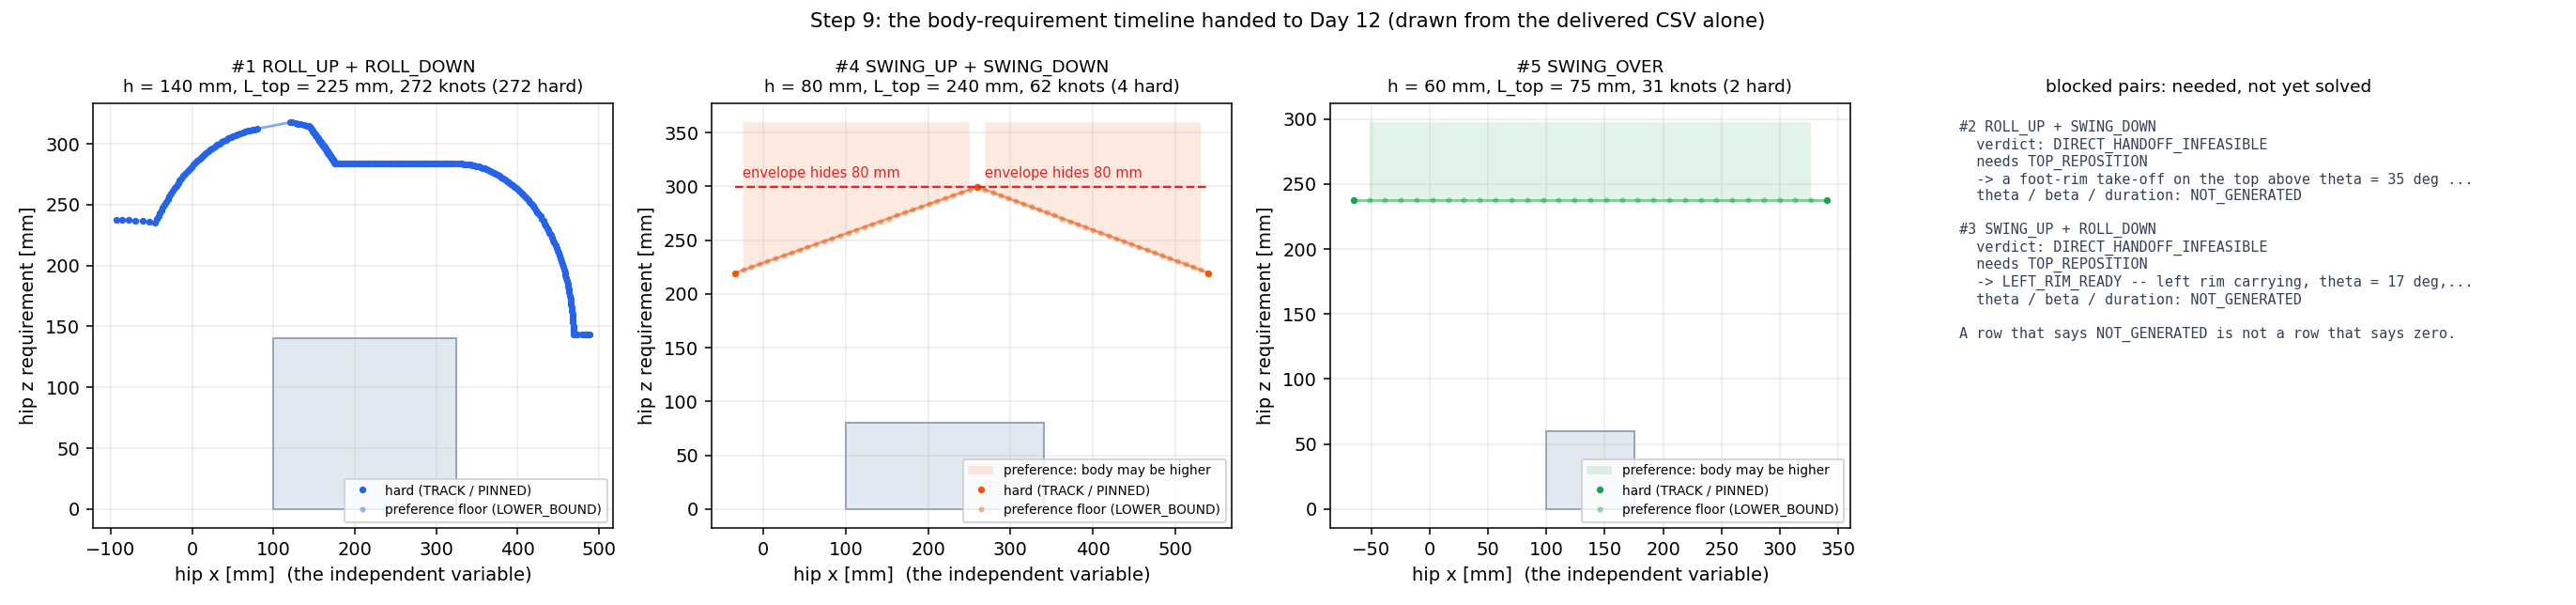

In [82]:
_display(Image(filename=str(day10_11_dir / 'day10_11_step9_body_requirements.png')))

### 讀圖：三種策略對 body 的要求，形狀完全不同

```text
#1 ROLL_ROLL   一條【要跟隨】的軌跡（梯形：上升、平頂、下降），272 個點全是硬的
#4 SWING_SWING 一個【地板】（三角形），只有 4 個端點是硬的
#5 SWING_OVER  一條【水平線】—— 237.5 mm 從頭到尾，body 完全不用動
```

紅色虛線是 Step 6/7 的純量 envelope，`#4` 的兩段各藏了 80 mm。

最右邊那一欄不是空白，是**兩個被記下來的洞**。一個只畫三條線的圖會讓人以為
策略空間就是那三個；把 `#2` / `#3` 連同 `NOT_GENERATED` 一起畫進去，
才看得出「還沒解」和「不存在」的差別。

這張圖是**從交付的 CSV 畫出來的**，不是從記憶體裡的物件——所以它同時是第一條完成標準的示範。

## 9.8 Step 9 結論

```text
[完成標準]
(1) 成立   reader_check_2d 只用 csv 模組就把 5 條 sequence / 365 個 knot 讀回來並逐項稽核。
(2) 成立   278 個硬 knot（TRACK + PINNED）、87 個偏好 knot（LOWER_BOUND），
           違反各自的後果寫在 segment 列與 provenance 列上。
(3) 成立   2 列 unresolved_transition，帶 resolved=False、目標條件、證據與四腳路徑，
           姿態與時間欄寫 NOT_GENERATED。
(4) 成立   time_basis = x_progress 寫在每一條 sequence 列上，理由寫在 provenance 列上。
```

**資料逼出兩件規格沒有預期的事：**

```text
1. PINNED 不是 Step 2b 的特例，是【每一條 swing 的兩個端點】。
   證據：站姿下 hip_z 與 theta 互相決定，±10 mm -> ±5.6 deg。
   後果：把整條 swing 標成偏好，Day 12 會在觸地那一刻換掉落地姿態而不自知。

2. Step 6/7 的 segment 純量是 envelope 不是 timeline，在 #4 的兩段各藏 80 mm。
   而 rolling 段【根本沒有】那個純量 —— TRACK 的要求就是 profile 本身。
```

**Day 10–11 到此結束。** Step 0–9 全部完成，交付物是
`day10_11_step9_body_requirements.csv`，Day 12 的四腳 timing 可以只讀它。

> **用語（見本 notebook 開頭的前提）**：檔案裡沒有任何一列是 `PHYSICALLY_INFEASIBLE`。
> `#2` / `#3` 是 `DIRECT_HANDOFF_INFEASIBLE`——**目前的單腿連續接觸 primitive 無法直接交接**，
> 在四腳支撐下的 `TOP_REPOSITION` 之後可能成立，只是**尚未驗證**。

---

# Day 10–11 結束

```text
Step 0   scene / approach 幣別對齊                        [完成]
Step 1   concession 契約                                   [完成]
Step 2   上升側 swing sweep + close-out                    [完成]
Step 2b  SWING_UP -> LEFT_RIM_READY                        [完成，negative]
Step 3   下降側 swing sweep                                [完成，negative]
Step 4   rolling map 換幣別（質心 story 的關鍵實驗）        [完成]
Step 5   疊圖與 decision rule（Figure D）                   [完成]
Step 6   segment 級 motion sequence schema                 [完成]
Step 7   sequence composer 與交接連續性                    [完成]
Step 8   五個 terrain case 的 regression                   [完成]
Step 9   body-requirement timeline（Day 12 交接物）        [完成]
```

**交給 Day 12 的東西**

```text
已解    #1 / #4 / #5 的 body-requirement timeline
        day10_11_step9_body_requirements.csv —— 一個檔案，365 個 knot，
        硬約束 278 / 偏好 87，以 x 為自變數

未解    #2 / #3 的 TOP_REPOSITION（2 列，resolved=False，姿態欄 NOT_GENERATED）
        只有到了四腳 timing 才驗證得了 —— 它需要「其他腿能否承重」這個判斷

未解    rolling 段沒有 duration（Day 6-7 是準靜態資料）
        Step 9 選了以 x 為自變數，所以 Day 12 要自己補時間軸
```

**Day 10–11 之後的六個方向**（規格 §7 Step 10 有完整版，**已經不是 Day 10–11 的範圍**）

```text
優先 1  Swing endpoint theta 自動選擇        —— 直接壓低 #4 目前保守的 body 代價
優先 2  最佳化 landing / takeoff distance    —— 可能縮小「高障礙 + 短頂面」的洞
優先 3  新增 RETRACT_FOR_SWING_DOWN          —— 最可能快速拿回 #2；價碼已知（2.7 倍）
優先 4  分段 hip trajectory（中段拱高）       —— 解 SWING_OVER 的 91 mm 天花板與 Step 2b
優先 5  四腳 TOP_REPOSITION                  —— 此時才能【真正重測】 #2 / #3
優先 6  多障礙長路 coverage test              —— 做完之前不要宣稱「多數 obstacle 可通過」
```